# DORAnet → enzyme hypotheses → DNA design (one example compound)

This notebook converts DORAnet-generated reaction networks into concise downstream design tables: parsed reactions, enzyme hypotheses, enzyme-candidate templates, and non-operational DNA design plans for expert review.

In [45]:
from pathlib import Path
import glob
import json
import os
import re
import textwrap
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from rdkit import Chem, rdBase
from rdkit.Chem import rdmolfiles, Draw, AllChem
from IPython.display import display, Markdown
import time
import requests
from io import StringIO
import ast
import sys
import yaml
from tqdm.auto import tqdm
tqdm.pandas()

from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

from Bio.Data import CodonTable

from dnachisel import (
    DnaOptimizationProblem,
    EnforceTranslation,
    EnforceGCContent,
    AvoidPattern,
    MaximizeCAI,
)

import hashlib

In [46]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
DORANETmoleculesDataDir = os.path.join(resultsDir, 'DORAnet/InoAdeGuoXan/PATHWAY_reconstruction/')
DORANETmoleculesDataDir_run2 = os.path.join(resultsDir, 'DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run2/')
DNADesignResultsDir = os.path.join(resultsDir, 'DNA_design/')
os.makedirs(DNADesignResultsDir, exist_ok=True)

print("Reading DORAnet results from:", DORANETmoleculesDataDir)
print("DNA design results will be saved at:", DNADesignResultsDir)

Reading DORAnet results from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction/
DNA design results will be saved at: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/


## 1. Read list of target DORAnet compounds

In [47]:
targetCompound_DF = pd.read_csv(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv")
targetCompound_DF

,Rank,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,6.156,0.476241,0.697981
1,2,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,5.989,0.473052,1.025573
2,3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.907,0.473610,1.238912
3,4,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.825,0.472941,1.495337
4,5,CC(=O)OP(=O)(O)OC(C)=O,5.758,0.479591,1.747229
5,6,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.729,0.473567,1.865382
6,7,CC(=O)OP(=O)(O)OP(=O)(O)O,5.693,0.478908,2.026785
7,8,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.692,0.473252,2.030622
8,9,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.683,0.471067,2.074770
9,10,O=C(O)CC(=O)OP(=O)(O)O,5.679,0.476017,2.094051


In [48]:
DORANETmoleculesDataDir = Path(DORANETmoleculesDataDir)

def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

def canonicalizeSmilesCollection(x):
    if not isinstance(x, (set, list, tuple)):
        return []
    out = []
    for s in x:
        c = canonicalizeSmiles(s)
        if c is not None:
            out.append(c)
    return sorted(set(out))

def parseLiteralFromScript(text, varName):
    # captures lines like: varName = {...} / [...] / "..."
    m = re.search(rf"^\s*{re.escape(varName)}\s*=\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        return None
    raw = m.group(1).strip()
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None

def parseHelpersFromScript(text):
    # Supports YAML-like line: helpers: ["O", ...]
    m = re.search(r"^\s*helpers\s*:\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        # fallback in case file uses python assignment: helpers = [...]
        return parseLiteralFromScript(text, "helpers")
    raw = m.group(1).strip()
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None

allReproFiles = sorted(
    DORANETmoleculesDataDir.rglob("reproDoranetJob.py"),
    key=lambda p: str(p).lower()
)

records = []
for reproPath in allReproFiles:
    txt = reproPath.read_text(encoding="utf-8", errors="ignore")

    startersRaw = parseLiteralFromScript(txt, "starters")
    targetRaw = parseLiteralFromScript(txt, "target")
    maxAtomsRaw = parseLiteralFromScript(txt, "maxAtoms")
    generationsRaw = parseLiteralFromScript(txt, "generations")
    helpersRaw = parseHelpersFromScript(txt)

    records.append({
        "dirName": reproPath.parent.name,
        "starters": canonicalizeSmilesCollection(startersRaw),
        "target": canonicalizeSmilesCollection(targetRaw),
        "helpers": canonicalizeSmilesCollection(helpersRaw),   # NEW
        "maxAtoms": maxAtomsRaw if isinstance(maxAtomsRaw, dict) else None,
        "generations": int(generationsRaw) if generationsRaw is not None else None,
    })

targetCompoundDir_DF = pd.DataFrame(
    records,
    columns=["dirName", "starters", "target", "helpers", "maxAtoms", "generations"]  # NEW
)

print(f"Total DORAnet configuration files: {len(targetCompoundDir_DF)}")

# join key from first target smiles
targetCompoundDir_DF = targetCompoundDir_DF.copy()
targetCompoundDir_DF["targetSmiles"] = targetCompoundDir_DF["target"].apply(
    lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) > 0 else None
)

colsToAdd = ["Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
targetCompoundDir_DF = targetCompoundDir_DF.merge(
    targetCompound_DF[colsToAdd].drop_duplicates(subset=["Canonical_SMILES"]),
    left_on="targetSmiles",
    right_on="Canonical_SMILES",
    how="left"
).drop(columns=["Canonical_SMILES"])

targetCompoundDir_DF = targetCompoundDir_DF.drop(columns=["targetSmiles"])
targetCompoundDir_DF = targetCompoundDir_DF.rename(columns={
    "starters": "starters_Canonical_SMILES",
    "target": "target_Canonical_SMILES",
    "helpers": "helpers_Canonical_SMILES",   
})

for c in ["starters_Canonical_SMILES", "target_Canonical_SMILES"]:
    targetCompoundDir_DF[c] = targetCompoundDir_DF[c].apply(
        lambda x: ".".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
    )

# Keep helpers as separate entries joined by comma (not dot)
targetCompoundDir_DF["helpers_Canonical_SMILES"] = targetCompoundDir_DF["helpers_Canonical_SMILES"].apply(
    lambda x: ", ".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
)

targetCompoundDir_DF = targetCompoundDir_DF.sort_values(
    by="pPotency_prediction", ascending=False
).reset_index(drop=True)

# safer path handling
outputPath = Path(DNADesignResultsDir) / "targetCompoundDir_DF.csv"
targetCompoundDir_DF.to_csv(outputPath, index=False)
targetCompoundDir_DF

Total DORAnet configuration files: 20


,dirName,starters_Canonical_SMILES,target_Canonical_SMILES,helpers_Canonical_SMILES,maxAtoms,generations,pPotency_prediction,pPotency_std,IC50 (µM)
0,high_pPotency_molecule_pathway1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,6.156,0.476241,0.697981
1,high_pPotency_molecule_pathway2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.989,0.473052,1.025573
2,high_pPotency_molecule_pathway3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.907,0.473610,1.238912
3,high_pPotency_molecule_pathway4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.825,0.472941,1.495337
4,high_pPotency_molecule_pathway5,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)OP(=O)(O)OC(C)=O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.758,0.479591,1.747229
5,high_pPotency_molecule_pathway6,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.729,0.473567,1.865382
6,high_pPotency_molecule_pathway7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)OP(=O)(O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.693,0.478908,2.026785
7,high_pPotency_molecule_pathway8,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.692,0.473252,2.030622
8,high_pPotency_molecule_pathway9,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.683,0.471067,2.074770
9,high_pPotency_molecule_pathway10,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C(O)CC(=O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.679,0.476017,2.094051


## 2. Read the `reconstructed` pathways metadata for all `DORAnet` reactions

- go to the directory where pathway reconstruction DORAnet results are saved
- run this: `python pathwayReconstruction.py config.yaml`
- this will generate the csv file (`doranet_chain_reconstructed_pathway_steps_by_depth.csv`) with reconstructed pathways
- read the csv file for downstream processing

### Reconstruct pathway directly from multi generation DORAnet outputs

In [49]:
doranetMultiGenConfigPath = Path(DORANETmoleculesDataDir_run2) / "config_doranet_multiGen.yaml"

with open(doranetMultiGenConfigPath, "r", encoding="utf-8") as f:
    doranetCfg = yaml.safe_load(f) or {}

outputDir = Path(doranetCfg.get("outputDir", ".")).expanduser()

# If outputDir is relative, first try relative to config location.
if not outputDir.is_absolute():
    outputDirFromConfigDir = (doranetMultiGenConfigPath.parent / outputDir).resolve()
    outputDirFromCwd = (Path.cwd() / outputDir).resolve()

    summaryCsvName = doranetCfg.get("summaryCsv", "job_summary.csv")
    if (outputDirFromConfigDir / summaryCsvName).exists():
        outputDir = outputDirFromConfigDir
    else:
        outputDir = outputDirFromCwd

summaryPath = outputDir / doranetCfg.get("summaryCsv", "job_summary.csv")

if not summaryPath.exists():
    raise FileNotFoundError(f"Could not find job summary CSV: {summaryPath}")

jobSummaryDF = pd.read_csv(summaryPath)

print(f"Config file : {doranetMultiGenConfigPath}")
print(f"Output dir  : {outputDir}")
print(f"Summary CSV : {summaryPath}")
print(f"Jobs in summary: {len(jobSummaryDF):,}")

Config file : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run2/config_doranet_multiGen.yaml
Output dir  : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run2
Summary CSV : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run2/job_summary.csv
Jobs in summary: 60


In [50]:
def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString):
        return []
    return [mol for mol in str(moleculeString).split(".") if mol]


def sortedMoleculeString(moleculeString):
    mols = splitMoleculeString(moleculeString)
    return ".".join(sorted(mols))


def normalizeReactionSmiles(reactionSmiles):
    """
    Normalize a reaction SMILES by sorting reactant and product molecule strings.

    Input:
        A.B>>C.D

    Output:
        A.B>>C.D with molecules sorted on both sides.
    """
    if pd.isna(reactionSmiles) or ">>" not in str(reactionSmiles):
        return None

    reactants, products = str(reactionSmiles).split(">>", 1)

    reactantsNorm = sortedMoleculeString(reactants)
    productsNorm = sortedMoleculeString(products)

    return f"{reactantsNorm}>>{productsNorm}"


def extractFolderNum(name):
    match = re.search(r"pathway(\d+)", str(name))
    return int(match.group(1)) if match else -1


def splitPathwayBlocks(pathwaysTxtPath):
    if not Path(pathwaysTxtPath).exists():
        return []

    lines = Path(pathwaysTxtPath).read_text(encoding="utf-8").splitlines()

    blocks = []
    current = []

    for line in lines:
        if line.startswith("pathway number ") and current:
            blocks.append(current)
            current = [line]
        else:
            current.append(line)

    if current:
        blocks.append(current)

    blocks = [
        [x for x in block if str(x).strip()]
        for block in blocks
        if any(str(x).strip() for x in block)
    ]

    return blocks


def parsePathwayBlock(block):
    """
    Parse one block from DORAnet *_pathways.txt.

    Expected structure:
        pathway number 1
        place holder ...
        place holder ...
        place holder ...
        reaction SMILES stoichiometry [...]
        reaction SMILES, name, and enthalpy:
        rxn1
        rxn2
        ...
        name1
        name2
        ...
        dH1
        dH2
        ...
    """

    pathwayNumber = None
    for line in block:
        if line.startswith("pathway number "):
            pathwayNumber = str(line).replace("pathway number ", "").strip()
            break

    stoichList = []
    for line in block:
        prefix = "reaction SMILES stoichiometry "
        if line.startswith(prefix):
            payload = line[len(prefix):].strip()
            try:
                stoichList = ast.literal_eval(payload)
            except Exception:
                stoichList = []
            break

    marker = "reaction SMILES, name, and enthalpy:"
    try:
        markerIdx = block.index(marker)
    except ValueError:
        raise ValueError("Could not find reaction SMILES/name/enthalpy marker")

    payloadLines = [x.strip() for x in block[markerIdx + 1:] if str(x).strip()]

    if stoichList:
        numSteps = len(stoichList)
    else:
        if len(payloadLines) % 3 != 0:
            raise ValueError("Cannot infer number of steps from pathway block")
        numSteps = len(payloadLines) // 3
        stoichList = [None] * numSteps

    reactionSmilesList = payloadLines[:numSteps]
    reactionNameList = payloadLines[numSteps:2 * numSteps]
    enthalpyList = payloadLines[2 * numSteps:3 * numSteps]

    if len(reactionSmilesList) != numSteps:
        raise ValueError("Malformed pathway block: reaction count mismatch")

    return {
        "pathwayNumber": pathwayNumber,
        "numSteps": numSteps,
        "reactionSmilesList": reactionSmilesList,
        "reactionNameList": reactionNameList,
        "enthalpyList": enthalpyList,
        "stoichList": stoichList,
    }


def choosePathwayTxt(row):
    """
    Prefer exact-N pathway file generated by filterExactNumRxns.
    Fallback to default *_pathways.txt.
    """

    jobDir = Path(row["jobDir"])
    jobName = str(row["jobName"])
    generationRun = int(row["generationRun"])

    candidatePaths = []

    if "exactPathwaysTxt" in row and pd.notna(row["exactPathwaysTxt"]):
        p = Path(str(row["exactPathwaysTxt"]))
        if not p.is_absolute():
            p = jobDir / p
        candidatePaths.append(p)

    candidatePaths.extend([
        jobDir / f"{jobName}_pathways_exact{generationRun}.txt",
        jobDir / f"{jobName}_pathways.txt",
    ])

    for p in candidatePaths:
        if p.exists():
            return p

    return candidatePaths[0]


def parseReactionSmiles(reactionSmiles):
    if ">>" not in str(reactionSmiles):
        raise ValueError(f"Invalid reaction SMILES: {reactionSmiles}")

    reactants, products = str(reactionSmiles).split(">>", 1)
    return reactants, products


def parseStoich(stoichText):
    if stoichText is None or pd.isna(stoichText):
        return None, None

    parts = str(stoichText).split("$")
    reactantStoich = parts[0] if len(parts) > 0 else None
    productStoich = parts[1] if len(parts) > 1 else None

    return reactantStoich, productStoich


# -------------------------------------------------------------------
# Network JSON lookup functions to recover reactionType
# -------------------------------------------------------------------

def parseNetworkReactionForLookup(rxnString):
    """
    Parse one reaction from *_network_pretreated.json.

    Expected DORAnet format:
        reactants > ruleName > thermo$reactantStoich$productStoich$reactionType > products
    """

    parts = str(rxnString).split(">")

    if len(parts) != 4:
        return None

    reactants, ruleName, metaBlock, products = parts

    metaParts = (metaBlock.split("$") + [None, None, None, None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts

    reactionSmiles = f"{reactants}>>{products}"
    normalizedReactionSmiles = normalizeReactionSmiles(reactionSmiles)

    return {
        "reactionSMILES": reactionSmiles,
        "normalizedReactionSMILES": normalizedReactionSmiles,
        "ruleName": ruleName,
        "thermo": thermo,
        "reactantStoich": reactantStoich,
        "productStoich": productStoich,
        "reactionType": reactionType,
        "rawNetworkReactionString": str(rxnString),
    }


def buildNetworkReactionLookup(networkJsonPath):
    """
    Build lookup dictionaries from *_network_pretreated.json.

    Matching priority later:
        1. normalized reaction SMILES + ruleName
        2. normalized reaction SMILES only
    """

    networkJsonPath = Path(networkJsonPath)

    lookupByReactionAndRule = {}
    lookupByReactionOnly = {}

    if not networkJsonPath.exists():
        return lookupByReactionAndRule, lookupByReactionOnly

    try:
        with open(networkJsonPath, "r", encoding="utf-8") as f:
            reactionList = json.load(f)
    except Exception:
        return lookupByReactionAndRule, lookupByReactionOnly

    if not isinstance(reactionList, list):
        return lookupByReactionAndRule, lookupByReactionOnly

    for rxnString in reactionList:
        parsed = parseNetworkReactionForLookup(rxnString)

        if parsed is None:
            continue

        normRxn = parsed["normalizedReactionSMILES"]
        ruleName = parsed["ruleName"]

        if normRxn is None:
            continue

        lookupByReactionAndRule[(normRxn, ruleName)] = parsed

        if normRxn not in lookupByReactionOnly:
            lookupByReactionOnly[normRxn] = parsed

    return lookupByReactionAndRule, lookupByReactionOnly


def lookupNetworkReactionMetadata(reactionSmiles, ruleName, lookupByReactionAndRule, lookupByReactionOnly):
    """
    Match a pathway reaction back to *_network_pretreated.json.
    """

    normalizedReactionSmiles = normalizeReactionSmiles(reactionSmiles)

    if normalizedReactionSmiles is None:
        return {
            "reactionType": "",
            "rawNetworkReactionString": "",
            "networkMatchStatus": "invalid_reaction_smiles",
        }

    match = lookupByReactionAndRule.get((normalizedReactionSmiles, ruleName))

    if match is not None:
        out = dict(match)
        out["networkMatchStatus"] = "matched_by_reaction_and_rule"
        return out

    match = lookupByReactionOnly.get(normalizedReactionSmiles)

    if match is not None:
        out = dict(match)
        out["networkMatchStatus"] = "matched_by_reaction_only"
        return out

    return {
        "reactionType": "",
        "rawNetworkReactionString": "",
        "networkMatchStatus": "no_network_match",
    }


# -------------------------------------------------------------------
# Build reconstructedPathwaysDF from multi-generation DORAnet outputs
# -------------------------------------------------------------------

starterSet = set(doranetCfg.get("starters", []))
helperSet = set(doranetCfg.get("helpers", []))

records = []
parseErrors = []

networkLookupCache = {}

validJobsDF = jobSummaryDF.copy()

if "status" in validJobsDF.columns:
    validJobsDF = validJobsDF[validJobsDF["status"].eq("ok")].copy()

for _, jobRow in tqdm(validJobsDF.iterrows(), total=len(validJobsDF), desc="Reading DORAnet pathway files"):
    jobName = str(jobRow["jobName"])
    jobDir = Path(jobRow["jobDir"])
    dirName = jobDir.name
    generationRun = int(jobRow["generationRun"])
    targetSMILES = str(jobRow["targetSmiles"])

    pathwayTxtPath = choosePathwayTxt(jobRow)
    networkJsonPath = jobDir / f"{jobName}_network_pretreated.json"

    if jobName not in networkLookupCache:
        networkLookupCache[jobName] = buildNetworkReactionLookup(networkJsonPath)

    lookupByReactionAndRule, lookupByReactionOnly = networkLookupCache[jobName]

    try:
        blocks = splitPathwayBlocks(pathwayTxtPath)

        for blockIdx, block in enumerate(blocks, start=1):
            parsed = parsePathwayBlock(block)

            numSteps = parsed["numSteps"]
            pathwayNumber = parsed["pathwayNumber"] or str(blockIdx)

            routeId = (
                f"{jobName}_route_{int(pathwayNumber):06d}"
                if str(pathwayNumber).isdigit()
                else f"{jobName}_route_{blockIdx:06d}"
            )

            reconstructedPathwayString = "  ||  ".join(parsed["reactionSmilesList"])

            for stepIdx, reactionSmiles in enumerate(parsed["reactionSmilesList"], start=1):
                reactants, products = parseReactionSmiles(reactionSmiles)

                ruleName = (
                    parsed["reactionNameList"][stepIdx - 1]
                    if stepIdx - 1 < len(parsed["reactionNameList"])
                    else ""
                )

                thermoFromPathwayTxt = (
                    parsed["enthalpyList"][stepIdx - 1]
                    if stepIdx - 1 < len(parsed["enthalpyList"])
                    else ""
                )

                stoichText = (
                    parsed["stoichList"][stepIdx - 1]
                    if stepIdx - 1 < len(parsed["stoichList"])
                    else None
                )

                reactantStoichFromTxt, productStoichFromTxt = parseStoich(stoichText)

                networkMatch = lookupNetworkReactionMetadata(
                    reactionSmiles=reactionSmiles,
                    ruleName=ruleName,
                    lookupByReactionAndRule=lookupByReactionAndRule,
                    lookupByReactionOnly=lookupByReactionOnly,
                )

                reactionType = networkMatch.get("reactionType", "")
                rawNetworkReactionString = networkMatch.get("rawNetworkReactionString", "")
                networkMatchStatus = networkMatch.get("networkMatchStatus", "")

                # Prefer pathway file values where available, fallback to network JSON.
                thermo = thermoFromPathwayTxt if thermoFromPathwayTxt not in ["", None] else networkMatch.get("thermo", "")
                reactantStoich = (
                    reactantStoichFromTxt
                    if reactantStoichFromTxt not in ["", None]
                    else networkMatch.get("reactantStoich", None)
                )
                productStoich = (
                    productStoichFromTxt
                    if productStoichFromTxt not in ["", None]
                    else networkMatch.get("productStoich", None)
                )

                reactantMols = set(splitMoleculeString(reactants))
                productMols = set(splitMoleculeString(products))

                record = {
                    "dirName": dirName,
                    "jobName": jobName,
                    "sourceFolderNum": extractFolderNum(jobName),
                    "sourceDirectory": dirName,
                    "sourceDirectoryPath": str(jobDir),
                    "sourceJsonName": f"{jobName}_network_pretreated.json",
                    "sourceJsonPath": str(networkJsonPath),
                    "sourcePathwaysTxtPath": str(pathwayTxtPath),

                    "routeId": routeId,
                    "routeNumberInFile": pathwayNumber,
                    "generationRun": generationRun,
                    "searchDepthUsed": generationRun,
                    "step": stepIdx,
                    "numSteps": numSteps,

                    "starterSMILES": ";".join(sorted(starterSet)),
                    "targetSMILES": targetSMILES,

                    "reactants": reactants,
                    "products": products,
                    "reactionString": f"{reactants} >> {products}",
                    "reactionSMILES": reactionSmiles,
                    "reconstructedPathwayString": reconstructedPathwayString,

                    "ruleName": ruleName,
                    "thermo": thermo,
                    "reactantStoich": reactantStoich,
                    "productStoich": productStoich,
                    "reactionType": reactionType,

                    "rawNetworkReactionString": rawNetworkReactionString,
                    "networkMatchStatus": networkMatchStatus,

                    "numReactantMolecules": len(reactantMols),
                    "numProductMolecules": len(productMols),

                    "starterInReactants": bool(reactantMols & starterSet),
                    "targetInProducts": targetSMILES in productMols,

                    "isReconstructedPathwayStep": True,
                    "routeStepId": f"{routeId}_step_{stepIdx:02d}",
                }

                records.append(record)

    except Exception as exc:
        parseErrors.append({
            "jobName": jobName,
            "jobDir": str(jobDir),
            "generationRun": generationRun,
            "targetSMILES": targetSMILES,
            "pathwayTxtPath": str(pathwayTxtPath),
            "networkJsonPath": str(networkJsonPath),
            "error": str(exc),
        })


reconstructedPathwaysDF = (
    pd.DataFrame(records)
    .sort_values(["sourceFolderNum", "generationRun", "routeId", "step"])
    .reset_index(drop=True)
)

parseErrorsDF = pd.DataFrame(parseErrors)

print(f"Reconstructed pathway step rows : {len(reconstructedPathwaysDF):,}")
print(f"Unique routes                   : {reconstructedPathwaysDF['routeId'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Unique job folders              : {reconstructedPathwaysDF['dirName'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Unique target SMILES            : {reconstructedPathwaysDF['targetSMILES'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Parse errors                    : {len(parseErrorsDF):,}")

if not reconstructedPathwaysDF.empty:
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())

    print("\nNetwork match status:")
    print(reconstructedPathwaysDF["networkMatchStatus"].value_counts(dropna=False).to_string())

reconstructedPathwaysDF

Reading DORAnet pathway files: 100%|███████████████████████████████████████████████████████████████████████| 58/58 [00:01<00:00, 51.62it/s]

Reconstructed pathway step rows : 8,778
Unique routes                   : 2,968
Unique job folders              : 12
Unique target SMILES            : 6
Parse errors                    : 0

Reaction type counts:
reactionType
Enzymatic    8778

Network match status:
networkMatchStatus
matched_by_reaction_and_rule    8778


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,productStoich,reactionType,rawNetworkReactionString,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId
0,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,1,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...
2,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,3,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen2_route_00...
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,"(1, 1, 1)",Enzymatic,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,matched_by_reaction_and_rule,3,3,False,False,True,high_pPotency_molecule_pathway2_wGen2_route_00...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8773,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,3,...,"(1, 1)",Enzymatic,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway19_wGen3_route_0...
8774,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTR

### Print unique `target SMILES`

In [51]:
if not reconstructedPathwaysDF.empty:
    # Per-target route counts broken down by step depth
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())
    
    stepCountsDF = (
        reconstructedPathwaysDF
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF["totalRoutes"] = stepCountsDF.sum(axis=1)
    stepCountsDF["pPotency_prediction"] = stepCountsDF.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF = stepCountsDF.sort_values("totalRoutes", ascending=False).reset_index()

print("\nTarget SMILES found:")
stepCountsDF


Reaction type counts:
reactionType
Enzymatic    8778

Target SMILES found:


numSteps,targetSMILES,1-step,2-step,3-step,totalRoutes,pPotency_prediction
0,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,1,39,1229,1269,5.638
1,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,3,46,989,1038,5.729
2,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,3,27,611,641,5.989
3,O=C(O)CC(=O)O,0,0,15,15,5.651
4,CC(=O)CC(=O)O,0,0,4,4,5.637
5,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,0,0,1,1,5.670


### select a compund from `stepCountsDF`

In [52]:
stepCountsDF_selectedCompound = 2   # 0-indexed: 0 = most routes, 1 = second, 2 = third

### Filter one compound which has maximum number of pathways for downstream `DNA designs`

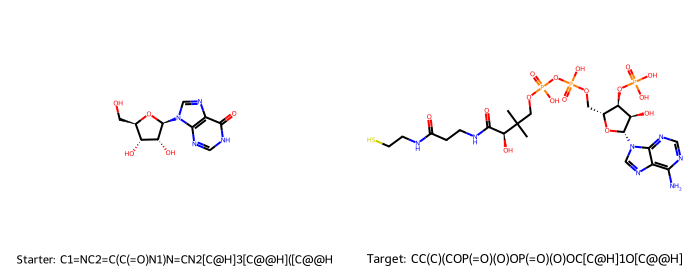

In [111]:
# Extract unique starter and target SMILES from the selected compound's pathways
starterSmilesList = [
    s.strip()
    for raw in reconstructedPathwaysDF_OneCompound["starterSMILES"].dropna().unique()
    for s in raw.split(";") if s.strip()
]
targetSmilesList = [bestSmiles]

starterMols = [(Chem.MolFromSmiles(s), f"Starter: {s[:40]}") for s in starterSmilesList]
targetMols  = [(Chem.MolFromSmiles(s), f"Target: {s[:40]}")  for s in targetSmilesList]

allMols    = [m for m, _ in starterMols + targetMols if m is not None]
allLabels  = [l for m, l in starterMols + targetMols if m is not None]

img = Draw.MolsToGridImage(
    allMols,
    molsPerRow=len(allMols),
    subImgSize=(350, 280),
    legends=allLabels,
)
display(img)

In [53]:
bestSmiles = stepCountsDF.loc[stepCountsDF_selectedCompound, "targetSMILES"]

reconstructedPathwaysDF_OneCompound = (
    reconstructedPathwaysDF[reconstructedPathwaysDF["targetSMILES"] == bestSmiles]
    .reset_index(drop=True)
)

print(f"Selected target (rank {stepCountsDF_selectedCompound + 1}) : {bestSmiles}")
print(f"  pPotency_prediction : {stepCountsDF.loc[stepCountsDF_selectedCompound, 'pPotency_prediction']:.4f}")
print(f"  Routes              : {reconstructedPathwaysDF_OneCompound['routeId'].nunique():,}")
print(f"  Step rows           : {len(reconstructedPathwaysDF_OneCompound):,}")

reconstructedPathwaysDF_OneCompound

Selected target (rank 3) : CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O)[C@@H](O)C(=O)NCCC(=O)NCCS
  pPotency_prediction : 5.9890
  Routes              : 641
  Step rows           : 1,890


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,productStoich,reactionType,rawNetworkReactionString,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId
0,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,1,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...
2,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,3,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen2_route_00...
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,"(1, 1, 1)",Enzymatic,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,matched_by_reaction_and_rule,3,3,False,False,True,high_pPotency_molecule_pathway2_wGen2_route_00...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,641,...,"(1, 1)",Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen3_route_00...
1886,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_proje

In [55]:
completeRouteLevelDF = (
    reconstructedPathwaysDF_OneCompound
    .sort_values(["dirName", "routeId", "step"])
    .groupby("routeId", as_index=False)
    .agg(
        dirName=("dirName", "first"),
        jobName=("jobName", "first"),
        sourceFolderNum=("sourceFolderNum", "first"),
        generationRun=("generationRun", "first"),
        numSteps=("numSteps", "first"),
        searchDepthUsed=("searchDepthUsed", "first"),
        starterSMILES=("starterSMILES", "first"),
        targetSMILES=("targetSMILES", "first"),
        reconstructedPathwayString=("reconstructedPathwayString", "first"),
    )
)

starterTargetPathwayCountsDF = (
    completeRouteLevelDF
    .pivot_table(
        index=["dirName", "jobName", "generationRun", "starterSMILES", "targetSMILES"],
        columns="numSteps",
        values="routeId",
        aggfunc="nunique",
        fill_value=0,
    )
    .rename(columns={
        1: "numOneStepPathways",
        2: "numTwoStepPathways",
        3: "numThreeStepPathways",
    })
    .reset_index()
)

for c in ["numOneStepPathways", "numTwoStepPathways", "numThreeStepPathways"]:
    if c not in starterTargetPathwayCountsDF.columns:
        starterTargetPathwayCountsDF[c] = 0

starterTargetPathwayCountsDF["totalStarterToTargetPathways"] = (
    starterTargetPathwayCountsDF["numOneStepPathways"]
    + starterTargetPathwayCountsDF["numTwoStepPathways"]
    + starterTargetPathwayCountsDF["numThreeStepPathways"]
)

starterTargetPathwayCountsDF = (
    starterTargetPathwayCountsDF
    .sort_values("totalStarterToTargetPathways", ascending=False)
    .reset_index(drop=True)
)

print(f"Total reaction-step rows             : {len(reconstructedPathwaysDF_OneCompound):,}")
print(f"Complete starter --> target pathways: {len(completeRouteLevelDF):,}")
print(f"Job folders reached starter --> target: {starterTargetPathwayCountsDF['dirName'].nunique():,}")

starterTargetPathwayCountsDF

Total reaction-step rows             : 1,890
Complete starter --> target pathways: 641
Job folders reached starter --> target: 3


numSteps,dirName,jobName,generationRun,starterSMILES,targetSMILES,numOneStepPathways,numTwoStepPathways,numThreeStepPathways,totalStarterToTargetPathways
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,3,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,0,0,611,611
1,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,0,27,0,27
2,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,1,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,3,0,0,3


### `Thermodynamic` feasibility check

### Keep only `enzymatic` DORAnet reactions

In [58]:
enzymaticReactionDF = reconstructedPathwaysDF_OneCompound[
    reconstructedPathwaysDF_OneCompound["reactionType"].astype(str).str.lower().str.contains(
        "enzyme|enzymatic|bio|biological",
        na=False
    )
].copy()

print(f"Total reactions: {len(reconstructedPathwaysDF_OneCompound):,}")
print(f"Likely enzymatic reactions: {len(enzymaticReactionDF):,}")

enzymaticReactionDF.head()

Total reactions: 1,890
Likely enzymatic reactions: 1,890


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId,dG_kcal_per_mol,dGStatus,stepDGFeasible
0,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,1,...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False
2,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,3,...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen1_route_00...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,matched_by_reaction_and_rule,2,2,False,True,True,high_pPotency_molecule_pathway2_wGen2_route_00...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,matched_by_reaction_and_rule,3,3,False,False,True,high_pPotency_molecule_pathway2_wGen2_route_00...,None,not_in_cache: NC(=O)c1ccc[n+]([C@@H]2O[C@H](CO...,False


## 2. Use `DORA-XGB` to get feasibility score

In [59]:
reactionDF_DORAXGB = enzymaticReactionDF.copy()
#reactionDF_DORAXGB = enzymaticReactionDF.head(50).copy()

# Clean reaction string for model input
reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

def getFeasibilityScoresAndLabels(rxnStr):
    return pd.Series({
        "feasibilityScore_rule1": by_desc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule1": by_desc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule2": by_asc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule2": by_asc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule3": add_concat_model.predict_proba(rxnStr),
        "feasibilityLabel_rule3": add_concat_model.predict_label(rxnStr),

        "feasibilityScore_rule4": add_subtract_model.predict_proba(rxnStr),
        "feasibilityLabel_rule4": add_subtract_model.predict_label(rxnStr),
    })


reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

reactionDF_DORAXGB[
    [
        "feasibilityScore_rule1",
        "feasibilityLabel_rule1",
        "feasibilityScore_rule2",
        "feasibilityLabel_rule2",
        "feasibilityScore_rule3",
        "feasibilityLabel_rule3",
        "feasibilityScore_rule4",
        "feasibilityLabel_rule4",
    ]
] = reactionDF_DORAXGB["rxn_str"].apply(getFeasibilityScoresAndLabels)

reactionDF_DORAXGB.head()

,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,stepDGFeasible,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,1,...,False,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.000091,0.0,0.023566,0.0,0.133011,0.0,0.742495,1.0
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,False,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.331770,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
2,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,3,...,False,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.000065,0.0,0.044277,0.0,0.096092,0.0,0.014657,0.0
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,False,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.021023,0.0,0.674617,1.0,0.928907,1.0,0.004875,0.0
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,False,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,0.000006,0.0,0.000189,0.0,0.003448,0.0,0.000042,0.0


### Keep only `high feasible` reactions

In [60]:
# Choose which feasibility label to use
feasibilityLabel = "feasibilityLabel_rule3"   # <- change to rule2/rule3/rule4 as needed (Yash's paper says rule3 is the best one)
targetValue = 1                               # <- change if you want a different label value

# Optional safety check
validLabels = [
    "feasibilityLabel_rule1",
    "feasibilityLabel_rule2",
    "feasibilityLabel_rule3",
    "feasibilityLabel_rule4",
]
if feasibilityLabel not in validLabels:
    raise ValueError(f"Invalid feasibilityLabel: {feasibilityLabel}. Choose from {validLabels}")

if feasibilityLabel not in reactionDF_DORAXGB.columns:
    raise KeyError(f"Column '{feasibilityLabel}' not found in reactionDF_DORAXGB")

In [62]:
reactionDF_DORAXGB_highFeasibility = (
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB[feasibilityLabel] == targetValue)
        & (reactionDF_DORAXGB[feasibilityLabel].notna())
    ]
    .sort_values(by=feasibilityLabel, ascending=False)
    .reset_index(drop=True)
)

uniqueReactantStrings_high = set(reactionDF_DORAXGB_highFeasibility["reactants"])
uniqueProductStrings_high = set(reactionDF_DORAXGB_highFeasibility["products"])

uniqueReactantMolecules_high = {
    mol.strip()
    for reactants in reactionDF_DORAXGB_highFeasibility["reactants"]
    for mol in str(reactants).split(".")
    if mol.strip()
}

uniqueProductMolecules_high = {
    mol.strip()
    for products in reactionDF_DORAXGB_highFeasibility["products"]
    for mol in str(products).split(".")
    if mol.strip()
}

print(f"Feasibility label used: {feasibilityLabel} == {targetValue}")
print(f"Number of total reactions: {len(reactionDF_DORAXGB)}")
print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")
print(f"Number of unique reactant strings: {len(uniqueReactantStrings_high)}")
print(f"Number of unique product strings: {len(uniqueProductStrings_high)}")
print(f"Number of unique individual reactant molecules: {len(uniqueReactantMolecules_high)}")
print(f"Number of unique individual product molecules: {len(uniqueProductMolecules_high)}")

reactionDF_DORAXGB_highFeasibility.to_csv(os.path.join(DNADesignResultsDir, f"DORAXGB_highFeasibility_{feasibilityLabel}.csv"),index=False)
reactionDF_DORAXGB_highFeasibility.head()

Feasibility label used: feasibilityLabel_rule3 == 1
Number of total reactions: 1890
Number of high-feasibility reactions: 625
Number of unique reactant strings: 171
Number of unique product strings: 188
Number of unique individual reactant molecules: 146
Number of unique individual product molecules: 191


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,stepDGFeasible,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,False,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,0.000993,0.0,0.012015,0.0,0.678955,1.0,0.007815,0.0
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,False,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.331770,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,False,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.021023,0.0,0.674617,1.0,0.928907,1.0,0.004875,0.0
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,False,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.106657,0.0,0.810378,1.0,0.734912,1.0,0.619011,0.0
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,False,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,0.166996,0.0,0.967761,1.0,0.922012,1.0,0.886861,1.0


In [ ]:
if not reconstructedPathwaysDF.empty:
    # Per-target route counts broken down by step depth
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())
    
    stepCountsDF = (
        reconstructedPathwaysDF
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF["totalRoutes"] = stepCountsDF.sum(axis=1)
    stepCountsDF["pPotency_prediction"] = stepCountsDF.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF = stepCountsDF.sort_values("totalRoutes", ascending=False).reset_index()

print("\nTarget SMILES found:")
stepCountsDF

### Print pathway level details

In [63]:
if not reactionDF_DORAXGB_highFeasibility.empty:

    stepCountsDF_highFeasibility = (
        reactionDF_DORAXGB_highFeasibility
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF_highFeasibility["totalRoutes"] = stepCountsDF_highFeasibility.sum(axis=1)
    stepCountsDF_highFeasibility["pPotency_prediction"] = stepCountsDF_highFeasibility.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF_highFeasibility = (
        stepCountsDF_highFeasibility
        .sort_values("totalRoutes", ascending=False)
        .reset_index()
    )

    # Merge with original stepCountsDF to show retention rate after DORA-XGB filter
    stepCountsDF_highFeasibility = stepCountsDF_highFeasibility.merge(
        stepCountsDF[["targetSMILES", "totalRoutes"]].rename(
            columns={"totalRoutes": "totalRoutes_beforeFilter"}
        ),
        on="targetSMILES",
        how="left",
    )
    stepCountsDF_highFeasibility["retentionRate"] = (
        stepCountsDF_highFeasibility["totalRoutes"]
        / stepCountsDF_highFeasibility["totalRoutes_beforeFilter"]
    ).round(3)

print("\nHigh-feasibility routes by target (DORA-XGB rule3 filter):")
stepCountsDF_highFeasibility


High-feasibility routes by target (DORA-XGB rule3 filter):


numSteps,targetSMILES,1-step,2-step,3-step,totalRoutes,pPotency_prediction,totalRoutes_beforeFilter,retentionRate
0,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,1,19,464,484,5.989,641,0.755


### Summarize unique DORAnet rules

Many reactions may use the same rule. We do not want to annotate millions of reactions one by one. First annotate the rules.

In [64]:
enzymaticReactionDF = reactionDF_DORAXGB_highFeasibility.copy()
ruleSummaryDF = (
    enzymaticReactionDF
    .groupby(["ruleName", "reactionType"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        #numStarterSources=("sourceFolderNum", "nunique"),
        exampleReaction=("reactionString", "first"),
        exampleReactants=("reactants", "first"),
        exampleProducts=("products", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

print(f"unique DORAnet rules    : {enzymaticReactionDF['ruleName'].nunique():,}")
ruleSummaryDF

unique DORAnet rules    : 22


,ruleName,reactionType,numReactions,exampleReaction,exampleReactants,exampleProducts
13,rule0062_18,Enzymatic,250,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...
14,rule0062_19,Enzymatic,134,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](C)O[C@H]1n1cnc2c(...
18,rule0165_2,Enzymatic,92,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...
15,rule0073_5,Enzymatic,37,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...
9,rule0028_35,Enzymatic,30,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1ncn2[C@@]1(CO)OC[C@@H](O)[C@H]1O
12,rule0062_17,Enzymatic,21,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC(C)(C#N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH...
16,rule0121_1,Enzymatic,7,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...
19,rule0166_2,Enzymatic,6,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(N)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c(...
17,rule0164_2,Enzymatic,6,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CCO[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc32)O...
10,rule0042_09,Enzymatic,6,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)NC(C)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc3...


### Add required placeholder columns

In [65]:
enzymeAnnotationDF = ruleSummaryDF.copy()

enzymeAnnotationDF["suggestedEnzymeClass"] = ""
enzymeAnnotationDF["ecNumber"] = ""
enzymeAnnotationDF["enzymeName"] = ""
enzymeAnnotationDF["uniprotAccession"] = ""
enzymeAnnotationDF["sourceDatabase"] = ""
enzymeAnnotationDF["reactionSimilarity"] = ""
enzymeAnnotationDF["enzymeConfidence"] = ""
enzymeAnnotationDF["notes"] = ""
enzymeAnnotationDF.head()

,ruleName,reactionType,numReactions,exampleReaction,exampleReactants,exampleProducts,suggestedEnzymeClass,ecNumber,enzymeName,uniprotAccession,sourceDatabase,reactionSimilarity,enzymeConfidence,notes
13,rule0062_18,Enzymatic,250,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,,,,,,,,
14,rule0062_19,Enzymatic,134,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](C)O[C@H]1n1cnc2c(...,,,,,,,,
18,rule0165_2,Enzymatic,92,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,,,,,,,,
15,rule0073_5,Enzymatic,37,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,,,,,,,,
9,rule0028_35,Enzymatic,30,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1ncn2[C@@]1(CO)OC[C@@H](O)[C@H]1O,,,,,,,,


## 3. Read DORAnet reaction ruleset file to extract `UniProt ID` for each `reaction rule`

In [66]:
doranetRulesetDF = pd.read_csv(dataDir + "/DORAnet/JN3604IMT_rules.tsv", sep="\t")

print(doranetRulesetDF.shape)
print(doranetRulesetDF.columns.tolist())
doranetRulesetDF.head()

(3604, 5)
['Name', 'Reactants', 'SMARTS', 'Products', 'Comments']


,Name,Reactants,SMARTS,Products,Comments
0,rule0001_01,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...
1,rule0001_02,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...
2,rule0001_03,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...
3,rule0001_04,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...
4,rule0001_05,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,NaN


### Find the number of common reaction rules between `DORAnet` diversification and ruleset table from actual package

In [67]:
reactionRuleSet = set(reactionDF_DORAXGB_highFeasibility["ruleName"].dropna().astype(str).str.strip())
tsvRuleSet = set(doranetRulesetDF["Name"].dropna().astype(str).str.strip())

matchedRuleSet = reactionRuleSet.intersection(tsvRuleSet)
missingRuleSet = reactionRuleSet.difference(tsvRuleSet)

print(f"Rules present in DORAnet diversification run: {len(reactionRuleSet):,}")
print(f"Rules matched from DORAnet package: {len(matchedRuleSet):,}")
print(f"Rules missing from DORAnet package: {len(missingRuleSet):,}")

print("\nMatched rules:")
print(sorted(list(matchedRuleSet))[:20])

print("\nMissing rules:")
print(sorted(list(missingRuleSet))[:20])

Rules present in DORAnet diversification run: 22
Rules matched from DORAnet package: 22
Rules missing from DORAnet package: 0

Matched rules:
['rule0003_176', 'rule0007_161', 'rule0007_198', 'rule0011_49', 'rule0011_50', 'rule0011_51', 'rule0015_21', 'rule0017_16', 'rule0024_52', 'rule0028_35', 'rule0042_09', 'rule0048_5', 'rule0062_17', 'rule0062_18', 'rule0062_19', 'rule0073_5', 'rule0121_1', 'rule0164_2', 'rule0165_2', 'rule0166_2']

Missing rules:
[]


### Extract `UniProt IDs` from `DORAnet` reaction rules

In [68]:
def splitUniProtIds(idString):
    if pd.isna(idString):
        return []
    return [x.strip() for x in str(idString).split(";") if x.strip()]


ruleInfoDF = doranetRulesetDF.copy()

ruleInfoDF = ruleInfoDF.rename(columns={
    "Name": "ruleName",
    "Reactants": "ruleReactants",
    "SMARTS": "ruleSMARTS",
    "Products": "ruleProducts",
    "Comments": "candidateUniProtRaw",
})

ruleInfoDF["ruleName"] = ruleInfoDF["ruleName"].astype(str).str.strip()
ruleInfoDF["candidateUniProtList"] = ruleInfoDF["candidateUniProtRaw"].apply(splitUniProtIds)
ruleInfoDF["numCandidateUniProt"] = ruleInfoDF["candidateUniProtList"].apply(len)

ruleInfoDF = ruleInfoDF[
    [
        "ruleName",
        "ruleReactants",
        "ruleProducts",
        "ruleSMARTS",
        "candidateUniProtRaw",
        "numCandidateUniProt",
    ]
].copy()



print(f"ruleInfoDF rows: {len(ruleInfoDF):,}")
ruleInfoDF

ruleInfoDF rows: 3,604


,ruleName,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt
0,rule0001_01,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...,10
1,rule0001_02,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...,263
2,rule0001_03,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...,29
3,rule0001_04,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...,42
4,rule0001_05,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,NaN,0
...,...,...,...,...,...,...
3599,rule1152_1,Any;Any,Any;Any,[#6;$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[#...,Q8ZUN8,1
3600,rule1152_2,Any;Any,Any;Any,[#6;!$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[...,B9TTF1,1
3601,rule1164_1,Any;WATER,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1:&@[#6&R]:&@[#6&R]:&@[...,Q972I2,1
3602,rule1165_1,Any;H2O2,Any;WATER,[#6;$([#6&!R]-[#6&R]1:&@[#6&R]:&@[#6&R]:&@[#6&...,Q972I2,1


## 4. Merge rule information into `reactionDF`

This connects DORAnet reactions with the rule SMARTS and UniProt candidate list.

In [70]:
reactionDF_wUniprotID = reactionDF_DORAXGB_highFeasibility.merge(ruleInfoDF,on="ruleName",how="left")

reactionDF_wUniprotID["hasRuleLookup"] = reactionDF_wUniprotID["ruleSMARTS"].notna()

print(reactionDF_wUniprotID["hasRuleLookup"].value_counts(dropna=False))
reactionDF_wUniprotID

hasRuleLookup
True    625
Name: count, dtype: int64


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,0.678955,1.0,0.007815,0.0,Any,Any,([#6;$([#6&R]1-&@[#8&R]-&@[#6&R](-&!@[#6&!R]-&...,A3E7Z6;B8DZQ9;D1NPG0;D5MTT1;D9RZ53;P26997;P965...,10,True
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,0.928907,1.0,0.004875,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,True
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,0.734912,1.0,0.619011,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,True
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,0.922012,1.0,0.886861,1.0,Any;NAD_CoF;NAD_CoF;WATER,NADH_CoF;NADH_CoF;Any,[#6;$([#6&!R]-[#8&!R]);!$([#6&!R](-[#6&R]1-&@[...,A0A0J9X7D2;A1BPP9;A4IP64;A4ISB9;B0S9F2;B0SS41;...,228,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,24,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
621,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,25,...,0.656884,1.0,0.007192,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C

### Check how many `UniProt ID` is associated with each DORAnet reaction

In [112]:
uniprotPerRuleDF = (
    reactionDF_wUniprotID[["ruleName", "candidateUniProtRaw"]]
    .drop_duplicates(subset=["ruleName"])
    .assign(
        uniprotList=lambda df: df["candidateUniProtRaw"]
        .fillna("")
        .str.split(";")
        .apply(lambda ids: [u.strip() for u in ids if u.strip()])
    )
    .assign(numUniqueUniProt=lambda df: df["uniprotList"].apply(len))
    .sort_values("numUniqueUniProt", ascending=False)
    .reset_index(drop=True)
)

# ── Global counts before dropping uniprotList ──────────────────────────────────
allUniprotIDs    = [uid for ids in uniprotPerRuleDF["uniprotList"] for uid in ids]
totalUniprotIDs  = len(allUniprotIDs)
uniqueUniprotIDs = len(set(allUniprotIDs))

uniprotPerRuleDF = uniprotPerRuleDF.drop(columns=["uniprotList", "candidateUniProtRaw"])

print(f"Total unique reaction rules : {len(uniprotPerRuleDF):,}")
print(f"Rules with UniProt coverage : {(uniprotPerRuleDF['numUniqueUniProt'] > 0).sum():,}")
print(f"Rules with no UniProt hits  : {(uniprotPerRuleDF['numUniqueUniProt'] == 0).sum():,}")
print(f"Max UniProt IDs per rule    : {uniprotPerRuleDF['numUniqueUniProt'].max():,}")
print(f"Median UniProt IDs per rule : {uniprotPerRuleDF['numUniqueUniProt'].median():.0f}")
print(f"Total UniProt IDs (all rules, with repeats) : {totalUniprotIDs:,}")
print(f"Unique UniProt IDs (across all rules)       : {uniqueUniprotIDs:,}")

uniprotPerRuleDF

Total unique reaction rules : 22
Rules with UniProt coverage : 20
Rules with no UniProt hits  : 2
Max UniProt IDs per rule    : 932
Median UniProt IDs per rule : 63
Total UniProt IDs (all rules, with repeats) : 3,041
Unique UniProt IDs (across all rules)       : 2,804


,ruleName,numUniqueUniProt
0,rule0121_1,932
1,rule0017_16,490
2,rule0003_176,326
3,rule0164_2,228
4,rule0165_2,228
5,rule0062_17,211
6,rule0007_198,171
7,rule0166_2,105
8,rule0015_21,98
9,rule0048_5,90


## 4. Find best `UniProt ID` per rule by `Reaction Center Morgan Fingerprint (RCMFP)` enzyme retrieval similarity search 

Implements workflow from the DORAnet/DORA-XGB → atom mapping → RCMFP → known enzyme retrieval. It uses `ruleBase` as the practical bridge between expanded DORAnet rule names such as `rule0003_170` and known reference coarse operator IDs such as `rule0003`, then ranks candidate natural enzyme precedents by RCMFP Tanimoto similarity.

Use this tool: https://github.com/stefanpate/ergochemics/tree/main#

### Patch `RDKit/ergochemics` compatibility

This preserves atom-map labels. Do not use a patch that clears atom-map numbers, because RCMFP needs atom maps to infer reaction centers.

In [71]:
# User paths
ERGOCHEMICS_SRC = "/users/sghosh6/DTRA_project/MACAW/ergochemics/src"
if ERGOCHEMICS_SRC not in sys.path: sys.path.insert(0, ERGOCHEMICS_SRC)

import ergochemics.mapping as egmap
import ergochemics.similarity as egsim
print("RDKit version:", rdBase.rdkitVersion); print("ergochemics mapping file:", egmap.__file__)

_RDKit_MolToSmiles_original = rdmolfiles.MolToSmiles

def MolToSmiles_compat(mol, *args, **kwargs):
    kwargs.pop("ignoreAtomMapNumbers", None)
    return _RDKit_MolToSmiles_original(mol, *args, **kwargs)

Chem.MolToSmiles = MolToSmiles_compat; egmap.Chem.MolToSmiles = MolToSmiles_compat; egsim.Chem.MolToSmiles = MolToSmiles_compat
operator_map_reaction, get_reaction_center = egmap.operator_map_reaction, egmap.get_reaction_center
ReactionFingerprinter, MolFeaturizer = egsim.ReactionFingerprinter, egsim.MolFeaturizer
print("Patch test:", Chem.MolToSmiles(Chem.MolFromSmiles("[CH3:1][OH:2]"), ignoreAtomMapNumbers=True))

RDKit version: 2023.09.5
ergochemics mapping file: /users/sghosh6/DTRA_project/MACAW/ergochemics/src/ergochemics/mapping.py
Patch test: [CH3:1][OH:2]


### Normalize DORAnet reaction strings and `atom-map` all reactions

In [72]:
def normalize_reaction_string(rxn):
    if pd.isna(rxn): return None
    rxn = str(rxn).strip().replace(" ", "")
    if rxn.count(">") == 2 and ">>" in rxn: return rxn
    parts = rxn.split(">")
    return f"{parts[0]}>>{parts[2]}" if len(parts) == 3 else None

def map_query_reaction_with_rule(row):
    rxn, ruleSMARTS = row.get("queryReaction"), row.get("ruleSMARTS")
    if pd.isna(rxn) or str(rxn).strip() == "": return None, "missing_queryReaction"
    if pd.isna(ruleSMARTS) or str(ruleSMARTS).strip() == "": return None, "missing_ruleSMARTS"
    rxn, ruleSMARTS, lastError = str(rxn).replace(" ", ""), str(ruleSMARTS).strip(), None
    if ">>" not in rxn: return None, "invalid_queryReaction_no_double_arrow"
    if ">>" not in ruleSMARTS: return None, "invalid_ruleSMARTS_no_double_arrow"
    for explicitHsFlag, statusLabel in [(False, "mapped"), (True, "mapped_explicit_h")]:
        try:
            result = operator_map_reaction(rxn=rxn, operator=ruleSMARTS, explicit_hs=explicitHsFlag, quiet=True)
            if result.did_map and result.atom_mapped_smarts is not None: return result.atom_mapped_smarts, statusLabel
            lastError = f"{statusLabel}_failed"
        except Exception as exc: lastError = f"mapping_error:{type(exc).__name__}:{exc}"
    return None, lastError

AtomMapDF = reactionDF_wUniprotID.copy()
AtomMapDF["queryReaction"] = AtomMapDF["reactionString"].apply(normalize_reaction_string)
AtomMapDF = AtomMapDF[AtomMapDF["queryReaction"].notna() & AtomMapDF["ruleSMARTS"].notna()].drop(columns=["queryMappedReaction", "rcmfpMappingStatus"], errors="ignore").copy()

mappedPairs = AtomMapDF.progress_apply(map_query_reaction_with_rule, axis=1)
AtomMapDF[["queryMappedReaction", "rcmfpMappingStatus"]] = pd.DataFrame(mappedPairs.tolist(), index=AtomMapDF.index)
sucessAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].notna()].copy() 
failedAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].isna()].copy()
print(AtomMapDF["rcmfpMappingStatus"].value_counts(dropna=False))
print("Successful atom mapping:", len(sucessAtomMapDF), "| Failed:", len(failedAtomMapDF))
sucessAtomMapDF.shape

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [00:04<00:00, 147.34it/s]

rcmfpMappingStatus
mapped    625
Name: count, dtype: int64
Successful atom mapping: 625 | Failed: 0


(625, 55)

### Compute `RCMFP fingerprints`

In [75]:
TOP_K, MIN_SIMILARITY, FP_SIDE_LENGTH, FP_RADIUS = 20, 0.0, 2048, 2

In [76]:
reactionFingerprinter = ReactionFingerprinter(radius=FP_RADIUS, length=FP_SIDE_LENGTH, mol_featurizer=MolFeaturizer())

def compute_rcmfp_with_status(mappedRxn):
    try:
        if pd.isna(mappedRxn) or str(mappedRxn).strip() == "": return None, "missing_mapped_reaction"
        mappedRxn = str(mappedRxn).replace(" ", "")
        if ">>" not in mappedRxn: return None, "invalid_mapped_reaction_no_double_arrow"
        if not pd.Series([mappedRxn]).str.contains(r":\d+\]", regex=True).iloc[0]: return None, "no_atom_map_labels"
        lrc, rrc = get_reaction_center(mappedRxn, mode="combined")
        if len(lrc) == 0 or len(rrc) == 0: return None, f"empty_reaction_center:lrc={len(lrc)}:rrc={len(rrc)}"
        fp = reactionFingerprinter.fingerprint(mappedRxn, output_type="bit", use_rc=True, rc_dist_ub=None)
        return fp.astype(bool), "rcmfp_success"
    except Exception as exc: return None, f"rcmfp_error:{type(exc).__name__}:{exc}"


rcmfpPairs = sucessAtomMapDF["queryMappedReaction"].progress_apply(compute_rcmfp_with_status)
sucessAtomMapDF[["queryRCMFP", "rcmfpStatus"]] = pd.DataFrame(rcmfpPairs.tolist(), index=sucessAtomMapDF.index)
queryRcmfpFailureDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].isna()].copy()
sucessAtomMapDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].notna()].copy().reset_index(drop=True)
sucessAtomMapDF

  1%|▋                                                                                                     | 4/625 [00:00<00:22, 27.23it/s]

{0: 1, 1: 5, 2: 2, 3: 3, 4: 19, 5: 4, 6: 7, 7: 11, 8: 13, 9: 8, 10: 12, 11: 15, 12: 17, 13: 16, 14: 18, 15: 6, 16: 10, 17: 9, 18: 14}
[0, 2, 3, 5, 1, 15, 6, 9, 17, 16, 7, 10, 8, 18, 11, 13, 12, 14, 4]
[1, 2, 3]
{0: 1, 1: 5, 2: 2, 3: 3, 4: 19, 5: 4, 6: 7, 7: 11, 8: 13, 9: 8, 10: 12, 11: 15, 12: 17, 13: 16, 14: 18, 15: 6, 16: 10, 17: 9, 18: 14}
[0, 2, 3, 5, 1, 15, 6, 9, 17, 16, 7, 10, 8, 18, 11, 13, 12, 14, 4]
[1, 2, 3]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 55, 53: 57, 54: 60, 55: 62, 56: 64, 57: 66, 58: 63, 59: 65, 60: 67, 61: 69, 62: 68, 63: 70, 64: 59, 65: 61, 66: 56, 67: 58, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1

  1%|█▏                                                                                                    | 7/625 [00:00<01:03,  9.80it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 57, 53: 60, 54: 63, 55: 65, 56: 61, 57: 64, 58: 67, 59: 70, 60: 68, 61: 71, 62: 56, 63: 59, 64: 62, 65: 66, 66: 69, 67: 72, 68: 73, 69: 55, 70: 58, 71: 51, 72: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 71, 72, 50, 51, 69, 62, 52, 70, 63, 53, 56, 64, 54, 57, 55, 65, 58, 60, 66, 59, 61, 67, 68]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 2

  2%|█▊                                                                                                   | 11/625 [00:01<01:05,  9.39it/s]

...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████▌| 622/625 [01:03<00:00, 11.79it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 55, 53: 57, 54: 60, 55: 58, 56: 61, 57: 59, 58: 62, 59: 63, 60: 65, 61: 67, 62: 64, 63: 66, 64: 68, 65: 70, 66: 69, 67: 71, 68: 56, 69: 51, 70: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 69, 70, 50, 51, 52, 68, 53, 55, 57, 54, 56, 58, 59, 62, 60, 63, 61, 64, 66, 65, 67]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 2

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [01:04<00:00,  9.68it/s]

{0: 1, 1: 7, 2: 8, 3: 9, 4: 2, 5: 3, 6: 4, 7: 5, 8: 10, 9: 11, 10: 13, 11: 16, 12: 18, 13: 19, 14: 20, 15: 21, 16: 22, 17: 23, 18: 24, 19: 25, 20: 26, 21: 27, 22: 28, 23: 29, 24: 31, 25: 34, 26: 36, 27: 39, 28: 41, 29: 37, 30: 40, 31: 45, 32: 47, 33: 46, 34: 48, 35: 32, 36: 35, 37: 38, 38: 42, 39: 43, 40: 44, 41: 30, 42: 33, 43: 14, 44: 17, 45: 12, 46: 15, 47: 6, 48: 49, 49: 50, 50: 51, 51: 52, 52: 54, 53: 57, 54: 59, 55: 61, 56: 63, 57: 60, 58: 62, 59: 64, 60: 66, 61: 65, 62: 67, 63: 56, 64: 58, 65: 53, 66: 55, 67: 68, 68: 69}
[0, 4, 5, 6, 7, 47, 1, 2, 3, 8, 9, 45, 10, 43, 46, 11, 44, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 41, 24, 35, 42, 25, 36, 26, 29, 37, 27, 30, 28, 38, 39, 40, 31, 33, 32, 34, 48, 49, 50, 51, 65, 52, 66, 63, 53, 64, 54, 57, 55, 58, 56, 59, 61, 60, 62, 67, 68]
[1, 2, 3, 4, 5, 6, 49, 50, 68, 69]
{0: 1, 1: 7, 2: 8, 3: 9, 4: 2, 5: 3, 6: 4, 7: 5, 8: 10, 9: 11, 10: 13, 11: 16, 12: 18, 13: 19, 14: 20, 15: 21, 16: 22, 17: 23, 18: 24, 19: 25, 20: 26, 21: 27, 22: 2

,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup,queryReaction,queryMappedReaction,rcmfpMappingStatus,queryRCMFP,rcmfpStatus
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,Any,([#6;$([#6&R]1-&@[#8&R]-&@[#6&R](-&!@[#6&!R]-&...,A3E7Z6;B8DZQ9;D1NPG0;D5MTT1;D9RZ53;P26997;P965...,10,True,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,[CH:1]1([CH2:3][OH:19])[O:5][CH:2]([n:4]2[cH:7...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,NADH_CoF;NADH_CoF;Any,[#6;$([#6&!R]-[#8&!R]);!$([#6&!R](-[#6&R]1-&@[...,A0A0J9X7D2;A1BPP9;A4IP64;A4ISB9;B0S9F2;B0SS41;...,228,True,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,[CH2:97]([CH:99]1[O:101][CH:103]([n:106]2[cH:1...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_rout

In [77]:
print("RCMFP status counts:")
print(sucessAtomMapDF["rcmfpStatus"].value_counts(dropna=False))
print("Valid RCMFP reactions:", len(sucessAtomMapDF))
print("Failed RCMFP reactions:", len(queryRcmfpFailureDF))

RCMFP status counts:
rcmfpStatus
rcmfp_success    625
Name: count, dtype: int64
Valid RCMFP reactions: 625
Failed RCMFP reactions: 0


### Load and align known enzyme reference metadata and RCMFP cache

- loaded from: https://github.com/JBEI/TridentSynthWeb/tree/b17e61040b182ce68b2931f8dbbaf65f370f8c03/data/processed

In [78]:
naturalEnzymeFilePath = os.path.join(dataDir + "/DORAnet/known_enzyme_reactions_union.parquet")
naturalEnzyme_FP_FilePath = os.path.join(dataDir + "/DORAnet/known_rxn_rcmfp_cache.npz")

naturalEnzymeDF = pd.read_parquet(naturalEnzymeFilePath)
naturalEnzymeDF_wFingerprints = np.load(naturalEnzyme_FP_FilePath, allow_pickle=True)
naturalEnzyme_fingerprint_matrix = naturalEnzymeDF_wFingerprints["fingerprints"].astype(bool)
naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices = naturalEnzymeDF_wFingerprints["rc_patterns_lhs"], naturalEnzymeDF_wFingerprints["rc_patterns_rhs"], naturalEnzymeDF_wFingerprints["valid_indices"]
naturalEnzymeReferenceDF = naturalEnzymeDF.iloc[knownValidIndices].reset_index(drop=True).copy()
naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternLHS"], naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternRHS"], naturalEnzymeReferenceDF["knownOriginalIndex"] = naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices
assert len(naturalEnzymeReferenceDF) == naturalEnzyme_fingerprint_matrix.shape[0]
print("Known enzyme reference shape:", naturalEnzymeReferenceDF.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)

Known enzyme reference shape: (54063, 25)
Known enzyme molecular fingerprint matrix shape: (54063, 4096)


### Compute RCMFP fingerprint matrices for `DORAnet` reactions

In [79]:
def make_reverse_fingerprint_matrix(fpMatrix, sideLength=FP_SIDE_LENGTH): return np.hstack([fpMatrix[:, sideLength:], fpMatrix[:, :sideLength]]).astype(bool)
def make_fingerprint_matrix_from_column(df, fpCol):
    validMask = df[fpCol].notna(); metaDF = df.loc[validMask].drop(columns=[fpCol], errors="ignore").reset_index(drop=True)
    fpMatrix = np.vstack(df.loc[validMask, fpCol].to_numpy()).astype(bool); fpReverseMatrix = make_reverse_fingerprint_matrix(fpMatrix)
    return metaDF, fpMatrix, fpReverseMatrix, fpMatrix.sum(axis=1), fpReverseMatrix.sum(axis=1)

queryMetaDF, query_FP_Matrix, query_FP_MatrixReverse, queryPopcounts, queryReversePopcounts = make_fingerprint_matrix_from_column(sucessAtomMapDF, "queryRCMFP")
naturalEnzyme_fingerprint_matrixReverse = make_reverse_fingerprint_matrix(naturalEnzyme_fingerprint_matrix)
knownPopcounts, knownReversePopcounts = naturalEnzyme_fingerprint_matrix.sum(axis=1), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1)

queryKeepCols = ["reactants", "products", "reactionString", "ruleName", "reactionType", "rxn_str", "ruleSMARTS", "candidateUniProtRaw", "numCandidateUniProt", "hasRuleLookup", "queryReaction", "queryMappedReaction", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"]
queryMetaDF = queryMetaDF[[c for c in queryKeepCols if c in queryMetaDF.columns]].copy()
print("Query metadata shape:", queryMetaDF.shape); print("Query molecular fingerprint matrix shape:", query_FP_Matrix.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)
queryMetaDF

Query metadata shape: (625, 22)
Query molecular fingerprint matrix shape: (625, 4096)
Known enzyme molecular fingerprint matrix shape: (54063, 4096)


,reactants,products,reactionString,ruleName,reactionType,rxn_str,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup,...,rcmfpMappingStatus,rcmfpStatus,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1ncn2[C@@]1(CO)OC[C@@H](O)[C@H]1O,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,rule0028_35,Enzymatic,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,([#6;$([#6&R]1-&@[#8&R]-&@[#6&R](-&!@[#6&!R]-&...,A3E7Z6;B8DZQ9;D1NPG0;D5MTT1;D9RZ53;P26997;P965...,10,True,...,mapped,rcmfp_success,0.000993,0.0,0.012015,0.0,0.678955,1.0,0.007815,0.0
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.331770,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](C)O[C@H]1n1cnc2c(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,True,...,mapped,rcmfp_success,0.021023,0.0,0.674617,1.0,0.928907,1.0,0.004875,0.0
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,True,...,mapped,rcmfp_success,0.106657,0.0,0.810378,1.0,0.734912,1.0,0.619011,0.0
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0165_2,Enzymatic,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,[#6;$([#6&!R]-[#8&!R]);!$([#6&!R](-[#6&R]1-&@[...,A0A0J9X7D2;A1BPP9;A4IP64;A4ISB9;B0S9F2;B0SS41;...,228,True,...,mapped,rcmfp_success,0.166996,0.0,0.967761,1.0,0.922012,1.0,0.886861,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.331770,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
621,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&R]);!$([#8&!R...,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,True,...,mapped,rcmfp_success,0.001048,0.0,0.093043,0.0,0.656884,1.0,0.007192,0.0
622,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0165_2,Enzymatic,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,[#6;$([#6&!R]-[#8&!R]);!$([#6&!R](-[#6&R]1-&@[...,A0A0J9X7D2;A1BPP9;A4IP64;A4ISB9;B0S9F2;B0SS41;...,228,True,...,mapped,rcmfp_success,0.166996,0.0,0.967761,1.0,0.922012,1.0,0.886861,1.0
623,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,rule0073_5,Enzymatic,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,[#6;$([#6&!R]-&!@[#6&R]);!$([#6&!R]-&!@[#6&R]1...,E3VWJ1;F1T282;F1T283;I1TEM3;O94142;Q16850;Q2MJ...,11,True,...,mapped,rcmfp_success,0.002562,0.0,0.738403,1.0,0.627660,1.0,0.740460,1.0


### Add `ruleBase` column to known enzyme reference and query metadata from DORAnet reactions

This avoids forcing known reference rules into expanded DORAnet rule names. It uses coarse operator family IDs such as `rule0003` and then lets RCMFP decide the closest natural reaction within that family.

In [80]:
def get_rule_base(x): return None if pd.isna(x) else str(x).strip().split("_")[0]
def parse_operator_list(x):
    if isinstance(x, np.ndarray): return [str(v).strip() for v in x.tolist() if v is not None and str(v).strip()]
    if isinstance(x, (list, tuple, set)): return [str(v).strip() for v in list(x) if v is not None and str(v).strip()]
    if x is None or pd.isna(x): return []
    s = str(x).strip()
    if s in ["", "nan", "None", "[]"]: return []
    try:
        parsed = ast.literal_eval(s)
        return [str(v).strip() for v in list(parsed)] if isinstance(parsed, (list, tuple, set, np.ndarray)) else [str(parsed).strip()]
    except Exception:
        for sep in ["|", ";", ","]:
            if sep in s: return [v.strip().strip("'\"") for v in s.split(sep) if v.strip()]
        return [s]

def choose_known_rule_base(row):
    top = row.get("top_mapped_operator")
    if top is not None and not pd.isna(top) and str(top).strip().startswith("rule"): return str(top).strip(), "top_mapped_operator"
    for op in parse_operator_list(row.get("all_mapped_operators")):
        if str(op).startswith("rule"): return str(op), "all_mapped_operators"
    return None, "no_ruleBase"



# Build ruleBase in naturalEnzymeReferenceDF
naturalEnzymeReferenceDF = naturalEnzymeReferenceDF.copy()

naturalEnzymeReferenceDF[["ruleBase", "ruleBaseSource"]] = naturalEnzymeReferenceDF.apply(
    lambda row: pd.Series(choose_known_rule_base(row)),
    axis=1
)

# If you want only base (e.g., rule0001 from rule0001_22), normalize:
naturalEnzymeReferenceDF["ruleBase"] = naturalEnzymeReferenceDF["ruleBase"].apply(get_rule_base)

# Rebuild metadata
queryMetaDF = queryMetaDF.reset_index(drop=True).copy()
knownMetaDF = naturalEnzymeReferenceDF.reset_index(drop=True).copy()

queryMetaDF["queryRowId"] = np.arange(len(queryMetaDF))
knownMetaDF["knownRowId"] = np.arange(len(knownMetaDF))

queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

# Create ruleBase first, then use it
queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

if "ruleBase" not in knownMetaDF.columns:
    raise KeyError("knownMetaDF does not contain ruleBase after merge. Check knownOriginalIndex alignment.")

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

knownIndicesByRuleBase = {
    ruleBase: idx.to_numpy()
    for ruleBase, idx in knownMetaDF.dropna(subset=["_ruleKey"]).groupby("_ruleKey").groups.items()
}

queryRuleBases = set(queryMetaDF["ruleBase"].dropna().astype(str))
knownRuleBases = set(knownMetaDF["ruleBase"].dropna().astype(str))

print("Source of known enzymetic data base:")
print(knownMetaDF["ruleBaseSource"].value_counts(dropna=False))
print("Reaction rules present in DORAnet reaction mechanism:", len(queryRuleBases))
print("Reaction rules present in known enzymetic data base:", len(knownRuleBases))
print("Overlapping base reaction rules:", len(queryRuleBases.intersection(knownRuleBases)))
print("Example overlaps:", sorted(queryRuleBases.intersection(knownRuleBases))[:20])

Source of known enzymetic data base:
ruleBaseSource
top_mapped_operator     45763
all_mapped_operators     6882
no_ruleBase              1418
Name: count, dtype: int64
Reaction rules present in DORAnet reaction mechanism: 17
Reaction rules present in known enzymetic data base: 687
Overlapping base reaction rules: 16
Example overlaps: ['rule0003', 'rule0007', 'rule0011', 'rule0017', 'rule0024', 'rule0028', 'rule0042', 'rule0048', 'rule0062', 'rule0073', 'rule0121', 'rule0164', 'rule0165', 'rule0166', 'rule0393', 'rule0491']


### Run `ruleBase` constrained RCMFP enzyme retrieval

For each query reaction (present in DORAnet reaction network) it searches the known natural enzyme reaction database, computes RCMFP Tanimoto similarity, keeps the best matches and stores the results in `matchedRCMFP_DF`. Final returned matches are ranked from highest to lowest RCMFP similarity.

In [81]:
# this function calculates Tanimoto similarity between one query fingerprint and many known enzyme reference fingerprints
def compute_tanimoto_similarity(queryPackedRow, queryPop, refPackedMatrix, refPopcounts, popcount8):
    inter = popcount8[np.bitwise_and(refPackedMatrix, queryPackedRow)].sum(axis=1).astype(np.float32); union = refPopcounts + queryPop - inter
    scores = np.zeros(len(refPopcounts), dtype=np.float32); valid = union > 0; scores[valid] = inter[valid] / union[valid]
    return scores

# this function retrieves the top enzyme reference matches for one query reaction
def retrieve_similar_reactions(queryIdx, topK=TOP_K, minSimilarity=MIN_SIMILARITY):
    queryRuleBase = queryMetaDF.loc[queryIdx, "_ruleKey"]
    candidateIdx, searchMode = (knownIndicesByRuleBase[queryRuleBase], "same_ruleBase") if pd.notna(queryRuleBase) and queryRuleBase in knownIndicesByRuleBase else (np.arange(len(knownMetaDF)), "full_database_fallback")
    qPacked, qPop = queryPacked[queryIdx], queryPopcounts[queryIdx]
    scores = np.maximum(compute_tanimoto_similarity(qPacked, qPop, knownPacked[candidateIdx], knownPopcounts[candidateIdx], popcount8), compute_tanimoto_similarity(qPacked, qPop, knownPackedReverse[candidateIdx], knownReversePopcounts[candidateIdx], popcount8))
    validLocal = np.where(scores > minSimilarity)[0]
    if len(validLocal) == 0: return []
    topLocal = validLocal[np.argpartition(-scores[validLocal], topK - 1)[:topK]] if len(validLocal) > topK else validLocal
    topLocal = topLocal[np.argsort(-scores[topLocal])]
    return [{"queryRowId": int(queryIdx), "rank": rank, "knownRowId": int(candidateIdx[localIdx]), "rcmfpSimilarity": float(scores[localIdx]), "searchMode": searchMode, "numCandidatesSearched": int(len(candidateIdx))} for rank, localIdx in enumerate(topLocal, start=1)]

query_FP_Matrix, naturalEnzyme_fingerprint_matrix, naturalEnzyme_fingerprint_matrixReverse = query_FP_Matrix.astype(bool), naturalEnzyme_fingerprint_matrix.astype(bool), naturalEnzyme_fingerprint_matrixReverse.astype(bool)
queryPacked, knownPacked, knownPackedReverse = np.packbits(query_FP_Matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrixReverse.astype(np.uint8), axis=1)
queryPopcounts, knownPopcounts, knownReversePopcounts = query_FP_Matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1).astype(np.int32)
popcount8 = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

allHitRecords = []
for queryIdx in tqdm(range(len(queryMetaDF)), desc="RCMFP enzyme retrieval"): allHitRecords.extend(retrieve_similar_reactions(queryIdx))
matchedRCMFP_DF = pd.DataFrame(allHitRecords)
print("Total hits:", len(matchedRCMFP_DF)); print(matchedRCMFP_DF["searchMode"].value_counts(dropna=False))
matchedRCMFP_DF.head()

RCMFP enzyme retrieval: 100%|███████████████████████████████████████████████████████████████████████████| 625/625 [00:01<00:00, 417.20it/s]

Total hits: 11952
searchMode
same_ruleBase             11892
full_database_fallback       60
Name: count, dtype: int64


,queryRowId,rank,knownRowId,rcmfpSimilarity,searchMode,numCandidatesSearched
0,0,1,53747,0.314815,same_ruleBase,439
1,0,2,53746,0.314815,same_ruleBase,439
2,0,3,53748,0.314815,same_ruleBase,439
3,0,4,53745,0.314815,same_ruleBase,439
4,0,5,53742,0.213115,same_ruleBase,439


### Build full summary, filter Moderate/Strong, deduplicate and save outputs

In [82]:
def print_section(title):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)

def print_saved_file(label, path):
    print(f"{label}: {path}")

def classify_precedent(sim):
    if pd.isna(sim): return "No natural precedent retrieved"
    if sim >= 0.60: return "Strong natural enzyme precedent"
    if sim >= 0.35: return "Moderate natural enzyme precedent"
    if sim > 0: return "Weak precedent; likely enzyme-engineering risk"
    return "No useful RCMFP precedent"

queryDisplayCols = [c for c in ["queryRowId", "reactionString", "ruleName", "ruleBase", "reactionType", "queryReaction", "queryMappedReaction", "candidateUniProtRaw", "numCandidateUniProt", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"] if c in queryMetaDF.columns]
knownDisplayCols = [c for c in ["knownRowId", "knownOriginalIndex", "ruleBase", "ruleBaseSource", "rxn_idx", "mapped", "unmapped", "orig_rxn_text", "rule", "source", "quality", "natural", "organism", "protein_refs", "protein_db", "ec_num", "top_mapped_operator", "all_mapped_operators"] if c in knownMetaDF.columns]

matchedRCMFP_DF = matchedRCMFP_DF.merge(queryMetaDF[queryDisplayCols], on="queryRowId", how="left", suffixes=("", "_query")).merge(knownMetaDF[knownDisplayCols], on="knownRowId", how="left", suffixes=("", "_known")).sort_values(["queryRowId", "rank"]).reset_index(drop=True)
matchedRCMFP_DF.head()

,queryRowId,rank,knownRowId,rcmfpSimilarity,searchMode,numCandidatesSearched,reactionString,ruleName,ruleBase,reactionType,...,rule,source,quality,natural,organism,protein_refs,protein_db,ec_num,top_mapped_operator,all_mapped_operators
0,0,1,53747,0.314815,same_ruleBase,439,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,rule0028_35,rule0028,Enzymatic,...,([#6:1].[#6:2]-[#6:3])>>([#6:2].[#6:1]-[#6:3]),direct,1.0,NaN,None,[],None,5.3.1.5,rule0028,[rule0028]
1,0,2,53746,0.314815,same_ruleBase,439,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,rule0028_35,rule0028,Enzymatic,...,([#6:1].[#6:2]-[#6:3])>>([#6:2].[#6:1]-[#6:3]),direct reversed,1.0,NaN,None,[],None,5.3.1.5,rule0028,[rule0028]
2,0,3,53748,0.314815,same_ruleBase,439,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,rule0028_35,rule0028,Enzymatic,...,([#6:1].[#6:2]-[#6:3])>>([#6:2].[#6:1]-[#6:3]),direct reversed,1.0,NaN,None,[],None,5.3.1.5,rule0028,[rule0028]
3,0,4,53745,0.314815,same_ruleBase,439,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,rule0028_35,rule0028,Enzymatic,...,([#6:1].[#6:2]-[#6:3])>>([#6:2].[#6:1]-[#6:3]),direct,1.0,NaN,None,[],None,5.3.1.5,rule0028,[rule0028]
4,0,5,53742,0.213115,same_ruleBase,439,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,rule0028_35,rule0028,Enzymatic,...,([#6:1].[#6:2]-[#6:3])>>([#6:2].[#6:1]-[#6:3]),direct reversed,0.5,NaN,None,[],None,5.3.1.4,rule0028,[rule0028]


### Marge information of natural enzyme reference to `reactionDF_wUniprotID`

In [83]:
# User options
keyCol = "reactionString"
scoreCol = "rcmfpSimilarity"
keepMode = "best"   # "best" or "all"
bestAscending = False  # False => highest score is best, True => lowest is best

sourceDF = matchedRCMFP_DF.copy()

if keepMode == "best":
    sourceToMerge = (
        sourceDF
        .sort_values(scoreCol, ascending=bestAscending, na_position="last")
        .drop_duplicates(subset=[keyCol], keep="first")
    )
elif keepMode == "all":
    sourceToMerge = sourceDF
else:
    raise ValueError("keepMode must be 'best' or 'all'")

# only add columns that don't already exist in target
newCols = [c for c in sourceToMerge.columns if c not in reactionDF_wUniprotID.columns and c != keyCol]

reactionDF_wUniprotID = reactionDF_wUniprotID.merge(
    sourceToMerge[[keyCol] + newCols],
    on=keyCol,
    how="inner"   # keep only rows present in source
)

print(f"Mode: {keepMode}")
print(f"Rows after merge: {len(reactionDF_wUniprotID):,}")
print(f"Added columns: {len(newCols)}")
reactionDF_wUniprotID

Mode: best
Rows after merge: 625
Added columns: 28


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,rule,source,quality,natural,organism,protein_refs,protein_db,ec_num,top_mapped_operator,all_mapped_operators
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,([#6:1].[#6:2]-[#6:3])>>([#6:2].[#6:1]-[#6:3]),direct reversed,1.000000,NaN,None,[],None,5.3.1.5,rule0028,[rule0028]
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.000000,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.000000,NaN,None,[],None,2.3.1.303,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],suggested,1.000000,1.0,Homo sapiens,['Q96PB1'],uniprot,2.3.1.45,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,[#6:1].[#6:2]1:[#6:3]:[#6:4]:[#6:5]:[#7+:6]:[#...,direct,0.008197,0.0,Ovis aries,[],None,1.2.1.3,rule0165,[rule0165]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,24,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.000000,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
621,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,25,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.000000,NaN,None,[],None,2.3.1.303,rule0062,"[rule0022, rule0060, rule0062, rule

### Find best `UniProt ID` per DORANet reaction rule

In [85]:
uniprotPattern = re.compile(
    r"([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z0-9]{3}[0-9]){1,2})"
)

def extractUniProtID(x):
    if pd.isna(x):
        return []
    ids = uniprotPattern.findall(str(x))
    seen, out = set(), []
    for uid in ids:
        if uid not in seen:
            out.append(uid)
            seen.add(uid)
    return out


tmp = matchedRCMFP_DF.copy()

tmp["knownProteinRefList"] = tmp["protein_refs"].apply(extractUniProtID)

tmp = tmp[
    tmp["knownProteinRefList"].apply(len) > 0
].copy()

tmp = tmp.explode("knownProteinRefList").rename(
    columns={"knownProteinRefList": "rcmfpSupportedUniProt"}
)

tmp["rcmfpSimilarity"] = pd.to_numeric(
    tmp["rcmfpSimilarity"],
    errors="coerce"
)

tmp["rank"] = pd.to_numeric(
    tmp["rank"],
    errors="coerce"
)

ruleRcmfpUniProtScoreDF = (
    tmp
    .groupby(["ruleName", "ruleBase", "rcmfpSupportedUniProt"])
    .agg(
        numSupportingHits=("knownRowId", "nunique"),
        bestRCMFPSimilarity=("rcmfpSimilarity", "max"),
        meanRCMFPSimilarity=("rcmfpSimilarity", "mean"),
        bestRank=("rank", "min"),
        exampleKnownRowId=("knownRowId", "first"),
        exampleKnownReaction=("orig_rxn_text", "first"),
        exampleKnownOrganism=("organism", "first"),
        exampleKnownEcNumber=("ec_num", "first"),
        exampleProteinRefs=("protein_refs", "first"),
    )
    .reset_index()
)

ruleRcmfpUniProtScoreDF["rcmfpProteinRefScore"] = (
    ruleRcmfpUniProtScoreDF["bestRCMFPSimilarity"] * 100
    + np.log1p(ruleRcmfpUniProtScoreDF["numSupportingHits"]) * 10
    - ruleRcmfpUniProtScoreDF["bestRank"] * 0.1
)

ruleRcmfpUniProtScoreDF = ruleRcmfpUniProtScoreDF.sort_values(
    [
        "ruleName",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
    ],
    ascending=[True, False, False, False, True]
)

bestRCMFPUniProtByRuleDF = (
    ruleRcmfpUniProtScoreDF
    .groupby("ruleName")
    .head(1)
    .reset_index(drop=True)
)

bestRCMFPUniProtByRuleDF[
    [
        "ruleName",
        "rcmfpSupportedUniProt",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "meanRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
        "exampleKnownOrganism",
        "exampleKnownEcNumber",
        "exampleKnownReaction",
    ]
].head()

,ruleName,rcmfpSupportedUniProt,rcmfpProteinRefScore,bestRCMFPSimilarity,meanRCMFPSimilarity,numSupportingHits,bestRank,exampleKnownOrganism,exampleKnownEcNumber,exampleKnownReaction
0,rule0003_176,A0A0H4SN47,30.028112,0.204420,0.202753,2,14,Ogataea glucozyma,1.1.1.320,1-(furan-2-yl)ethanone + NADPH + H+ = (1S)-1-(...
1,rule0007_161,P27169,27.072301,0.178862,0.178862,2,18,Homo sapiens,3.1.1.2,"2,2,2-trifluoroethyl acetate + H2O = 2,2,2-tri..."
2,rule0007_198,P23141,24.452083,0.183206,0.179389,1,8,Homo sapiens,3.1.1.1,6-monoacetylmorphine + H2O = morphine + acetate
3,rule0011_49,Q27869,29.874714,0.232432,0.232432,1,3,Drosophila melanogaster,2.1.1.77,S-adenosyl-L-methionine + VYP(iso-D)HA = S-ade...
4,rule0011_50,A0A0U2YR01,25.302456,0.191710,0.191710,1,8,Plagiochasma appendiculatum,2.1.1.104,S-adenosyl-L-methionine + coniferyl alcohol = ...


### Merge back `RCMFP-supported UniProt ID` with `reactionDF_wUniprotID`

In [86]:
# Columns to keep + rename map
rename_map = {
    "rcmfpSupportedUniProt": "bestRCMFP_UniProtID",
    "rcmfpProteinRefScore": "bestRCMFP_UniProtScore",
    "bestRCMFPSimilarity": "bestRCMFP_SimilarityScore",
    "meanRCMFPSimilarity": "meanRCMFP_Similarity_byRule",
    "numSupportingHits": "numRCMFP_SupportingHits_byRule",
    "bestRank": "bestRCMFPRank_byRule",
    "exampleKnownRowId": "bestRCMFP_RowId",
    "exampleKnownReaction": "bestRCMFP_Reaction",
    "exampleKnownOrganism": "bestRCMFP_Organism",
    "exampleKnownEcNumber": "bestRCMFP_ECnumber",
    "exampleProteinRefs": "bestRCMFP_ProteinRefs",
}

bestRCMFPForMergeDF = (
    bestRCMFPUniProtByRuleDF[["ruleName", *rename_map]]
    .rename(columns=rename_map)
)

reactionDF_wBestRCMFP_Similarity = (
    reactionDF_wUniprotID
    .merge(bestRCMFPForMergeDF, on="ruleName", how="left")
    .assign(
        hasbestRCMFP_UniProtID=lambda df: (
            df["bestRCMFP_UniProtID"].fillna("").astype(str).str.len().gt(0)
        )
    )
)

print("reactionDF_wBestRCMFP_Similarity created")
print(f"Rows in reactionDF_wUniprotID              : {len(reactionDF_wUniprotID):,}")
print(f"Rows in reactionDF_wBestRCMFP_Similarity   : {len(reactionDF_wBestRCMFP_Similarity):,}")
print(f"Rows with best RCMFP UniProt               : {reactionDF_wBestRCMFP_Similarity['hasbestRCMFP_UniProtID'].sum():,}")
print(f"Unique best RCMFP UniProt IDs              : {reactionDF_wBestRCMFP_Similarity['bestRCMFP_UniProtID'].nunique():,}")

reactionDF_wBestRCMFP_Similarity.head()

reactionDF_wBestRCMFP_Similarity created
Rows in reactionDF_wUniprotID              : 625
Rows in reactionDF_wBestRCMFP_Similarity   : 625
Rows with best RCMFP UniProt               : 582
Unique best RCMFP UniProt IDs              : 18


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,bestRCMFP_SimilarityScore,meanRCMFP_Similarity_byRule,numRCMFP_SupportingHits_byRule,bestRCMFPRank_byRule,bestRCMFP_RowId,bestRCMFP_Reaction,bestRCMFP_Organism,bestRCMFP_ECnumber,bestRCMFP_ProteinRefs,hasbestRCMFP_UniProtID
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,0.125000,0.124440,1.0,19.0,39774.0,alpha-D-glucose = alpha-D-fructose {r},Streptomyces rubiginosus,5.3.1.5,['P24300'],True
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,0.132565,0.128115,23.0,1.0,12579.0,acetyl-CoA + n-hexyl beta-D-glucopyranoside = ...,Escherichia coli,2.3.1.79,['P77791'],True
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,0.112637,0.107098,3.0,13.0,11211.0,"2 acetyl-CoA + taxadien-5alpha-acetoxy-9alpha,...",Taxus cuspidata,2.3.1.162,['Q5Y9C7'],True
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,0.112637,0.107098,3.0,13.0,11211.0,"2 acetyl-CoA + taxadien-5alpha-acetoxy-9alpha,...",Taxus cuspidata,2.3.1.162,['Q5Y9C7'],True
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,0.207386,0.207386,6.0,6.0,2280.0,1-octadecanol + 2 NAD+ + H2O = octadecanoic ac...,Geobacillus thermodenitrificans,1.1.1.192,['A4IP64'],True


In [88]:
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.drop(
    columns=[
        'reactantSetCanonical', 'productSetCanonical',
        'rxn_str', 'feasibilityScore_rule1', 'feasibilityLabel_rule1',
        'feasibilityLabel_rule2', 'feasibilityScore_rule3', 'feasibilityLabel_rule3',
        'feasibilityScore_rule4', 'feasibilityLabel_rule4', 'ruleReactants',
        'ruleProducts', 'ruleSMARTS', 'hasRuleLookup', 'queryRowId', 'rank',
        'knownRowId', 'rcmfpSimilarity', 'searchMode', 'numCandidatesSearched',
        'ruleBase', 'queryReaction', 'queryMappedReaction','rcmfpMappingStatus', 'rcmfpStatus', 'knownOriginalIndex',
        'ruleBase_known', 'ruleBaseSource', 'rxn_idx', 'mapped', 'unmapped','orig_rxn_text', 'rule', 'source', 'quality', 'natural', 
        'organism','protein_refs', 'protein_db', 'ec_num', 'top_mapped_operator',
        'all_mapped_operators','bestRCMFP_UniProtScore', 'meanRCMFP_Similarity_byRule','numRCMFP_SupportingHits_byRule',      
        'bestRCMFPRank_byRule','bestRCMFP_RowId', 'bestRCMFP_Reaction', 'bestRCMFP_ProteinRefs', 'hasbestRCMFP_UniProtID'               
    ],
    errors='ignore'  
)

reactionDF_wBestRCMFP_Similarity

,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,dG_kcal_per_mol,dGStatus,stepDGFeasible,feasibilityScore_rule2,candidateUniProtRaw,numCandidateUniProt,bestRCMFP_UniProtID,bestRCMFP_SimilarityScore,bestRCMFP_Organism,bestRCMFP_ECnumber
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,None,not_in_cache: O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](...,False,0.012015,A3E7Z6;B8DZQ9;D1NPG0;D5MTT1;D9RZ53;P26997;P965...,10,P24300,0.125000,Streptomyces rubiginosus,5.3.1.5
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False,0.674617,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,Q5Y9C7,0.112637,Taxus cuspidata,2.3.1.162
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False,0.810378,G1EFQ3;O94197;Q5Y9C6;Q94FT4,4,Q5Y9C7,0.112637,Taxus cuspidata,2.3.1.162
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,None,not_in_cache: NC(=O)c1ccc[n+]([C@@H]2O[C@H](CO...,False,0.967761,A0A0J9X7D2;A1BPP9;A4IP64;A4ISB9;B0S9F2;B0SS41;...,228,A4IP64,0.207386,Geobacillus thermodenitrificans,1.1.1.192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,24,...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,False,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
621,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,25,...,None,not_in_cache: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...

### Print best `UniProtID` per DORAnet reaction rule

In [90]:
bestUniprotPerRuleDF = (
    reactionDF_wBestRCMFP_Similarity[
        ["ruleName", "bestRCMFP_UniProtID", "bestRCMFP_SimilarityScore",
         "bestRCMFP_Organism", "bestRCMFP_ECnumber"]
    ]
    .dropna(subset=["bestRCMFP_UniProtID"])
    .sort_values("bestRCMFP_SimilarityScore", ascending=False)
    .drop_duplicates(subset=["ruleName"], keep="first")  # highest score row per rule
    .sort_values("bestRCMFP_SimilarityScore", ascending=False)
    .reset_index(drop=True)
)

print(f"Total unique rules              : {reactionDF_wBestRCMFP_Similarity['ruleName'].nunique():,}")
print(f"Rules with a best UniProt match : {len(bestUniprotPerRuleDF):,}")
print(f"Rules with no match             : {reactionDF_wBestRCMFP_Similarity['ruleName'].nunique() - len(bestUniprotPerRuleDF):,}")
print(f"Mean best similarity score      : {bestUniprotPerRuleDF['bestRCMFP_SimilarityScore'].mean():.3f}")
print(f"Median best similarity score    : {bestUniprotPerRuleDF['bestRCMFP_SimilarityScore'].median():.3f}")

bestUniprotPerRuleDF

Total unique rules              : 22
Rules with a best UniProt match : 19
Rules with no match             : 3
Mean best similarity score      : 0.171
Median best similarity score    : 0.192


,ruleName,bestRCMFP_UniProtID,bestRCMFP_SimilarityScore,bestRCMFP_Organism,bestRCMFP_ECnumber
0,rule0121_1,P0C6X7,0.261603,Severe acute respiratory syndrome-related coro...,2.1.1.56
1,rule0011_51,C5IWW0,0.236364,bluetongue virus,2.1.1.57
2,rule0011_49,Q27869,0.232432,Drosophila melanogaster,2.1.1.77
3,rule0491_2,Q2KQ78,0.208914,Comamonas testosteroni,1.14.13.82
4,rule0048_5,Q7LFX5,0.208835,Homo sapiens,2.8.2.33
5,rule0165_2,A4IP64,0.207386,Geobacillus thermodenitrificans,1.1.1.192
6,rule0166_2,Q9AJC6,0.206128,Geobacillus stearothermophilus,1.4.1.18
7,rule0003_176,A0A0H4SN47,0.204420,Ogataea glucozyma,1.1.1.320
8,rule0011_50,A0A0U2YR01,0.191710,Plagiochasma appendiculatum,2.1.1.104
9,rule0164_2,A4IP64,0.191667,Geobacillus thermodenitrificans,1.1.1.192


In [117]:
bestUniprotPerRuleDF_display = (
    bestUniprotPerRuleDF
    .merge(uniprotPerRuleDF, on="ruleName", how="inner")
    [["ruleName", "numUniqueUniProt", "bestRCMFP_UniProtID", "bestRCMFP_SimilarityScore", "bestRCMFP_ECnumber"]]
    .sort_values("numUniqueUniProt", ascending=False)
    .reset_index(drop=True)
)

print(f"Rules in uniprotPerRuleDF          : {len(uniprotPerRuleDF):,}")
print(f"Rules in bestUniprotPerRuleDF      : {len(bestUniprotPerRuleDF):,}")
print(f"Rules matched in display DF        : {len(bestUniprotPerRuleDF_display):,}")

bestUniprotPerRuleDF_display

Rules in uniprotPerRuleDF          : 22
Rules in bestUniprotPerRuleDF      : 19
Rules matched in display DF        : 19


,ruleName,numUniqueUniProt,bestRCMFP_UniProtID,bestRCMFP_SimilarityScore,bestRCMFP_ECnumber
0,rule0121_1,932,P0C6X7,0.261603,2.1.1.56
1,rule0003_176,326,A0A0H4SN47,0.204420,1.1.1.320
2,rule0165_2,228,A4IP64,0.207386,1.1.1.192
3,rule0164_2,228,A4IP64,0.191667,1.1.1.192
4,rule0062_17,211,Q96PB1,0.095855,2.3.1.45
5,rule0007_198,171,P23141,0.183206,3.1.1.1
6,rule0166_2,105,Q9AJC6,0.206128,1.4.1.18
7,rule0048_5,90,Q7LFX5,0.208835,2.8.2.33
8,rule0042_09,87,O86309,0.099462,2.3.1.5
9,rule0024_52,39,Q04789,0.097561,2.2.1.6


## 5. Query UniProt for EC numbers, protein names, organisms and sequences

```text
DORAnet rule ID → UniProt accession → EC number/protein sequence
```

### Summarize unique DORAnet reaction rules with `UniProt ID`

In [91]:
tmp = reactionDF_wBestRCMFP_Similarity.copy()

tmp["prioritizedUniProt"] = (
    tmp["bestRCMFP_UniProtID"].fillna("").astype(str).str.strip()
)
fallback_mask = tmp["prioritizedUniProt"].eq("")
tmp.loc[fallback_mask, "prioritizedUniProt"] = (
    tmp.loc[fallback_mask, "candidateUniProtRaw"].fillna("").astype(str).str.strip()
)

usedRuleSummaryDF = (
    tmp
    .groupby(["ruleName", "reactionType", "prioritizedUniProt"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        exampleReaction=("reactionString", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

usedRuleSummaryDF

,ruleName,reactionType,prioritizedUniProt,numReactions,exampleReaction
13,rule0062_18,Enzymatic,P77791,250,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...
14,rule0062_19,Enzymatic,Q5Y9C7,134,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...
18,rule0165_2,Enzymatic,A4IP64,92,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...
15,rule0073_5,Enzymatic,E3VWJ1;F1T282;F1T283;I1TEM3;O94142;Q16850;Q2MJ...,37,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...
9,rule0028_35,Enzymatic,P24300,30,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...
12,rule0062_17,Enzymatic,Q96PB1,21,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...
16,rule0121_1,Enzymatic,P0C6X7,7,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...
19,rule0166_2,Enzymatic,Q9AJC6,6,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...
17,rule0164_2,Enzymatic,A4IP64,6,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...
10,rule0042_09,Enzymatic,O86309,6,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...


### Fetch `UniProt` metadata

In [92]:
def chunkList(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = x.replace("UniProtKB:", "").replace("UniProt:", "").replace("uniprot:", "")
    x = x.replace("sp|", "").replace("tr|", "")

    # Handles strings like sp|P77791|NAME
    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()
    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def fetchUniProtMetadata(accessionList, chunkSize=20, sleepSeconds=0.5):
    fields = [
        "accession",
        "reviewed",
        "id",
        "protein_name",
        "gene_names",
        "organism_name",
        "organism_id",
        "ec",
        "length",
        "sequence",
    ]

    allDf = []
    errors = 0

    for chunk in tqdm(list(chunkList(accessionList, chunkSize)), desc="Querying UniProt"):
        q = " OR ".join([f"(accession_id:{a})" for a in chunk])

        try:
            r = requests.get(
                "https://rest.uniprot.org/uniprotkb/search",
                params={
                    "query": q,
                    "format": "tsv",
                    "fields": ",".join(fields),
                    "size": chunkSize,
                },
                timeout=120,
            )

            if r.status_code != 200:
                errors += 1
            else:
                df = pd.read_csv(StringIO(r.text), sep="\t")

                if len(df) == 0:
                    errors += 1
                else:
                    allDf.append(df)

        except Exception:
            errors += 1

        time.sleep(sleepSeconds)

    out = (
        pd.concat(allDf, ignore_index=True).drop_duplicates()
        if allDf
        else pd.DataFrame()
    )

    return out, errors


# -----------------------------------------------
# Filter best RCMFP UniProt IDs
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.copy()

reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"]
    .apply(isValidUniProtAccession)
)

uniqueAccessionList = sorted(
    reactionDF_wBestRCMFP_Similarity.loc[
        reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"],
        "bestRCMFP_UniProtID_clean",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print(f"Unique valid best RCMFP UniProt IDs: {len(uniqueAccessionList):,}")

if not uniqueAccessionList:
    raise RuntimeError("No valid best RCMFP UniProt IDs found.")


# -----------------------------------------------
# Query UniProt
# -----------------------------------------------
uniprotMetadataRawDF, failedChunks = fetchUniProtMetadata(
    uniqueAccessionList,
    chunkSize=20,
    sleepSeconds=0.5,
)

totalChunks = int(np.ceil(len(uniqueAccessionList) / 20))
successChunks = totalChunks - failedChunks

print(f"Successful query chunks: {successChunks}")
print(f"Failed query chunks    : {failedChunks}")


# -----------------------------------------------
# Standardize UniProt columns
# -----------------------------------------------
renameMap = {
    "Entry": "uniprotAccession",
    "Reviewed": "uniprotReviewed",
    "Entry Name": "entryName",
    "Protein names": "proteinName",
    "Gene Names": "geneNames",
    "Organism": "organism",
    "Organism (ID)": "organismTaxId",
    "EC number": "ecNumber",
    "Length": "proteinLengthAa",
    "Sequence": "proteinSequence",
}

uniprotMetadataDF = uniprotMetadataRawDF.rename(columns=renameMap)

requiredCols = [
    "uniprotAccession",
    "uniprotReviewed",
    "entryName",
    "proteinName",
    "geneNames",
    "organism",
    "organismTaxId",
    "ecNumber",
    "proteinLengthAa",
    "proteinSequence",
]

for c in requiredCols:
    if c not in uniprotMetadataDF.columns:
        uniprotMetadataDF[c] = np.nan

uniprotMetadataDF = uniprotMetadataDF[requiredCols].copy()


# -----------------------------------------------
# Merge UniProt metadata back to reactionDF_wBestRCMFP_Similarity
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.rename(
    columns={"bestRCMFP_UniProtID_clean": "uniprotAccession"}
)

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_Similarity.merge(
    uniprotMetadataDF,
    on="uniprotAccession",
    how="left",
    suffixes=("", "_uniprot"),
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasUniProtMetadata"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinName"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasProteinSequence"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("reactionDF_wBestRCMFP_wUniProtMetadata created")
print(f"Rows total             : {len(reactionDF_wBestRCMFP_wUniProtMetadata):,}")
print(f"Rows with metadata     : {reactionDF_wBestRCMFP_wUniProtMetadata['hasUniProtMetadata'].sum():,}")
print(f"Rows with protein seq  : {reactionDF_wBestRCMFP_wUniProtMetadata['hasProteinSequence'].sum():,}")

reactionDF_wBestRCMFP_wUniProtMetadata.head()

Unique valid best RCMFP UniProt IDs: 18


Querying UniProt: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.49s/it]

Successful query chunks: 1
Failed query chunks    : 0
reactionDF_wBestRCMFP_wUniProtMetadata created
Rows total             : 625
Rows with metadata     : 582
Rows with protein seq  : 582


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,entryName,proteinName,geneNames,organism,organismTaxId,ecNumber,proteinLengthAa,proteinSequence,hasUniProtMetadata,hasProteinSequence
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,XYLA_STREZ,Xylose isomerase (EC 5.3.1.5),xylA,Streptomyces pseudogriseolus (Streptomyces gan...,36817.0,5.3.1.5,388.0,MNYQPTPEDRFTFGLWTVGWQGRDPFGDATRRALDPVESVRRLAEL...,True,True
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,MAA_ECOLI,Maltose O-acetyltransferase (MAT) (EC 2.3.1.79...,maa ylaD b0459 JW0448,Escherichia coli (strain K12),83333.0,2.3.1.79,183.0,MSTEKEKMIAGELYRSADETLSRDRLRARQLIHRYNHSLAEEHTLR...,True,True
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,Q5Y9C7_TAXCU,Taxoid-O-acetyltransferase,NaN,Taxus cuspidata (Japanese yew),99806.0,NaN,442.0,MEDAGWKNLNVKSSDPVMVKPAIPLPKTVLHLSVVDGLPVVRGNIF...,True,True
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,Q5Y9C7_TAXCU,Taxoid-O-acetyltransferase,NaN,Taxus cuspidata (Japanese yew),99806.0,NaN,442.0,MEDAGWKNLNVKSSDPVMVKPAIPLPKTVLHLSVVDGLPVVRGNIF...,True,True
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,ADH1_GEOTN,Long-chain-alcohol dehydrogenase 1 (EC 1.1.1.1...,adh1 GTNG_1754,Geobacillus thermodenitrificans (strain NG80-2),420246.0,1.1.1.192; 1.1.1.6,395.0,MSVARIVFPPLSHVGWGALDQLVPEVKRLGAKHILVITDPMLVKIG...,True,True


## 6. Fetch `DNA sequences` from `GenBank`

In [93]:
# -----------------------------------------------
# settings
# -----------------------------------------------

NCBI_EMAIL = "sghosh6@lbl.gov"
NCBI_API_KEY = None
NCBI_TOOL = "DORAnet_GenBank_CDS_Fetch"

ncbiSleepSeconds = 0.40 if NCBI_API_KEY is None else 0.12
uniprotSleepSeconds = 0.15

# For testing, set 20 or 50. For full run, keep None.
maxUniProtToFetch = None


# -----------------------------------------------
# UniProt column setup
# -----------------------------------------------
if "reactionDF_wBestRCMFP_wUniProtMetadata" not in globals():
    raise RuntimeError("reactionDF_wBestRCMFP_wUniProtMetadata is not defined.")

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_wUniProtMetadata.copy()

# Prefer existing uniprotAccession column.
# Otherwise use bestRCMFP_UniProtID.
if "uniprotAccession" not in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
    if "bestRCMFP_UniProtID" in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
        reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
            reactionDF_wBestRCMFP_wUniProtMetadata["bestRCMFP_UniProtID"]
        )
    else:
        raise ValueError("Need either 'uniprotAccession' or 'bestRCMFP_UniProtID' column.")


# -----------------------------------------------
# Helper functions
# -----------------------------------------------
def dedupeKeepOrder(valueList):
    seen = set()
    out = []

    for value in valueList:
        if value is None:
            continue

        value = str(value).strip()

        if value and value not in seen:
            out.append(value)
            seen.add(value)

    return out


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = (
        x.replace("UniProtKB:", "")
        .replace("UniProt:", "")
        .replace("uniprot:", "")
        .replace("sp|", "")
        .replace("tr|", "")
    )

    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()

    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def parseFastaRecords(fastaText):
    records = []
    header = None
    seqLines = []

    for line in str(fastaText).splitlines():
        line = line.strip()

        if not line:
            continue

        if line.startswith(">"):
            if header is not None:
                records.append({
                    "header": header,
                    "sequence": "".join(seqLines),
                })

            header = line[1:]
            seqLines = []

        else:
            seqLines.append(line)

    if header is not None:
        records.append({
            "header": header,
            "sequence": "".join(seqLines),
        })

    return records


def cleanDnaSequence(seq):
    seq = str(seq).upper()
    seq = re.sub(r"[^ACGTN]", "", seq)
    return seq


def fetchUniProtCrossRefs(uniprotAccession, sleepSeconds=0.15):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprotAccession}.json"

    result = {
        "uniprotAccession": uniprotAccession,
        "refseqProteinIds": [],
        "emblProteinIds": [],
        "nucleotideIds": [],
        "rawCrossRefSummary": "",
        "uniprotCrossRefStatus": "not_queried",
        "uniprotCrossRefError": "",
    }

    try:
        response = requests.get(url, timeout=60)

        if response.status_code != 200:
            result["uniprotCrossRefStatus"] = "failed"
            result["uniprotCrossRefError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        entryJson = response.json()
        crossRefs = entryJson.get("uniProtKBCrossReferences", [])

        refseqProteinIds = []
        emblProteinIds = []
        nucleotideIds = []
        rawSummaryParts = []

        for xref in crossRefs:
            databaseName = str(xref.get("database", "")).strip()
            xrefId = str(xref.get("id", "")).strip()
            properties = xref.get("properties", [])

            propertyDict = {}

            for prop in properties:
                key = str(prop.get("key", "")).strip()
                value = str(prop.get("value", "")).strip()

                if key and value:
                    propertyDict.setdefault(key, []).append(value)

            if databaseName in ["RefSeq", "EMBL", "GenBank", "DDBJ"]:
                rawSummaryParts.append(f"{databaseName}:{xrefId}")

            if databaseName == "RefSeq" and xrefId:
                refseqProteinIds.append(xrefId)

            if databaseName in ["EMBL", "GenBank", "DDBJ"]:
                if xrefId:
                    nucleotideIds.append(xrefId)

                for key, values in propertyDict.items():
                    normalizedKey = (
                        key.lower()
                        .replace(" ", "")
                        .replace("_", "")
                        .replace("-", "")
                    )

                    if "proteinid" in normalizedKey or normalizedKey == "protein":
                        emblProteinIds.extend(values)

                    if "nucleotidesequenceid" in normalizedKey or "nucleotide" in normalizedKey:
                        nucleotideIds.extend(values)

        result["refseqProteinIds"] = dedupeKeepOrder(refseqProteinIds)
        result["emblProteinIds"] = dedupeKeepOrder(emblProteinIds)
        result["nucleotideIds"] = dedupeKeepOrder(nucleotideIds)
        result["rawCrossRefSummary"] = ";".join(rawSummaryParts)
        result["uniprotCrossRefStatus"] = "success"

    except Exception as exc:
        result["uniprotCrossRefStatus"] = "failed"
        result["uniprotCrossRefError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchNcbiCdsFromProteinAccession(proteinAccession, sleepSeconds=0.40):
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    params = {
        "db": "protein",
        "id": proteinAccession,
        "rettype": "fasta_cds_na",
        "retmode": "text",
        "tool": NCBI_TOOL,
        "email": NCBI_EMAIL,
    }

    if NCBI_API_KEY is not None:
        params["api_key"] = NCBI_API_KEY

    result = {
        "proteinAccessionQueried": proteinAccession,
        "ncbiFetchStatus": "not_queried",
        "ncbiFetchError": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
    }

    try:
        response = requests.get(url, params=params, timeout=120)

        if response.status_code != 200:
            result["ncbiFetchStatus"] = "failed"
            result["ncbiFetchError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        fastaRecords = parseFastaRecords(response.text.strip())

        if len(fastaRecords) == 0:
            result["ncbiFetchStatus"] = "no_cds_returned"
            result["ncbiFetchError"] = response.text[:300]
            time.sleep(sleepSeconds)
            return result

        firstRecord = fastaRecords[0]
        cleanSeq = cleanDnaSequence(firstRecord["sequence"])

        if len(cleanSeq) == 0:
            result["ncbiFetchStatus"] = "empty_cds_sequence"
            result["ncbiFetchError"] = "No valid DNA sequence parsed."
            time.sleep(sleepSeconds)
            return result

        result["ncbiFetchStatus"] = "success"
        result["genbankCdsFastaHeader"] = firstRecord["header"]
        result["genbankCdsSequence"] = cleanSeq
        result["genbankCdsLengthBp"] = len(cleanSeq)
        result["numFastaRecordsReturned"] = len(fastaRecords)

    except Exception as exc:
        result["ncbiFetchStatus"] = "failed"
        result["ncbiFetchError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchBestGenBankCdsForUniProt(uniprotAccession):
    crossRefResult = fetchUniProtCrossRefs(
        uniprotAccession,
        sleepSeconds=uniprotSleepSeconds,
    )

    candidateProteinIds = dedupeKeepOrder(
        crossRefResult["refseqProteinIds"] + crossRefResult["emblProteinIds"]
    )

    output = {
        "uniprotAccession": uniprotAccession,
        "genbankProteinIdsFromUniProt": ";".join(candidateProteinIds),
        "genbankNucleotideIdsFromUniProt": ";".join(crossRefResult["nucleotideIds"]),
        "rawCrossRefSummary": crossRefResult["rawCrossRefSummary"],
        "uniprotCrossRefStatus": crossRefResult["uniprotCrossRefStatus"],
        "uniprotCrossRefError": crossRefResult["uniprotCrossRefError"],
        "genbankProteinAccessionUsed": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
        "genbankCdsFetchStatus": "not_attempted",
        "genbankCdsFetchError": "",
    }

    if len(candidateProteinIds) == 0:
        output["genbankCdsFetchStatus"] = "no_protein_crossref"
        output["genbankCdsFetchError"] = (
            "No RefSeq/EMBL/GenBank protein cross-reference found in UniProt JSON."
        )
        return output

    fetchErrors = []

    for proteinAccession in candidateProteinIds:
        cdsResult = fetchNcbiCdsFromProteinAccession(
            proteinAccession,
            sleepSeconds=ncbiSleepSeconds,
        )

        if cdsResult["ncbiFetchStatus"] == "success":
            output["genbankProteinAccessionUsed"] = proteinAccession
            output["genbankCdsFastaHeader"] = cdsResult["genbankCdsFastaHeader"]
            output["genbankCdsSequence"] = cdsResult["genbankCdsSequence"]
            output["genbankCdsLengthBp"] = cdsResult["genbankCdsLengthBp"]
            output["numFastaRecordsReturned"] = cdsResult["numFastaRecordsReturned"]
            output["genbankCdsFetchStatus"] = "success"
            output["genbankCdsFetchError"] = ""
            return output

        fetchErrors.append(
            f"{proteinAccession}: {cdsResult['ncbiFetchStatus']} | {cdsResult['ncbiFetchError']}"
        )

    output["genbankCdsFetchStatus"] = "failed_all_protein_crossrefs"
    output["genbankCdsFetchError"] = " || ".join(fetchErrors[:5])

    return output


# -----------------------------------------------
# Choose UniProt IDs from reactionDF_wBestRCMFP_wUniProtMetadata
# -----------------------------------------------
reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(isValidUniProtAccession)
)

uniqueUniProtForGenBankList = sorted(
    reactionDF_wBestRCMFP_wUniProtMetadata.loc[
        reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"],
        "uniprotAccession",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

if maxUniProtToFetch is not None:
    uniqueUniProtForGenBankList = uniqueUniProtForGenBankList[:maxUniProtToFetch]

print(f"Unique UniProt accessions selected for GenBank CDS fetch: {len(uniqueUniProtForGenBankList):,}")

if len(uniqueUniProtForGenBankList) == 0:
    raise RuntimeError("No valid UniProt accessions found for GenBank CDS fetch.")


# -----------------------------------------------
# Fetch GenBank CDS sequences
# -----------------------------------------------
genbankLookupRecords = []

for uniprotAccession in tqdm(
    uniqueUniProtForGenBankList,
    desc="Fetching GenBank CDS via UniProt crossrefs",
):
    record = fetchBestGenBankCdsForUniProt(uniprotAccession)
    genbankLookupRecords.append(record)

genbankLookupDF = pd.DataFrame(genbankLookupRecords)

print("\nGenBank CDS fetch status:")
print(genbankLookupDF["genbankCdsFetchStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge GenBank CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wUniProtMetadata.merge(
    genbankLookupDF,
    on="uniprotAccession",
    how="left",
)

reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq["genbankCdsSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nreactionDF_wBestRCMFP_wDNAseq created")
print(f"Rows total              : {len(reactionDF_wBestRCMFP_wDNAseq):,}")
print(f"Rows with GenBank CDS   : {reactionDF_wBestRCMFP_wDNAseq['hasGenBankCdsSequence'].sum():,}")

reactionDF_wBestRCMFP_wDNAseq.head()

Unique UniProt accessions selected for GenBank CDS fetch: 18


Fetching GenBank CDS via UniProt crossrefs: 100%|██████████████████████████████████████████████████████████| 18/18 [00:37<00:00,  2.10s/it]


GenBank CDS fetch status:
genbankCdsFetchStatus
success    18
Name: count, dtype: int64

reactionDF_wBestRCMFP_wDNAseq created
Rows total              : 625
Rows with GenBank CDS   : 582


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,uniprotCrossRefStatus,uniprotCrossRefError,genbankProteinAccessionUsed,genbankCdsFastaHeader,genbankCdsSequence,genbankCdsLengthBp,numFastaRecordsReturned,genbankCdsFetchStatus,genbankCdsFetchError,hasGenBankCdsSequence
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,success,,AAA26838.1,lcl|M73789.1_cds_AAA26838.1_1 [gene=xylA] [pro...,ATGAACTACCAGCCCACCCCCGAGGACAGGTTCACCTTCGGACTGT...,1167.0,1.0,success,,True
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,success,,NP_414992.1,lcl|NC_000913.3_cds_NP_414992.1_1 [gene=maa] [...,ATGAGCACAGAAAAAGAAAAGATGATTGCTGGTGAGTTGTATCGCT...,552.0,1.0,success,,True
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,success,,AAU89979.1,lcl|AY628433.1_cds_AAU89979.1_1 [protein=taxoi...,ATGGAGGATGCAGGCTGGAAAAACTTAAATGTAAAGAGCTCTGATC...,1329.0,1.0,success,,True
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,success,,AAU89979.1,lcl|AY628433.1_cds_AAU89979.1_1 [protein=taxoi...,ATGGAGGATGCAGGCTGGAAAAACTTAAATGTAAAGAGCTCTGATC...,1329.0,1.0,success,,True
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,success,,ABO67118.1,lcl|CP000557.1_cds_ABO67118.1_1 [locus_tag=GTN...,ATGAGTGTAGCCCGCATTGTCTTTCCGCCGCTCAGCCATGTCGGCT...,1188.0,1.0,success,,True


### Remove those coumns if no DNA sequence found from `GenBank`

In [94]:
before_rows = len(reactionDF_wBestRCMFP_wDNAseq)

reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wDNAseq[reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] != False].copy()
after_rows = len(reactionDF_wBestRCMFP_wDNAseq)
dropped_rows = before_rows - after_rows

print(f"Total reaction : {before_rows:,}")
print(f"Reaction with GenBank CDS  : {after_rows:,}")
print(f"Reaction dropped : {dropped_rows:,}")

Total reaction : 625
Reaction with GenBank CDS  : 582
Reaction dropped : 43


In [128]:
reactionDF_wBestRCMFP_wDNAseq_display = (
    bestUniprotPerRuleDF_display[["ruleName"]]
    .merge(
        reactionDF_wBestRCMFP_wDNAseq[
            ["ruleName", "bestRCMFP_UniProtID", "bestRCMFP_ECnumber",
             "genbankCdsSequence", "genbankCdsLengthBp"]
        ].drop_duplicates(subset=["ruleName"]),
        on="ruleName",
        how="left",
    )
    .reset_index(drop=True)
)

reactionDF_wBestRCMFP_wDNAseq_display

,ruleName,bestRCMFP_UniProtID,bestRCMFP_ECnumber,genbankCdsSequence,genbankCdsLengthBp
0,rule0121_1,P0C6X7,2.1.1.56,ATGGAGAGCCTTGTTCTTGGTGTCAACGAGAAAACACACGTCCAAC...,21222.0
1,rule0003_176,A0A0H4SN47,1.1.1.320,ATGACGAAGGTGACTGTTGTGACAGGTGCGTCCCGTGGGCTTGGCG...,756.0
2,rule0165_2,A4IP64,1.1.1.192,ATGAGTGTAGCCCGCATTGTCTTTCCGCCGCTCAGCCATGTCGGCT...,1188.0
3,rule0164_2,A4IP64,1.1.1.192,ATGAGTGTAGCCCGCATTGTCTTTCCGCCGCTCAGCCATGTCGGCT...,1188.0
4,rule0062_17,Q96PB1,2.3.1.45,ATGGCGGCTCTGGCCTACAACCTGGGCAAGCGGGAGATCAACCACT...,2394.0
5,rule0007_198,P23141,3.1.1.1,ATGTGGCTCCGTGCCTTTATCCTGGCCACTCTCTCTGCTTCCGCGG...,1704.0
6,rule0166_2,Q9AJC6,1.4.1.18,ATGAAAGTGCTCGTGCTTGGAGCGGGGCTGATGGGCAAAGAAGCAG...,1158.0
7,rule0048_5,Q7LFX5,2.8.2.33,ATGAGGCACTGCATTAATTGCTGCATACAGCTGTTACCCGACGGCG...,1686.0
8,rule0042_09,O86309,2.3.1.5,ATGGCAGGCATGGCGATGGACCTCGGCGGATATCTCACGCGGATCG...,837.0
9,rule0024_52,Q04789,2.2.1.6,TTGACAAAAGCAACAAAAGAACAAAAATCCCTTGTGAAAAACAGAG...,1713.0


## 7. Codon-optimize selected enzymes for `target_species` using `DNA Chisel`

### Print Organisms details: `E.coli/Pseudomonas putida` etc

In [95]:
organismCountsDF = (
    reactionDF_wBestRCMFP_wDNAseq["organism"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("organism")
    .reset_index(name="count")
)

totalRows = len(reactionDF_wBestRCMFP_wDNAseq)
organismCountsDF["percentage"] = (organismCountsDF["count"] / totalRows * 100).round(2)

print(f"Unique organisms: {organismCountsDF['organism'].nunique()}\n")
organismCountsDF

Unique organisms: 15



,organism,count,percentage
0,Escherichia coli (strain K12),250,42.96
1,Taxus cuspidata (Japanese yew),134,23.02
2,Geobacillus thermodenitrificans (strain NG80-2),98,16.84
3,Streptomyces pseudogriseolus (Streptomyces gan...,30,5.15
4,Homo sapiens (Human),28,4.81
5,Severe acute respiratory syndrome coronavirus ...,7,1.20
6,Ogataea glucozyma,6,1.03
7,Geobacillus stearothermophilus (Bacillus stear...,6,1.03
8,Bluetongue virus (BTV),6,1.03
9,Mycolicibacterium smegmatis (Mycobacterium sme...,6,1.03


### Codon optimization settings

In [96]:
targetSpecies = "e_coli"
minGc = 0.30
maxGc = 0.70
gcWindow = 50
stopCodon = "TAA"

forbiddenPatternList = [
    "BsaI_site",
    "BsmBI_site",
    "EcoRI_site",
    "XbaI_site",
    "SpeI_site",
    "PstI_site",
    "NotI_site",
]

stopCodons = {"TAA", "TAG", "TGA"}

In [97]:
def cleanDna(seq):
    if pd.isna(seq):
        return ""
    return re.sub(r"[^ACGTN]", "", str(seq).upper())


def removeTerminalStop(cds):
    cds = cleanDna(cds)
    if len(cds) >= 3 and len(cds) % 3 == 0 and cds[-3:] in stopCodons:
        return cds[:-3]
    return cds


def hasInternalStop(cds):
    cds = cleanDna(cds)
    if len(cds) % 3 != 0:
        return True
    codons = [cds[i:i+3] for i in range(0, len(cds), 3)]
    return any(codon in stopCodons for codon in codons)


def classifyCdsForOptimization(cds):
    cds = cleanDna(cds)
    cdsNoStop = removeTerminalStop(cds)

    if len(cds) == 0:
        return "no_cds"
    if len(cdsNoStop) == 0:
        return "empty_after_stop_removal"
    if len(cdsNoStop) % 3 != 0:
        return "length_not_multiple_of_3"
    if "N" in cdsNoStop:
        return "contains_N"
    if hasInternalStop(cdsNoStop):
        return "contains_internal_stop"

    return "ready_for_optimization"


def safeText(x):
    if pd.isna(x):
        return ""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x))[:80]


def wrapFasta(seq, width=80):
    seq = str(seq)
    return "\n".join(seq[i:i+width] for i in range(0, len(seq), width))


def optimizeCdsForEcoli(initialCds):
    sequenceLength = len(initialCds)
    geneLocation = (0, sequenceLength)

    constraints = [
        EnforceTranslation(location=geneLocation),
        EnforceGCContent(mini=minGc, maxi=maxGc, window=gcWindow),
    ]

    for patternName in forbiddenPatternList:
        constraints.append(AvoidPattern(patternName))

    objectives = [
        MaximizeCAI(species=targetSpecies, location=geneLocation)
    ]

    optimizationProblem = DnaOptimizationProblem(
        sequence=initialCds,
        constraints=constraints,
        objectives=objectives,
    )

    optimizationProblem.resolve_constraints()
    optimizationProblem.optimize()

    return optimizationProblem.sequence, optimizationProblem


# -----------------------------------------------
# Prepare input from reactionDF_wBestRCMFP_wDNAseq
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq_forOpt = reactionDF_wBestRCMFP_wDNAseq.copy()

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(cleanDna)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(removeTerminalStop)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(classifyCdsForOptimization)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"]
    == "ready_for_optimization"
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["optimizationInputKey"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["uniprotAccession"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankProteinAccessionUsed"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"].fillna("").astype(str)
).apply(lambda x: hashlib.sha1(x.encode("utf-8")).hexdigest())

print("Input status:")
print(reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Optimize unique GenBank CDS records only
# -----------------------------------------------
geneInputDF = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt[
        reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"]
    ]
    .drop_duplicates("optimizationInputKey")
    .reset_index(drop=True)
)

optimizedGeneRecords = []

for idx, row in tqdm(
    geneInputDF.iterrows(),
    total=len(geneInputDF),
    desc="Optimizing RCMFP-supported GenBank CDS for E. coli"
):
    optimizationInputKey = row["optimizationInputKey"]
    initialCds = row["genbankCdsSequenceForOptimization"]

    try:
        optimizedCdsNoStop, optimizationProblem = optimizeCdsForEcoli(initialCds)
        optimizedCds = optimizedCdsNoStop + stopCodon

        optimizationStatus = "success"
        optimizationError = ""
        constraintsSummary = optimizationProblem.constraints_text_summary()
        objectivesSummary = optimizationProblem.objectives_text_summary()

    except Exception as exc:
        optimizedCds = ""
        optimizationStatus = "failed"
        optimizationError = str(exc)
        constraintsSummary = ""
        objectivesSummary = ""

    optimizedGeneRecords.append({
        "optimizationInputKey": optimizationInputKey,
        "optimizedGeneId": f"ecoli_rcmfp_opt_gene_{idx:06d}",
        "optimizedCds": optimizedCds,
        "optimizedCdsLengthBp": len(optimizedCds),
        "expressionHost": "Escherichia coli",
        "targetSpecies": targetSpecies,
        "minGc": minGc,
        "maxGc": maxGc,
        "gcWindow": gcWindow,
        "stopCodonUsed": stopCodon,
        "codonOptimizationStatus": optimizationStatus,
        "codonOptimizationError": optimizationError,
        "constraintsSummary": constraintsSummary,
        "objectivesSummary": objectivesSummary,
    })

optimizedGeneDF = pd.DataFrame(optimizedGeneRecords)

print("\nOptimization status:")
print(optimizedGeneDF["codonOptimizationStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge optimized CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wOptimizedDNAseq = reactionDF_wBestRCMFP_wDNAseq_forOpt.merge(
    optimizedGeneDF,
    on="optimizationInputKey",
    how="left"
)

reactionDF_wOptimizedDNAseq["hasOptimizedCds"] = (
    reactionDF_wOptimizedDNAseq["optimizedCds"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nFinal reactionDF_wOptimizedDNAseq:")
print(f"Rows total           : {len(reactionDF_wOptimizedDNAseq):,}")
print(f"Rows optimized       : {reactionDF_wOptimizedDNAseq['hasOptimizedCds'].sum():,}")
print(f"Unique optimized CDS : {reactionDF_wOptimizedDNAseq.loc[reactionDF_wOptimizedDNAseq['hasOptimizedCds'], 'optimizationInputKey'].nunique():,}")
reactionDF_wOptimizedDNAseq.head()

Input status:
codonOptimizationInputStatus
ready_for_optimization    582
Name: count, dtype: int64


Optimizing RCMFP-supported GenBank CDS for E. coli:   0%|                                                           | 0/18 [00:00<?, ?it/s]
constraint:   0%|                                                                  | 0/8 [00:00<?, ?it/s, now=AvoidPattern[0-1164](patt...]

location:   0%|                                                                                            | 0/1 [00:00<?, ?it/s, now=None]

location:   0%|                                                                                      | 0/1 [00:00<?, ?it/s, now=393-399(-)]

                                                                                                                                           

location:   0%|                                                                                      | 0/1 [00:00<?, ?it/s, now=393-399(-)]

location:   0%|                                                                                    | 0/1 [00:00<?, ?it/s, now=1038-1044(+)]

              


Optimization status:
codonOptimizationStatus
success    18
Name: count, dtype: int64

Final reactionDF_wOptimizedDNAseq:
Rows total           : 582
Rows optimized       : 582
Unique optimized CDS : 18


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,targetSpecies,minGc,maxGc,gcWindow,stopCodonUsed,codonOptimizationStatus,codonOptimizationError,constraintsSummary,objectivesSummary,hasOptimizedCds
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,642,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -16.28\n -1...,True
1,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,2,high_pPotency_molecule_pathway2_wGen1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen1_route_00...,2,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -1.67\n -...,True
2,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,4,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -2.76\n -...,True
3,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -2.76\n -...,True
4,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,high_pPotency_molecule_pathway2_wGen2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen2_route_00...,6,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -12.57\n -1...,True


In [134]:
reactionDF_wOptimizedDNAseq_display = (
    bestUniprotPerRuleDF_display[["ruleName"]]
    .merge(
        reactionDF_wOptimizedDNAseq[
            ["ruleName", "bestRCMFP_UniProtID",
             "optimizedCds", "optimizedCdsLengthBp",
             "expressionHost"]
        ].drop_duplicates(subset=["ruleName"]),
        on="ruleName",
        how="left",
    )
    .reset_index(drop=True)
)

reactionDF_wOptimizedDNAseq_display

,ruleName,bestRCMFP_UniProtID,optimizedCds,optimizedCdsLengthBp,expressionHost
0,rule0121_1,P0C6X7,ATGGAAAGCCTGGTGCTGGGCGTGAACGAAAAAACCCATGTGCAGC...,21222,Escherichia coli
1,rule0003_176,A0A0H4SN47,ATGACCAAAGTGACCGTGGTGACCGGCGCGAGCCGTGGCTTAGGCG...,759,Escherichia coli
2,rule0165_2,A4IP64,ATGAGCGTGGCGCGCATTGTGTTTCCGCCGCTGAGCCATGTGGGCT...,1188,Escherichia coli
3,rule0164_2,A4IP64,ATGAGCGTGGCGCGCATTGTGTTTCCGCCGCTGAGCCATGTGGGCT...,1188,Escherichia coli
4,rule0062_17,Q96PB1,ATGGCGGCGCTGGCGTATAACCTGGGCAAACGCGAAATTAACCATT...,2394,Escherichia coli
5,rule0007_198,P23141,ATGTGGCTGCGCGCGTTTATTCTGGCGACTCTGTCTGCAAGCGCGG...,1704,Escherichia coli
6,rule0166_2,Q9AJC6,ATGAAAGTGCTGGTGCTGGGCGCGGGCCTGATGGGCAAAGAAGCGG...,1158,Escherichia coli
7,rule0048_5,Q7LFX5,ATGCGCCATTGCATTAACTGCTGCATTCAGCTGTTACCGGATGGCG...,1686,Escherichia coli
8,rule0042_09,O86309,ATGGCGGGCATGGCGATGGATCTGGGCGGCTATCTGACCCGCATTG...,837,Escherichia coli
9,rule0024_52,Q04789,CTGACCAAAGCGACCAAAGAACAGAAAAGCCTGGTGAAAAACCGCG...,1713,Escherichia coli


## 8. Export `DNA design` files for `Teselagen`

In [98]:
optimizedDNAFilePath = os.path.join(DNADesignResultsDir,"reactionDF_wBestRCMFP_optimized_Ecoli.fasta")

fastaDF = (reactionDF_wOptimizedDNAseq[reactionDF_wOptimizedDNAseq["hasOptimizedCds"]].drop_duplicates("optimizationInputKey").copy())

with open(optimizedDNAFilePath, "w", encoding="utf-8") as f:
    for _, row in fastaDF.iterrows():
        fastaHeader = (
            f">{row['optimizedGeneId']}|"
            f"rule={safeText(row.get('ruleName', ''))}|"
            f"UniProt={safeText(row.get('uniprotAccession', ''))}|"
            f"GenBankProtein={safeText(row.get('genbankProteinAccessionUsed', ''))}|"
            f"EC={safeText(row.get('ecNumber', ''))}|"
            f"host=Escherichia_coli"
        )

        f.write(fastaHeader + "\n")
        f.write(wrapFasta(row["optimizedCds"]) + "\n\n")

print(f"\nSaved FASTA at: {optimizedDNAFilePath}")


Saved FASTA at: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/reactionDF_wBestRCMFP_optimized_Ecoli.fasta


### Find unique `starter --> target` from codon optmized pathways

In [100]:
# -------------------------------------------------------------------
# Count complete starter --> target pathways per directory
# for reactionDF_wOptimizedDNAseq
# -------------------------------------------------------------------

df = reactionDF_wOptimizedDNAseq.copy()

# Make sure routeId is string
df["routeId"] = df["routeId"].astype(str)

# If generationRun is missing, infer it from searchDepthUsed
if "generationRun" not in df.columns and "searchDepthUsed" in df.columns:
    df["generationRun"] = df["searchDepthUsed"]

# If reconstructedPathwayString is missing but old column exists
if "reconstructedPathwayString" not in df.columns and "multiStepReactionSMILES" in df.columns:
    df = df.rename(columns={"multiStepReactionSMILES": "reconstructedPathwayString"})

# -------------------------------------------------------------------
# One row per unique reconstructed pathway route
# -------------------------------------------------------------------

aggDict = {
    "dirName": ("dirName", "first"),
    "jobName": ("jobName", "first"),
    "numSteps": ("numSteps", "first"),
    "searchDepthUsed": ("searchDepthUsed", "first"),
    "starterSMILES": ("starterSMILES", "first"),
    "targetSMILES": ("targetSMILES", "first"),
    "reconstructedPathwayString": ("reconstructedPathwayString", "first"),
}

if "sourceFolderNum" in df.columns:
    aggDict["sourceFolderNum"] = ("sourceFolderNum", "first")

if "generationRun" in df.columns:
    aggDict["generationRun"] = ("generationRun", "first")

completeRouteLevelDF = (
    df
    .sort_values(["dirName", "routeId", "step"])
    .groupby("routeId", as_index=False)
    .agg(**aggDict)
)

# -------------------------------------------------------------------
# Count 1-step, 2-step, and 3-step pathways per directory
# -------------------------------------------------------------------

indexCols = ["dirName", "jobName", "starterSMILES", "targetSMILES"]

if "generationRun" in completeRouteLevelDF.columns:
    indexCols.insert(2, "generationRun")

starterTargetPathwayCountsDF_wOptimizedDNAseq = (
    completeRouteLevelDF
    .pivot_table(
        index=indexCols,
        columns="numSteps",
        values="routeId",
        aggfunc="nunique",
        fill_value=0,
    )
    .rename(columns={
        1: "numOneStepPathways",
        2: "numTwoStepPathways",
        3: "numThreeStepPathways",
    })
    .reset_index()
)

for c in ["numOneStepPathways", "numTwoStepPathways", "numThreeStepPathways"]:
    if c not in starterTargetPathwayCountsDF_wOptimizedDNAseq.columns:
        starterTargetPathwayCountsDF_wOptimizedDNAseq[c] = 0

starterTargetPathwayCountsDF_wOptimizedDNAseq["totalStarterToTargetPathways"] = (
    starterTargetPathwayCountsDF_wOptimizedDNAseq["numOneStepPathways"]
    + starterTargetPathwayCountsDF_wOptimizedDNAseq["numTwoStepPathways"]
    + starterTargetPathwayCountsDF_wOptimizedDNAseq["numThreeStepPathways"]
)

starterTargetPathwayCountsDF_wOptimizedDNAseq = (
    starterTargetPathwayCountsDF_wOptimizedDNAseq
    .sort_values("totalStarterToTargetPathways", ascending=False)
    .reset_index(drop=True)
)

# -------------------------------------------------------------------
# Print summary
# -------------------------------------------------------------------

print(f"Total reaction-step rows              : {len(df):,}")
print(f"Unique starter --> target pathways   : {completeRouteLevelDF['routeId'].nunique():,}")
print(f"Directories with pathways            : {starterTargetPathwayCountsDF_wOptimizedDNAseq['dirName'].nunique():,}")

print("\nPathways by step count:")
print(completeRouteLevelDF["numSteps"].value_counts().sort_index())

starterTargetPathwayCountsDF_wOptimizedDNAseq

Total reaction-step rows              : 582
Unique starter --> target pathways   : 455
Directories with pathways            : 3

Pathways by step count:
numSteps
1      1
2     17
3    437
Name: count, dtype: int64


numSteps,dirName,jobName,generationRun,starterSMILES,targetSMILES,numOneStepPathways,numTwoStepPathways,numThreeStepPathways,totalStarterToTargetPathways
0,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,3,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,0,0,437,437
1,high_pPotency_molecule_pathway2_wGen2,high_pPotency_molecule_pathway2_wGen2,2,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,0,17,0,17
2,high_pPotency_molecule_pathway2_wGen1,high_pPotency_molecule_pathway2_wGen1,1,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,1,0,0,1


### Plot reaction pathways


1-step pathways: 1 available, saving 1


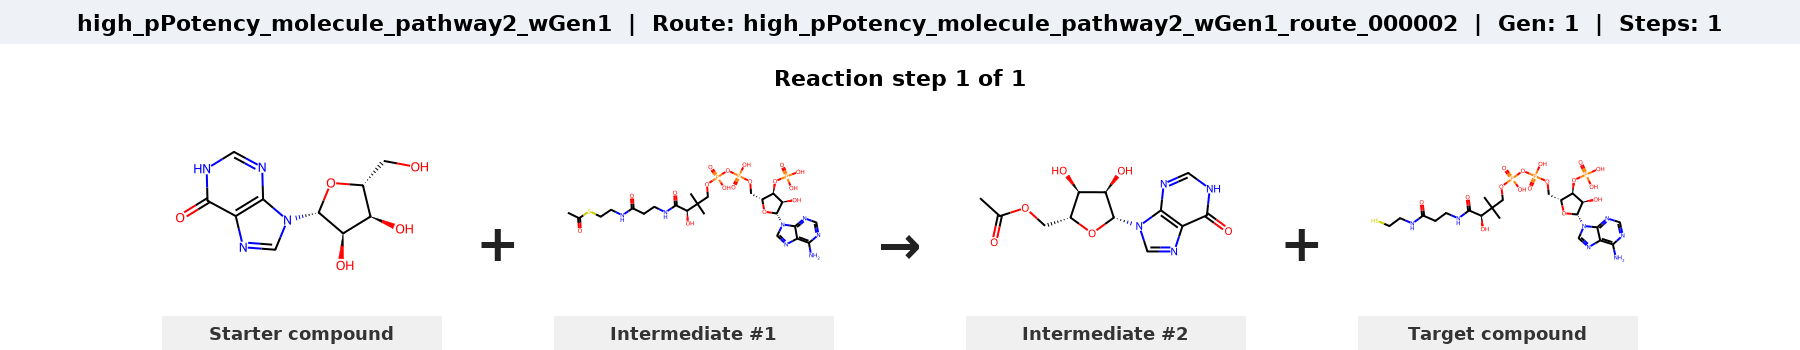

  Saved → /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathways_1step.pdf

2-step pathways: 17 available, saving 10


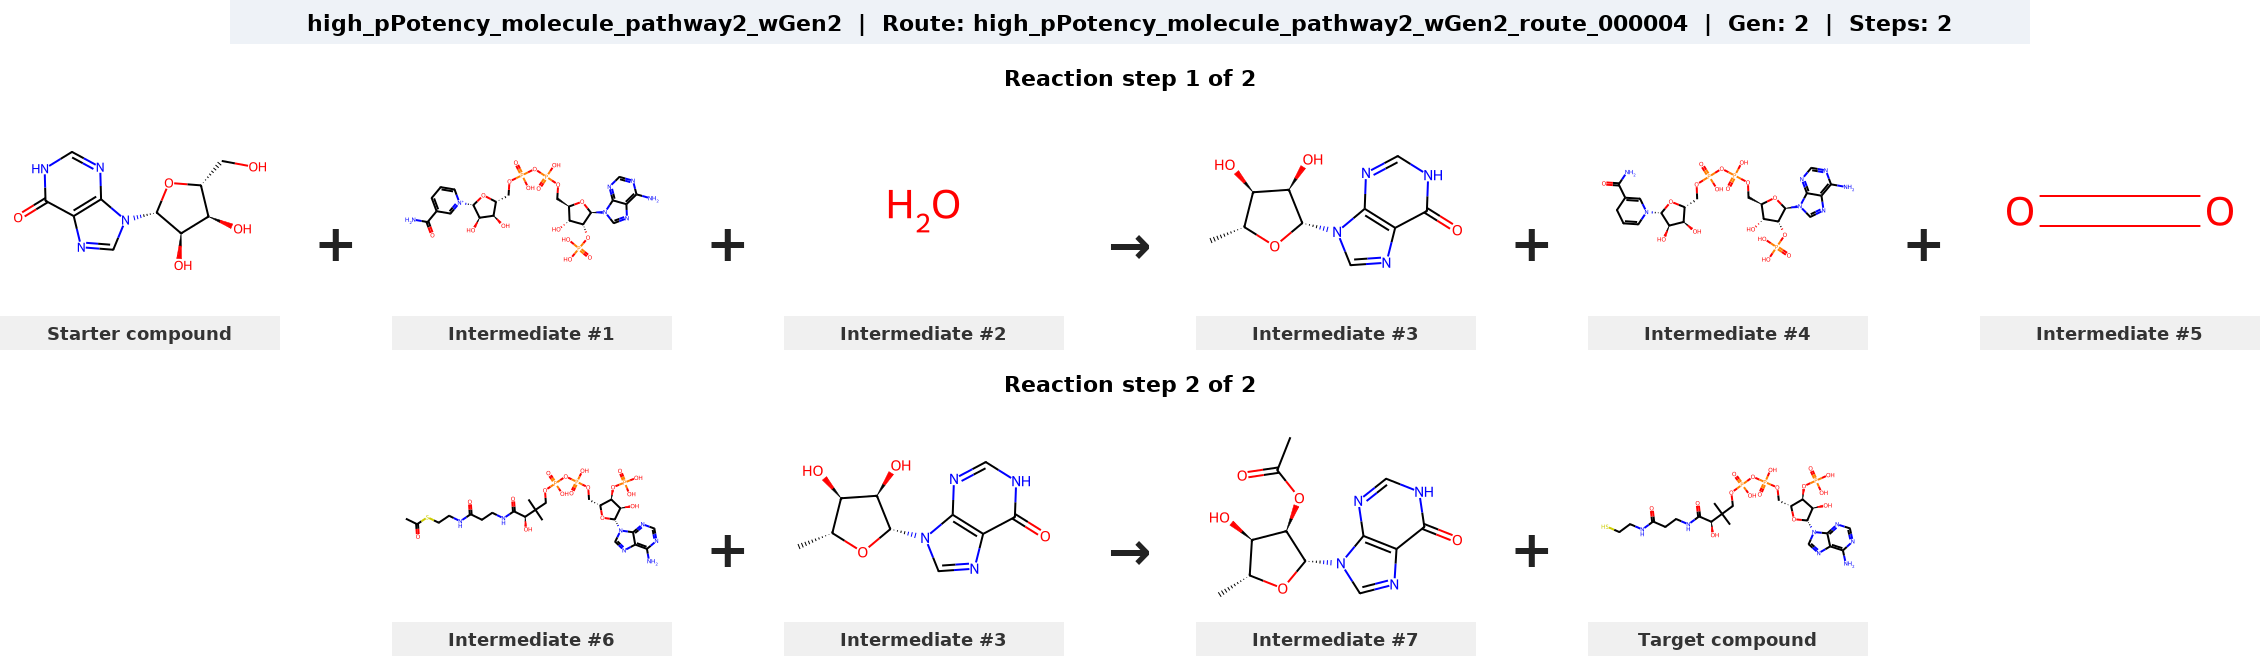

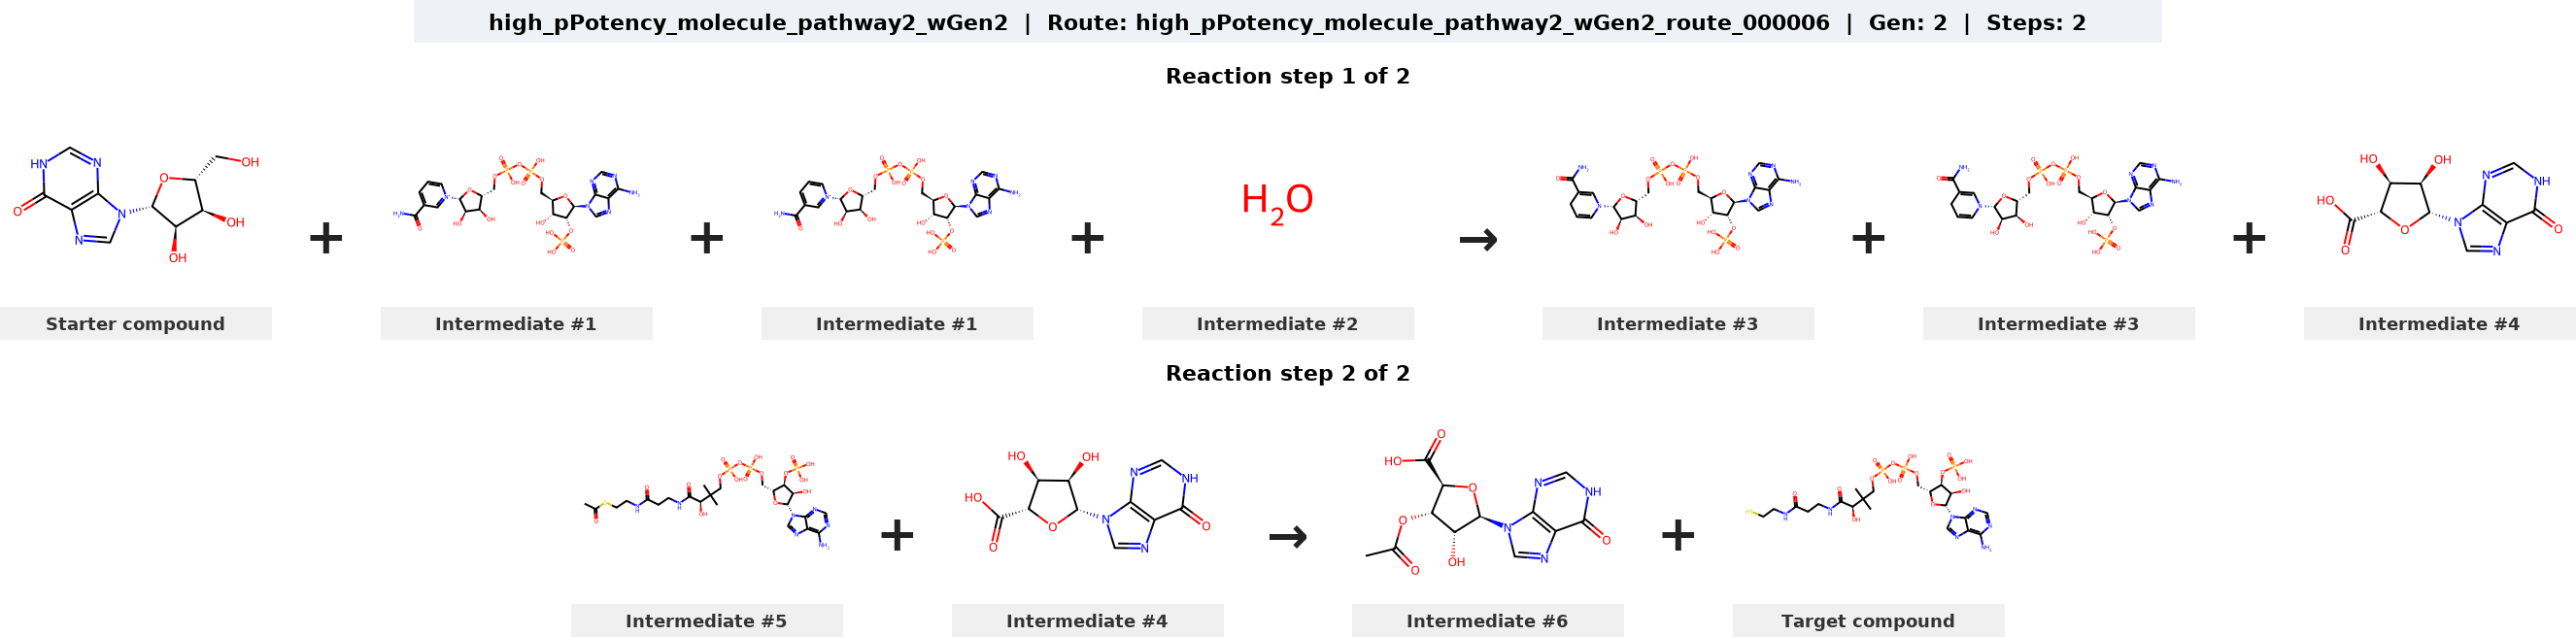

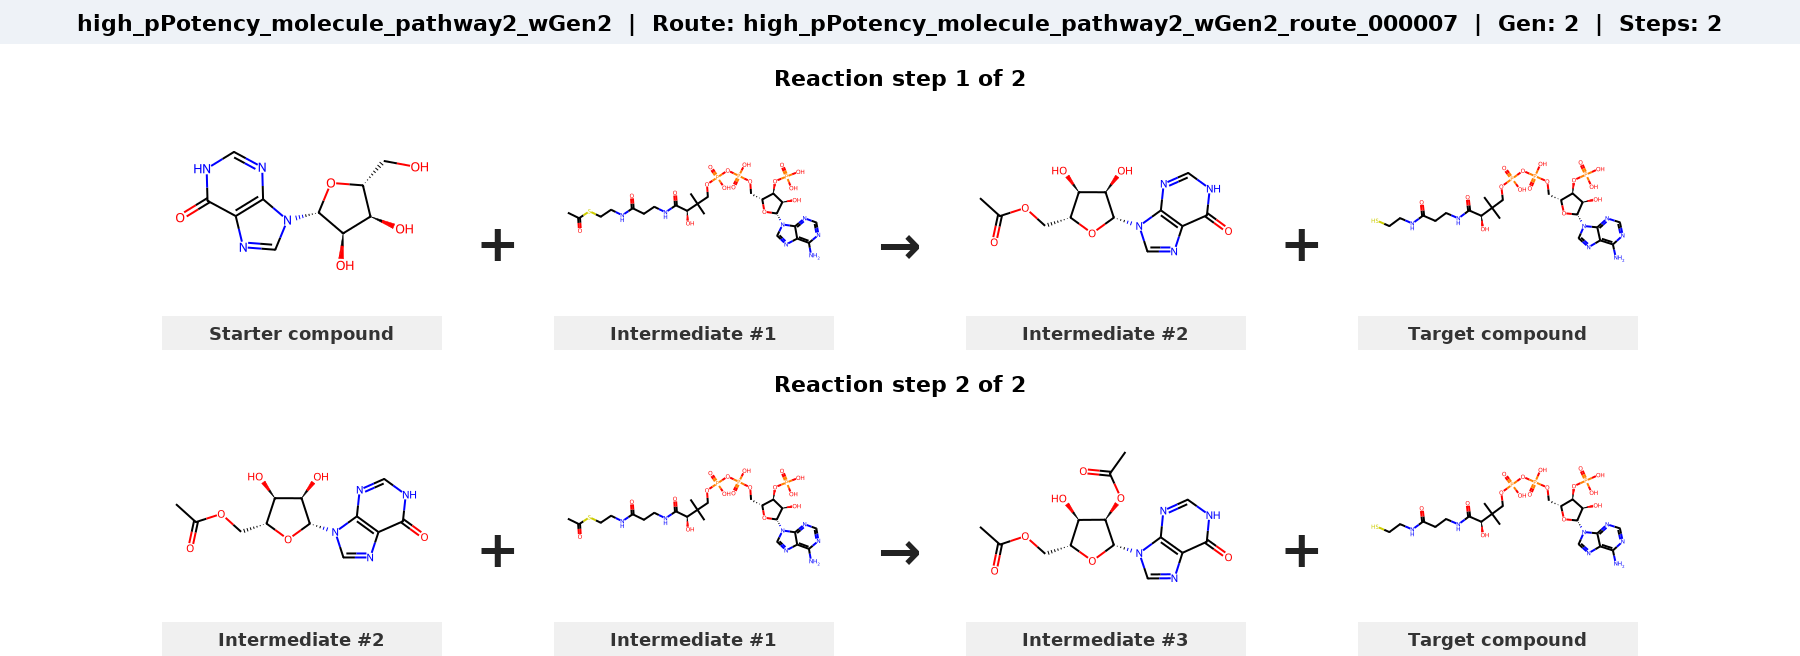

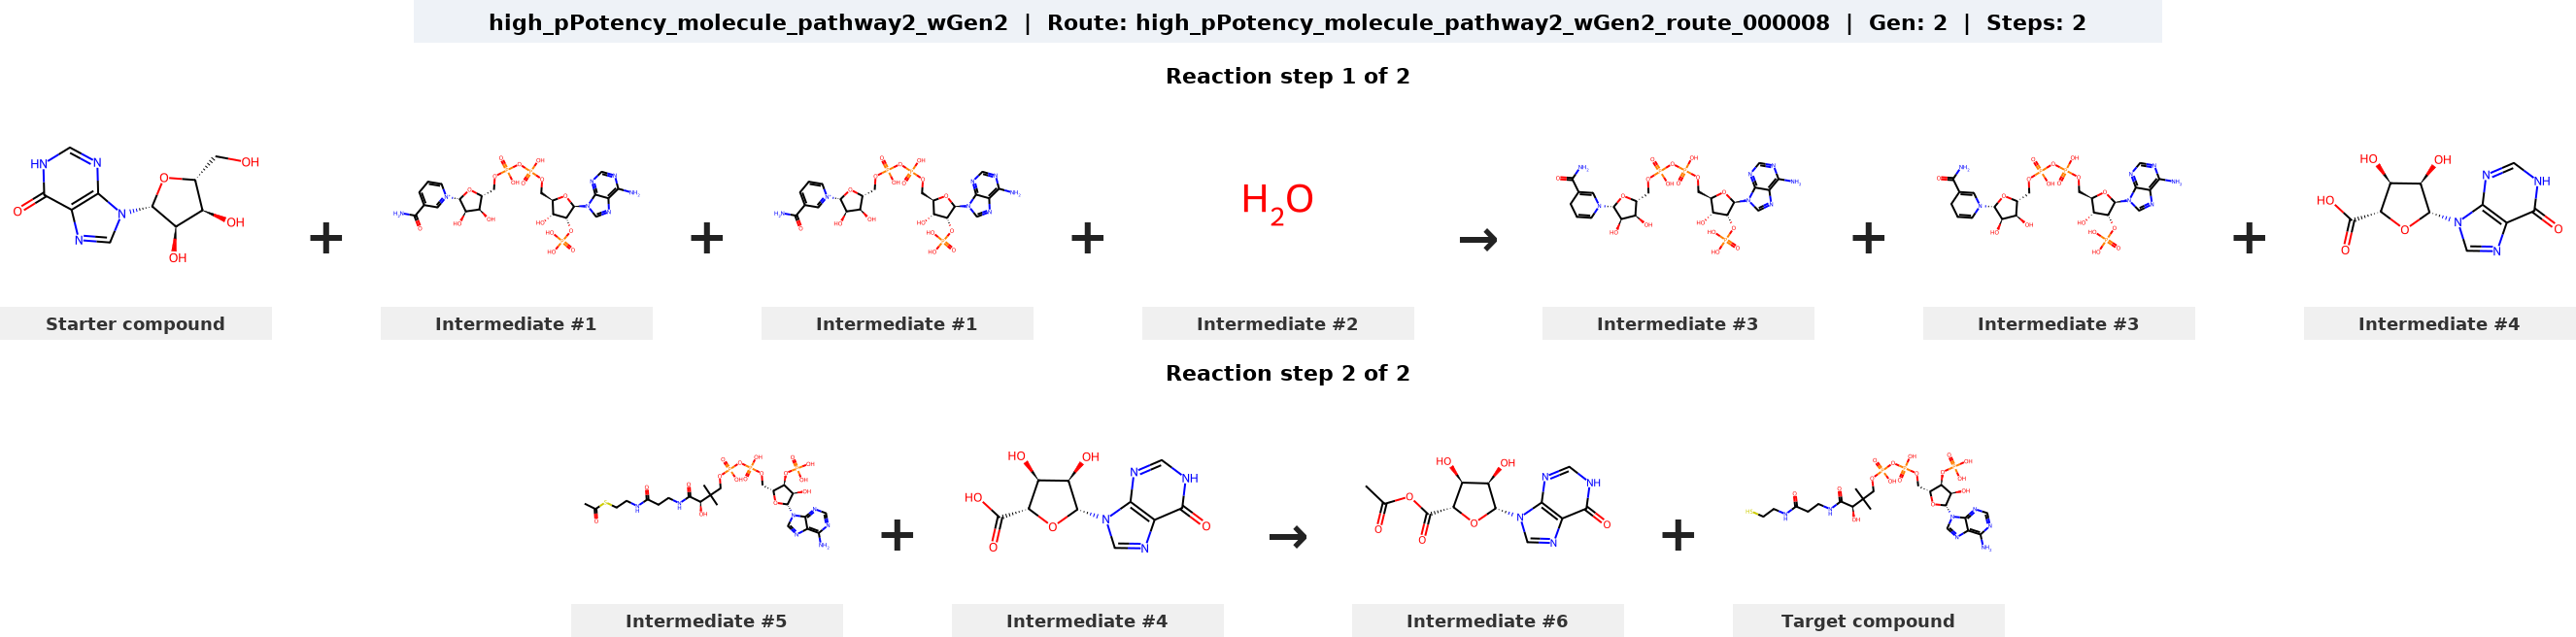

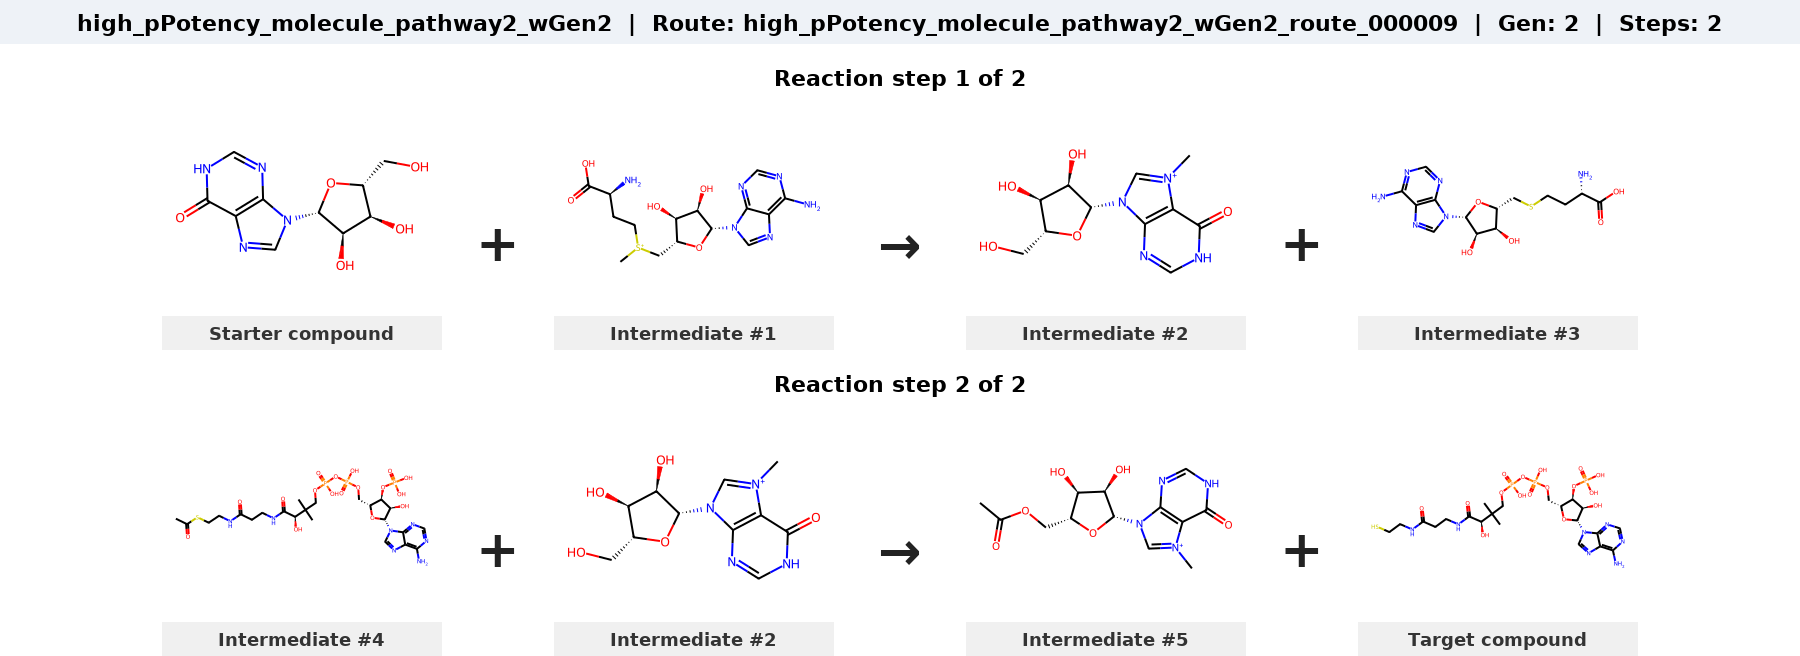

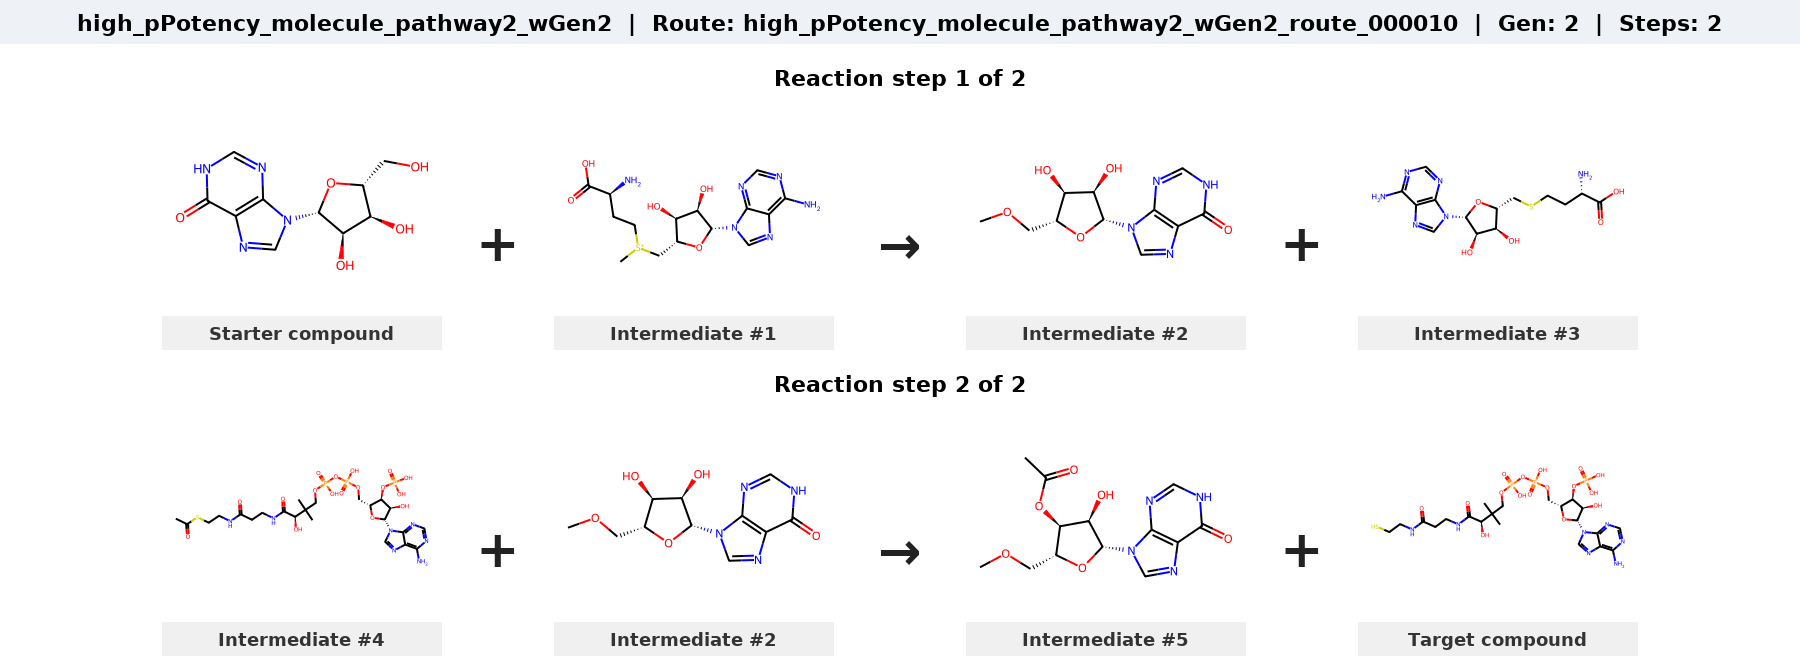

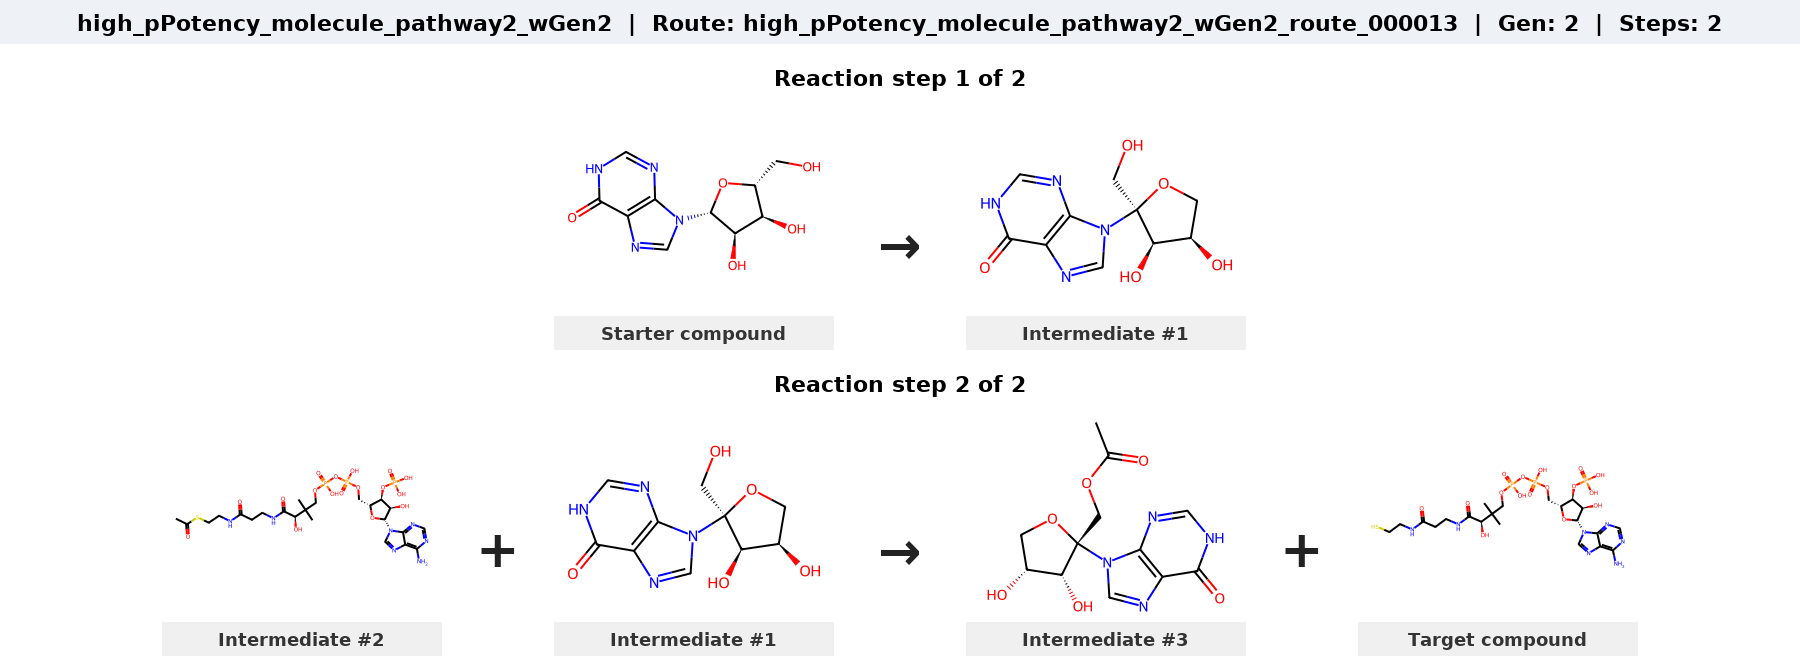

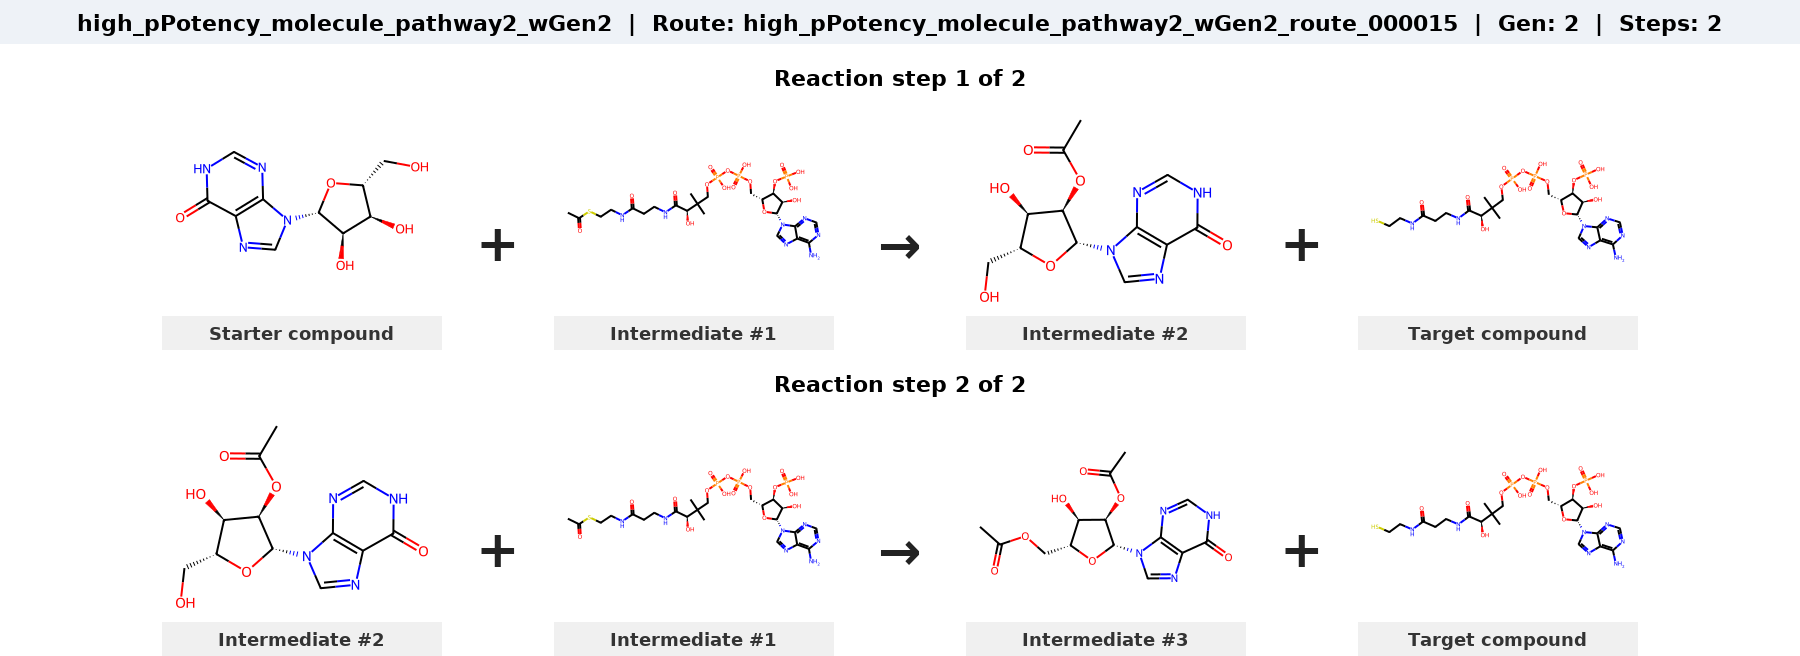

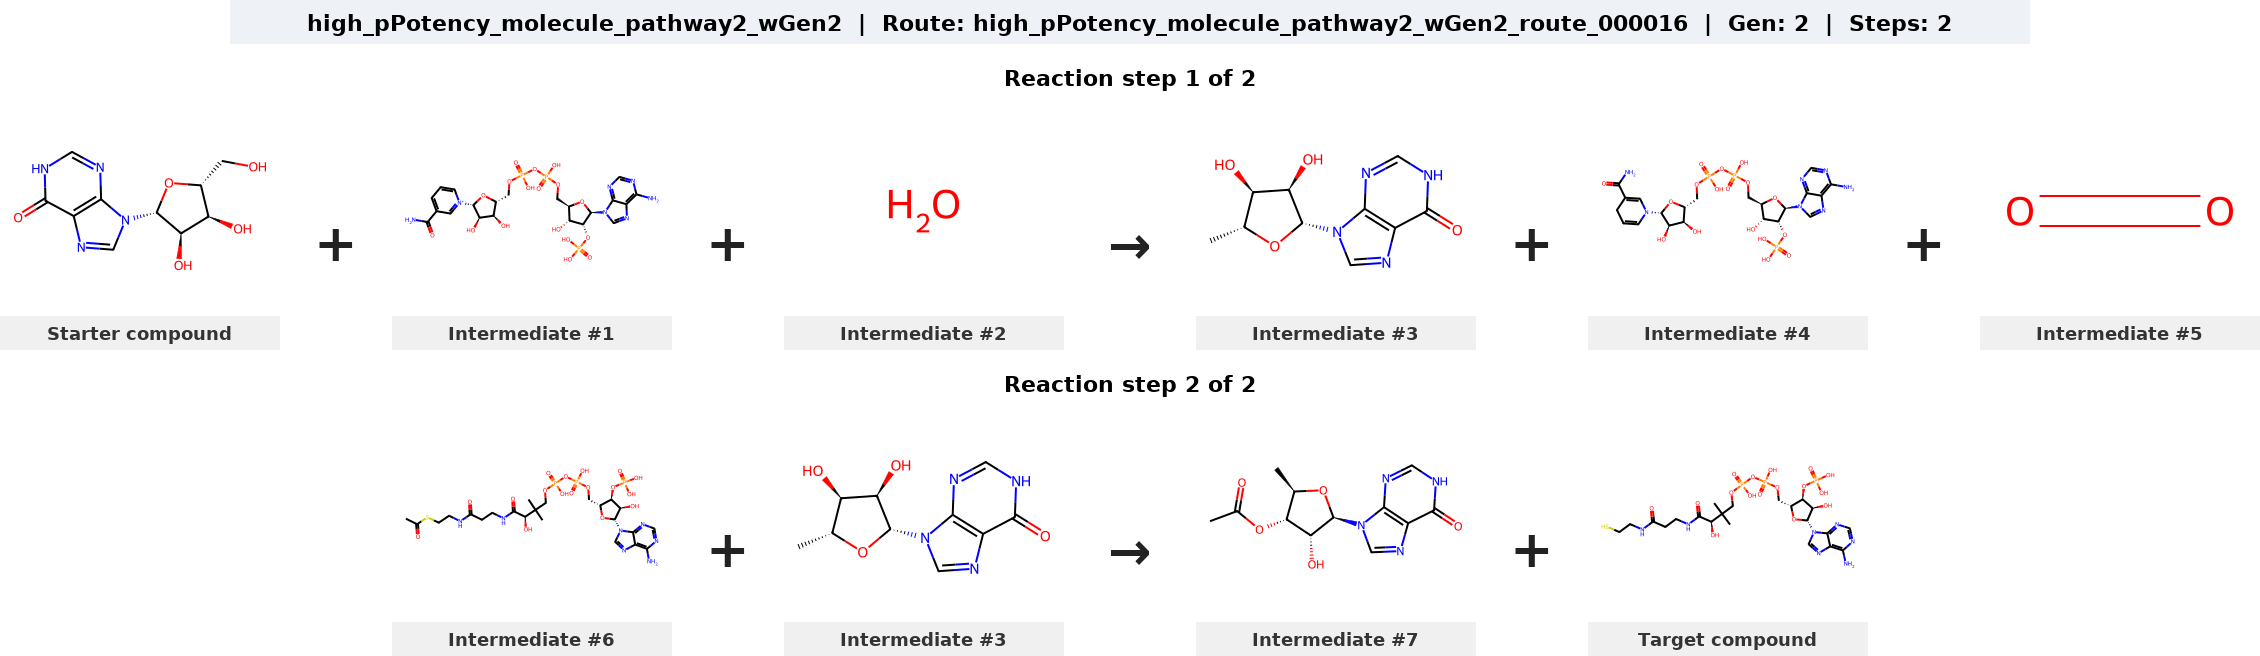

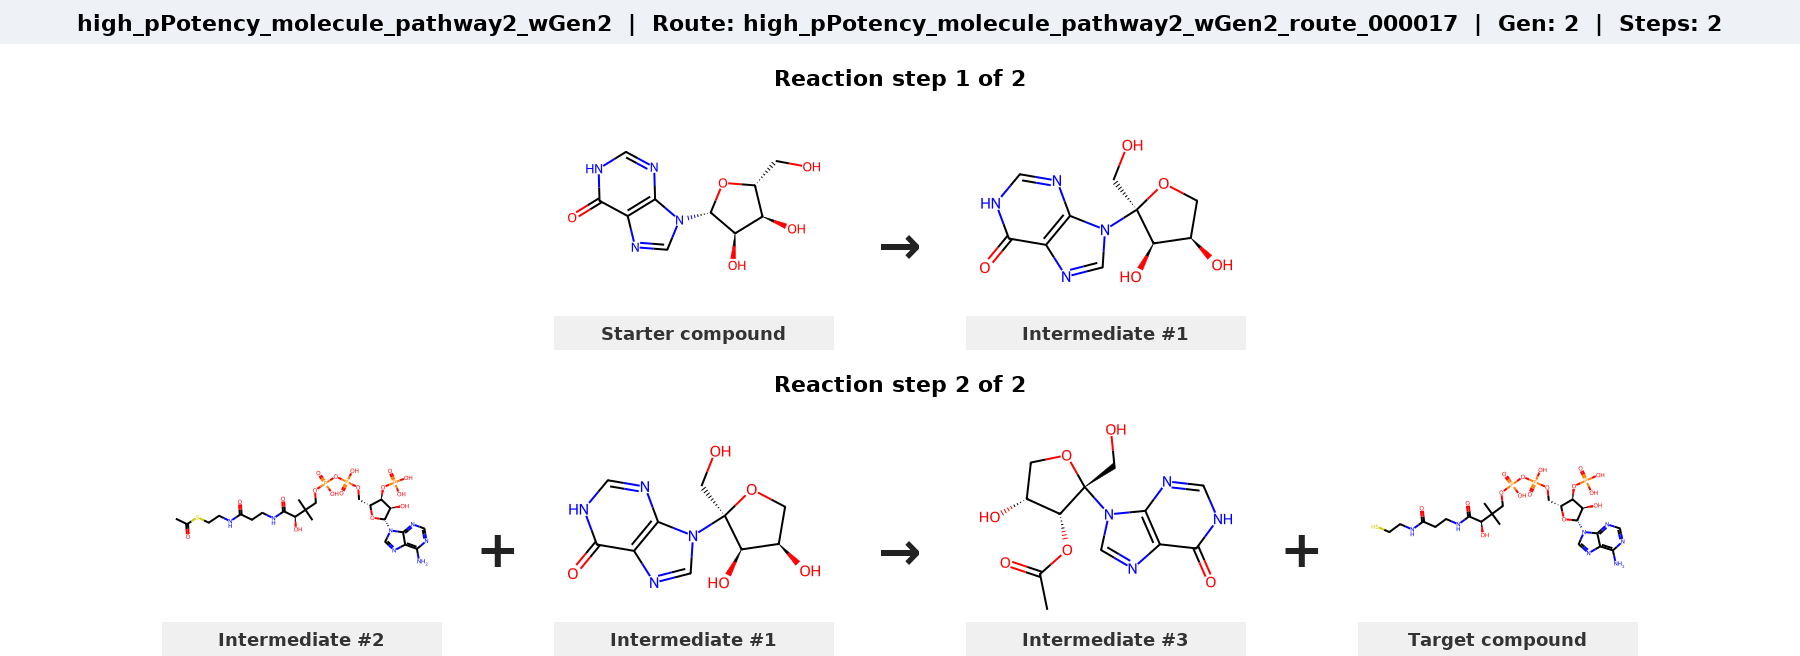

  Saved → /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathways_2step.pdf

3-step pathways: 437 available, saving 10


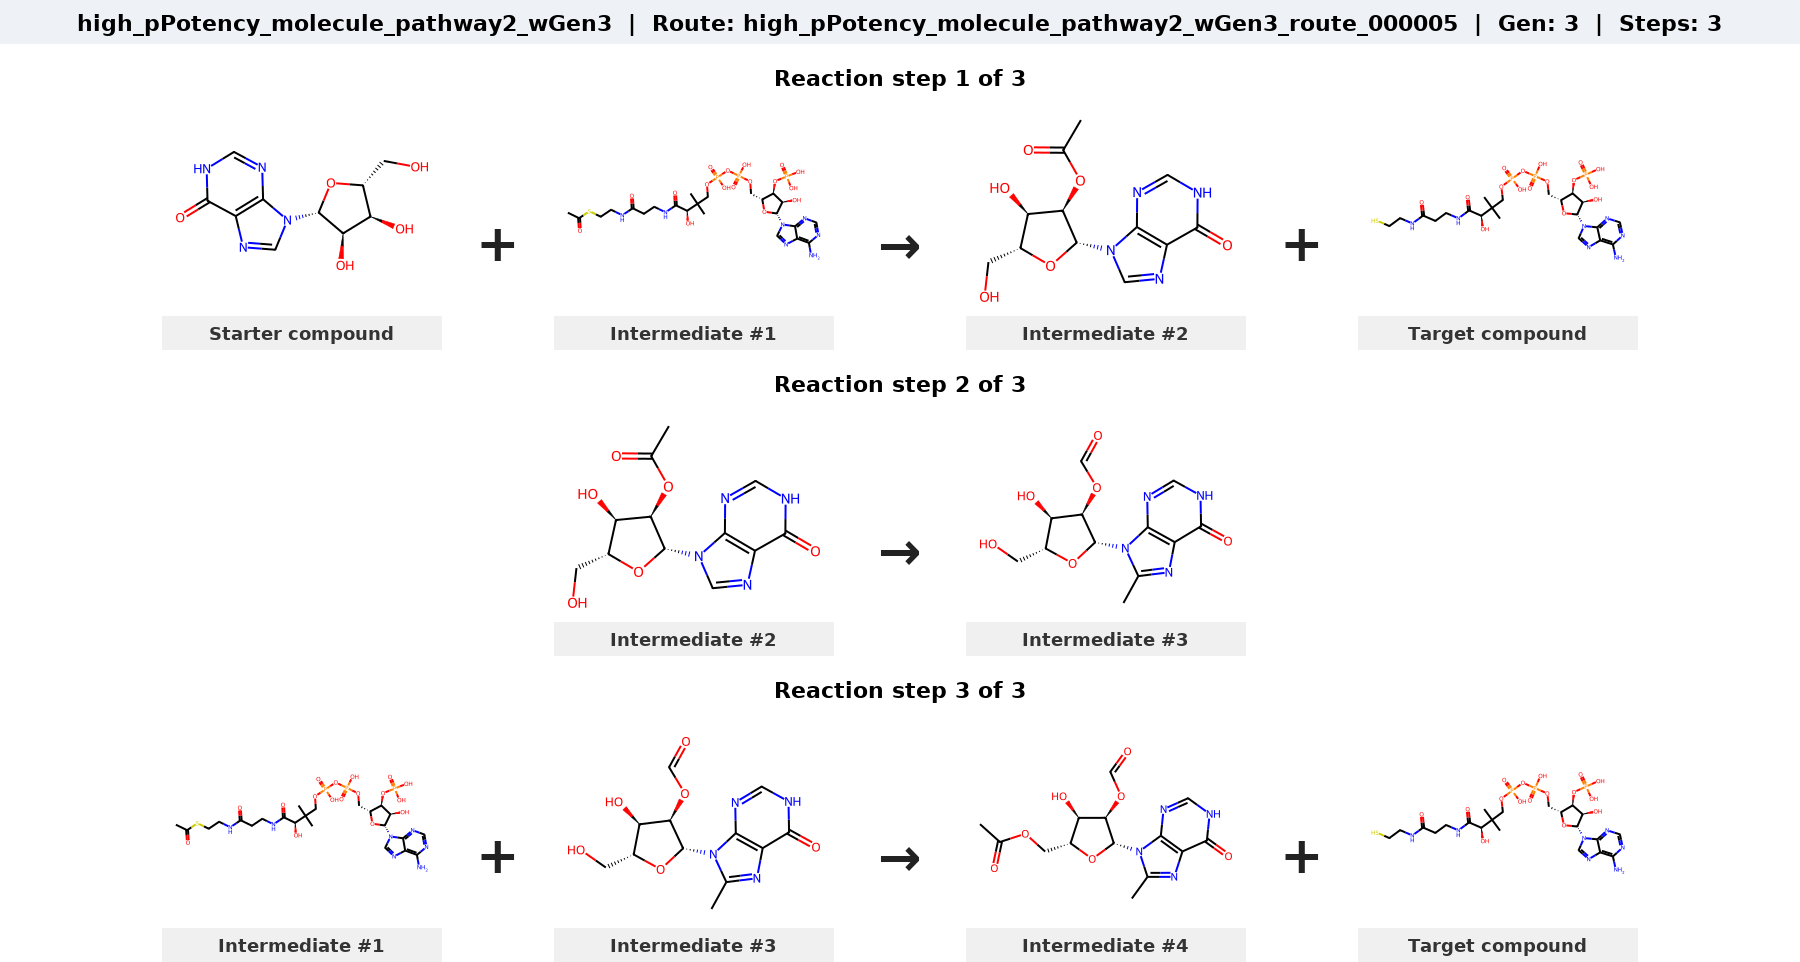

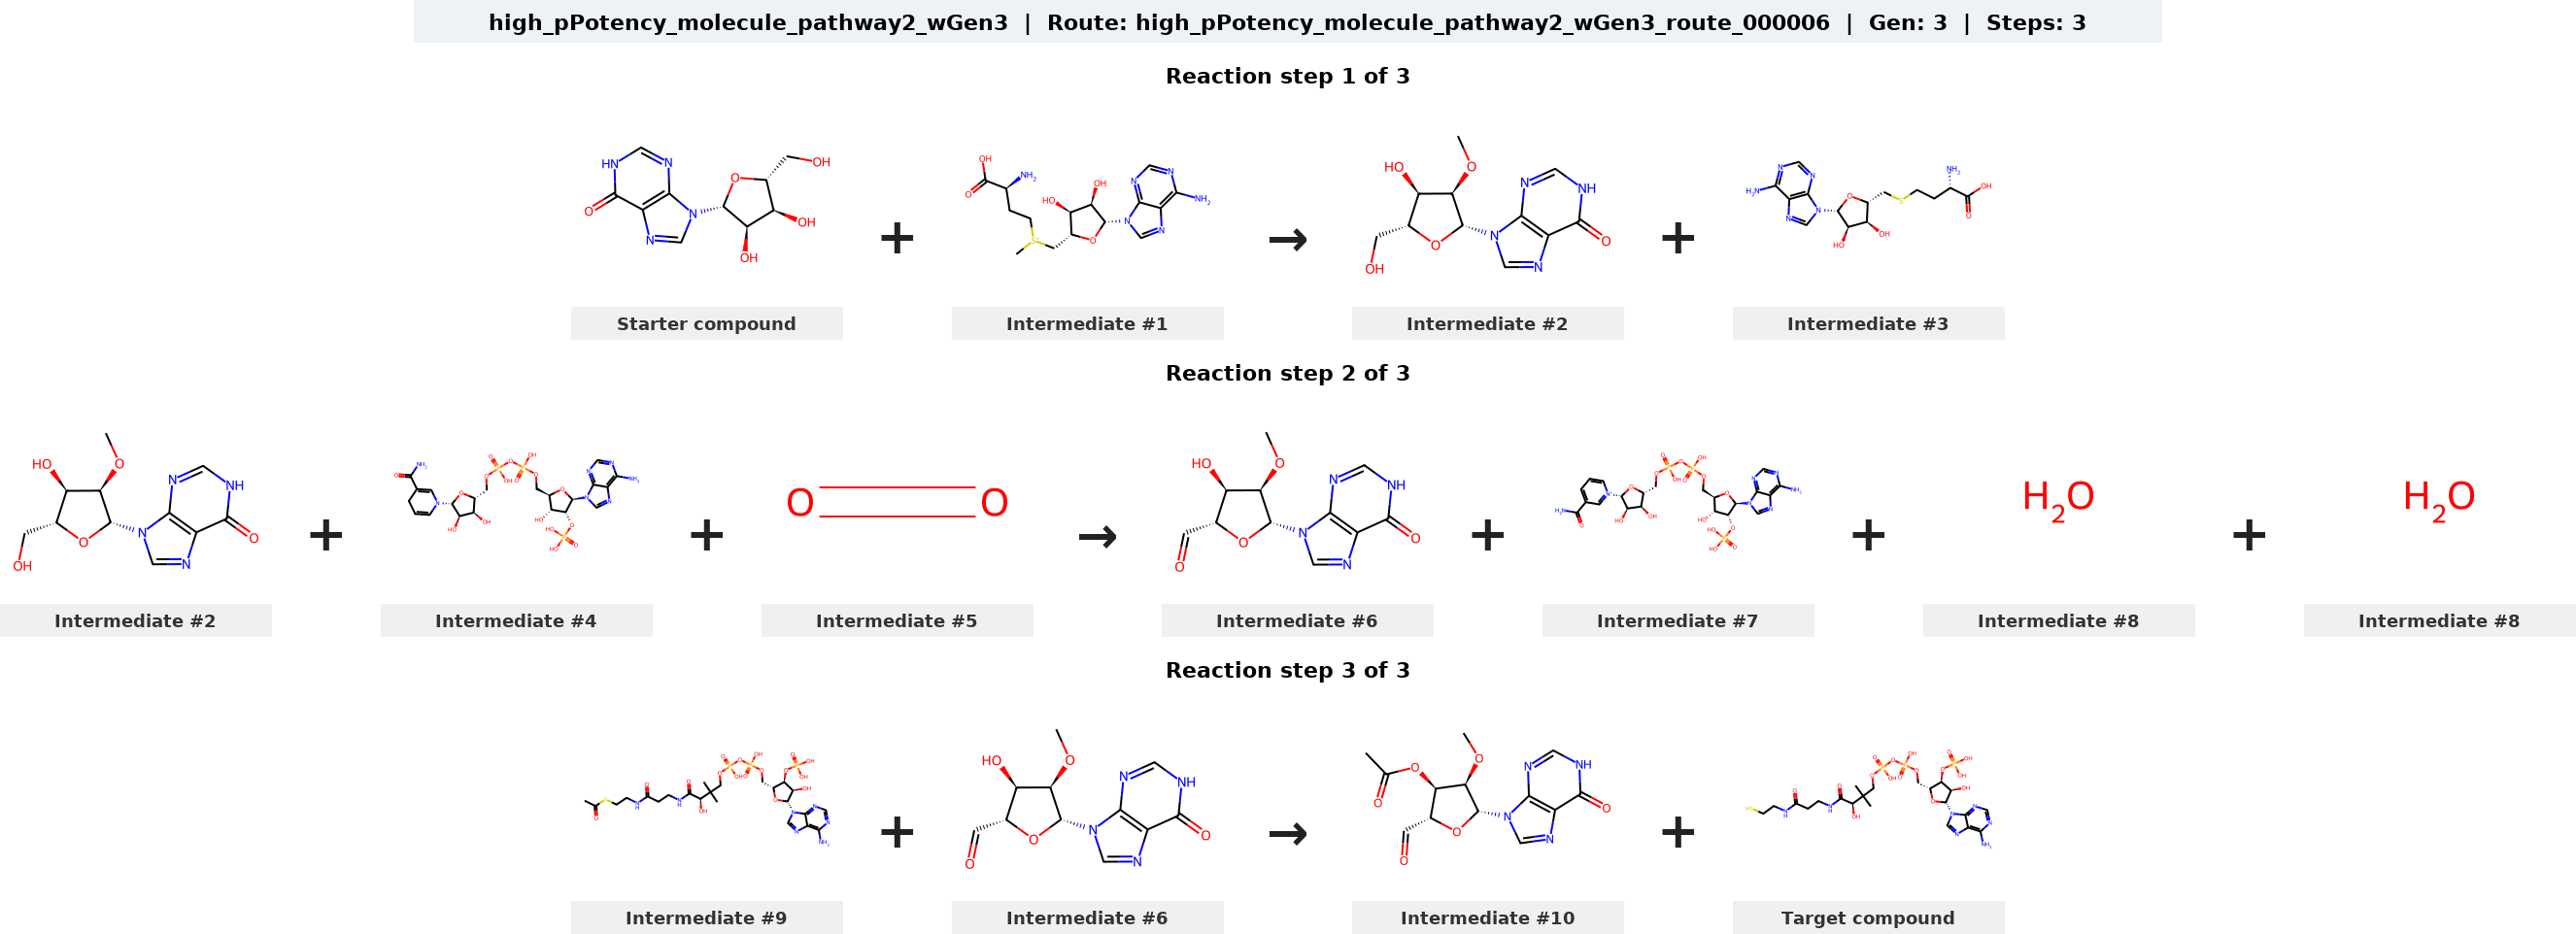

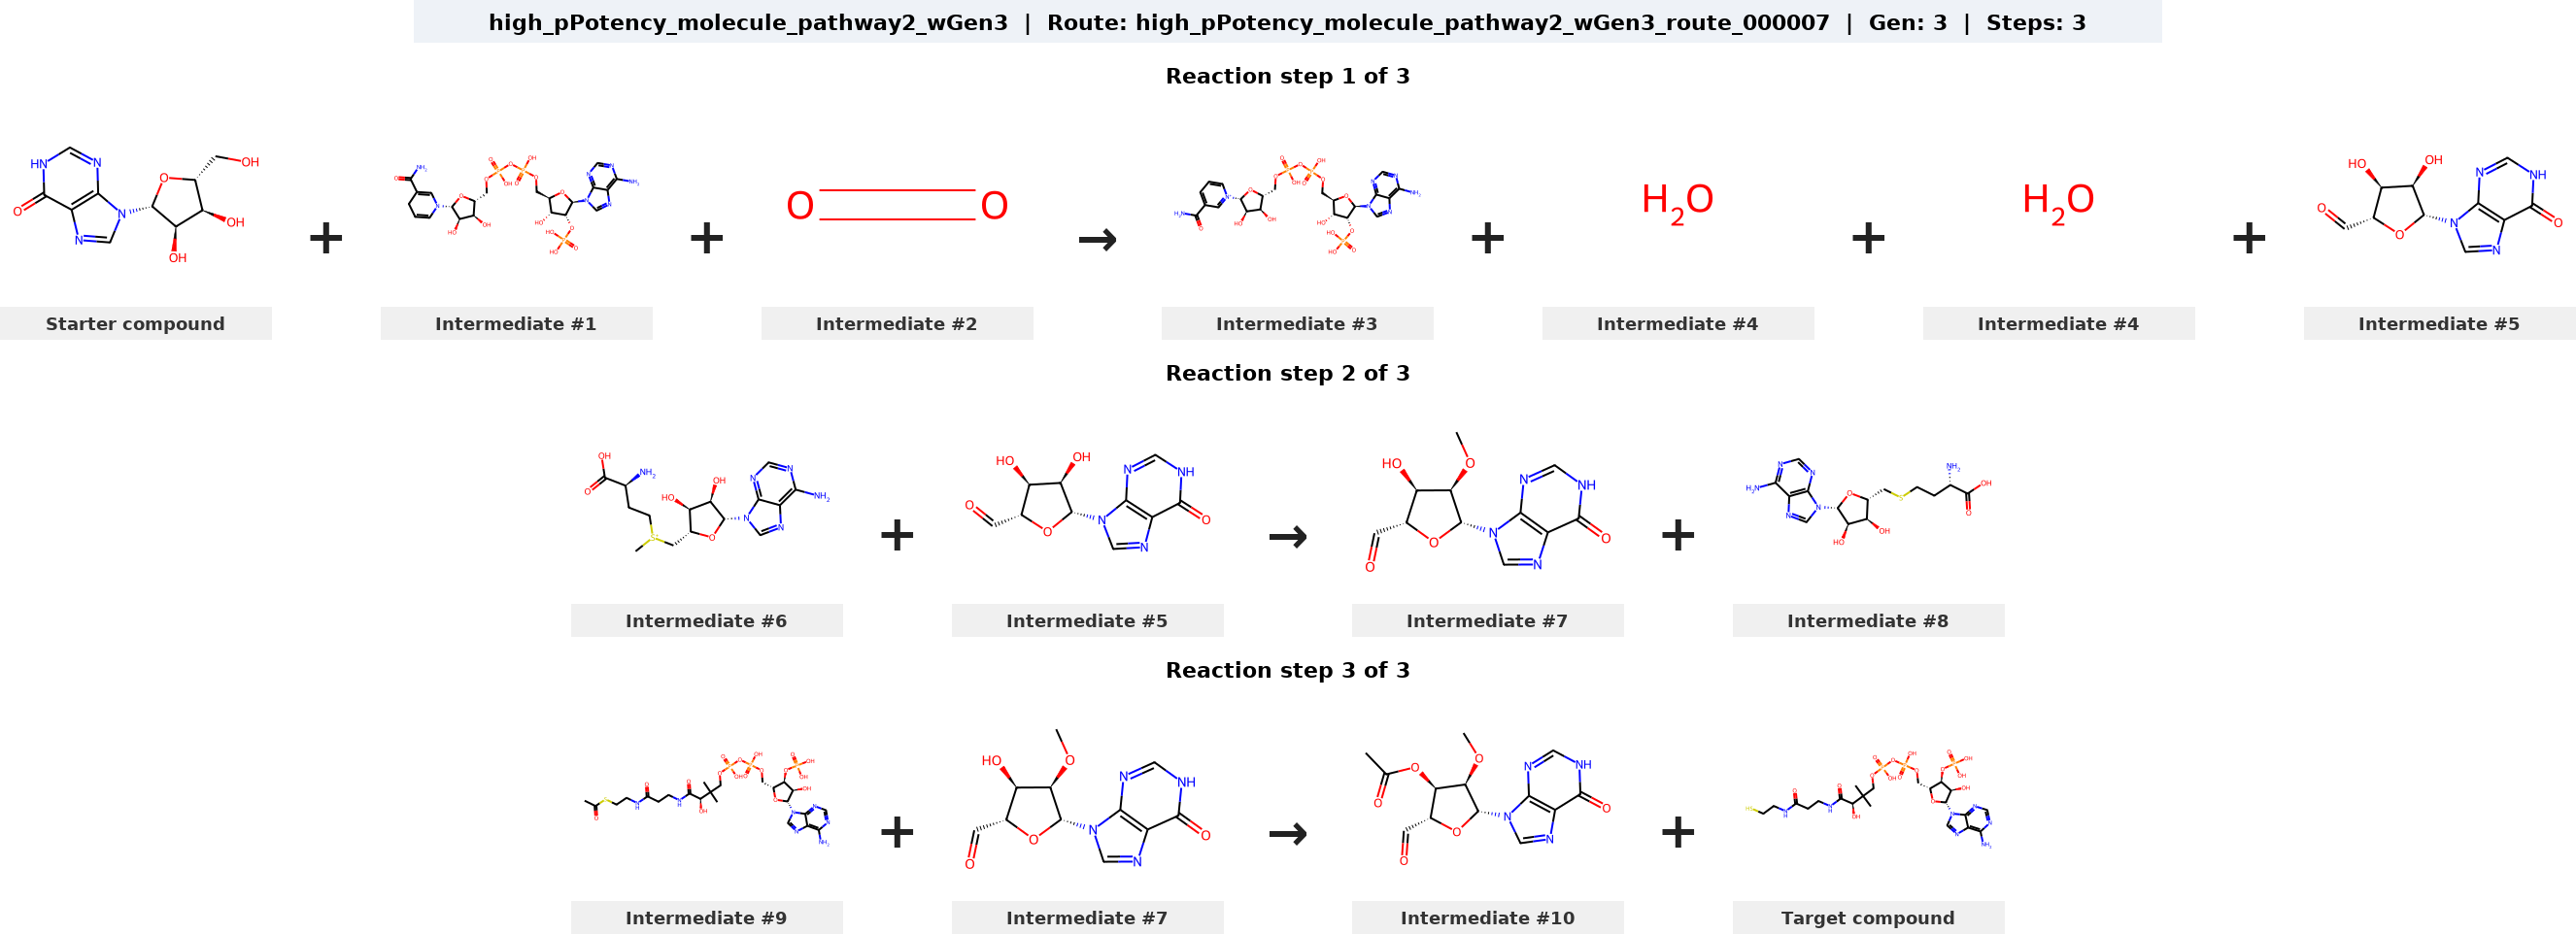

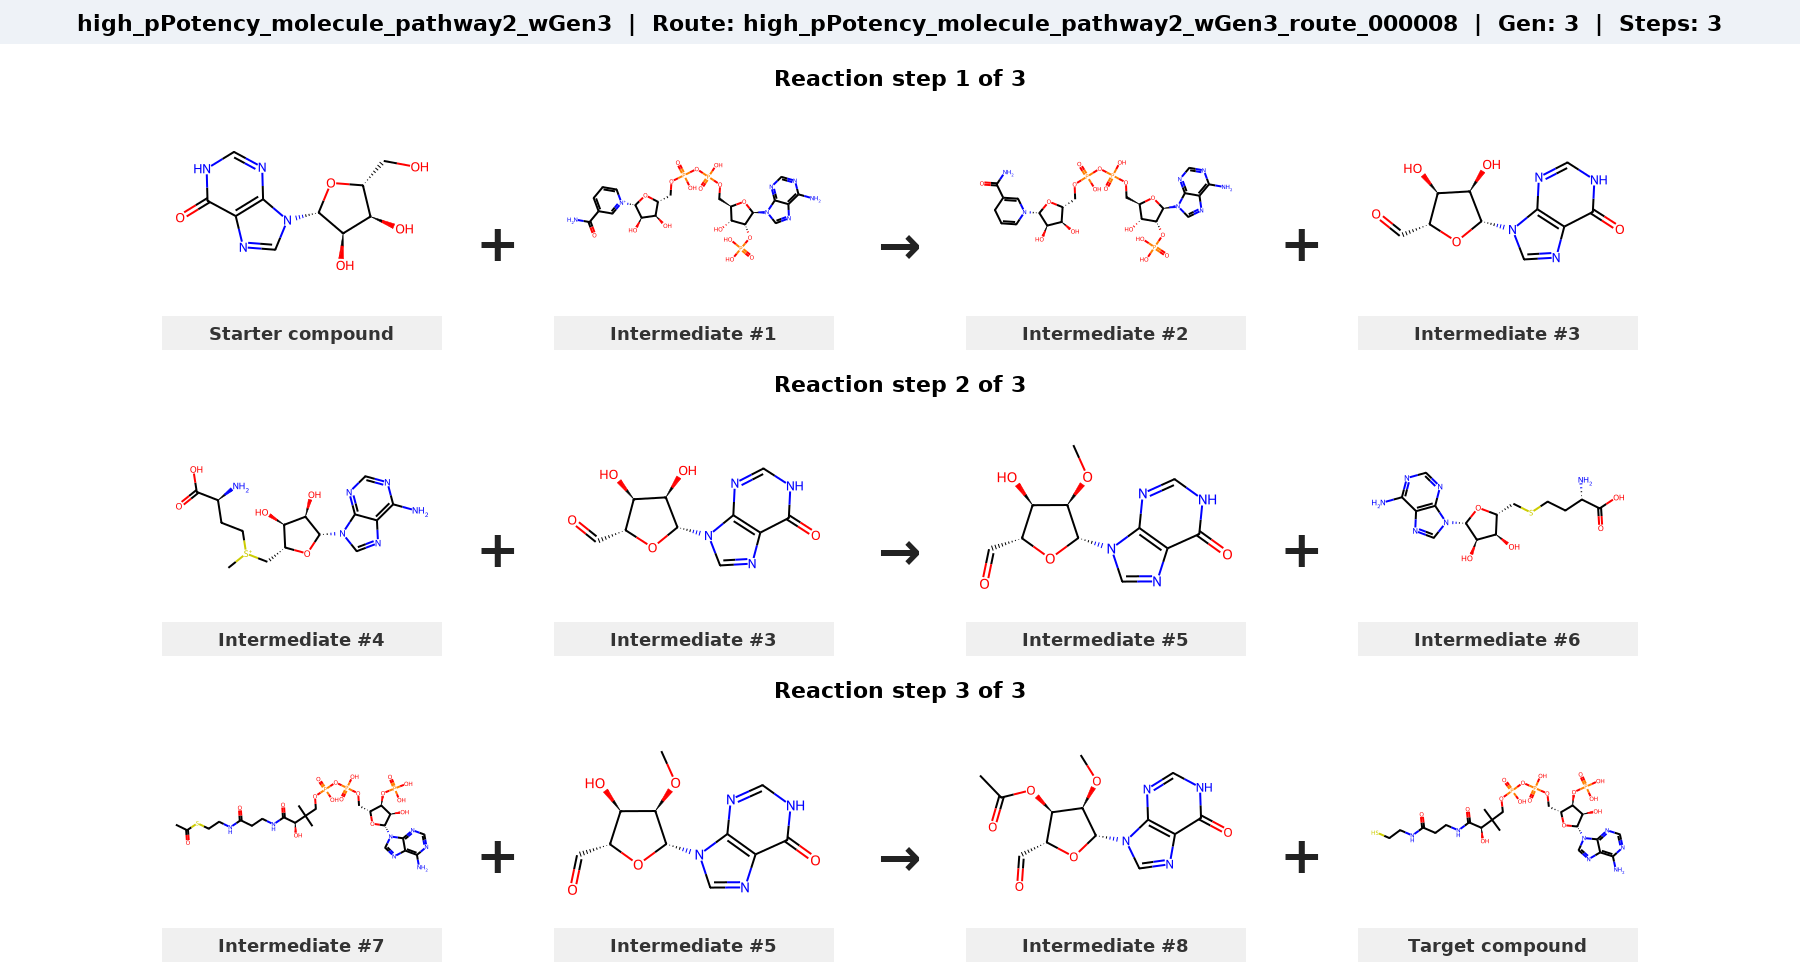

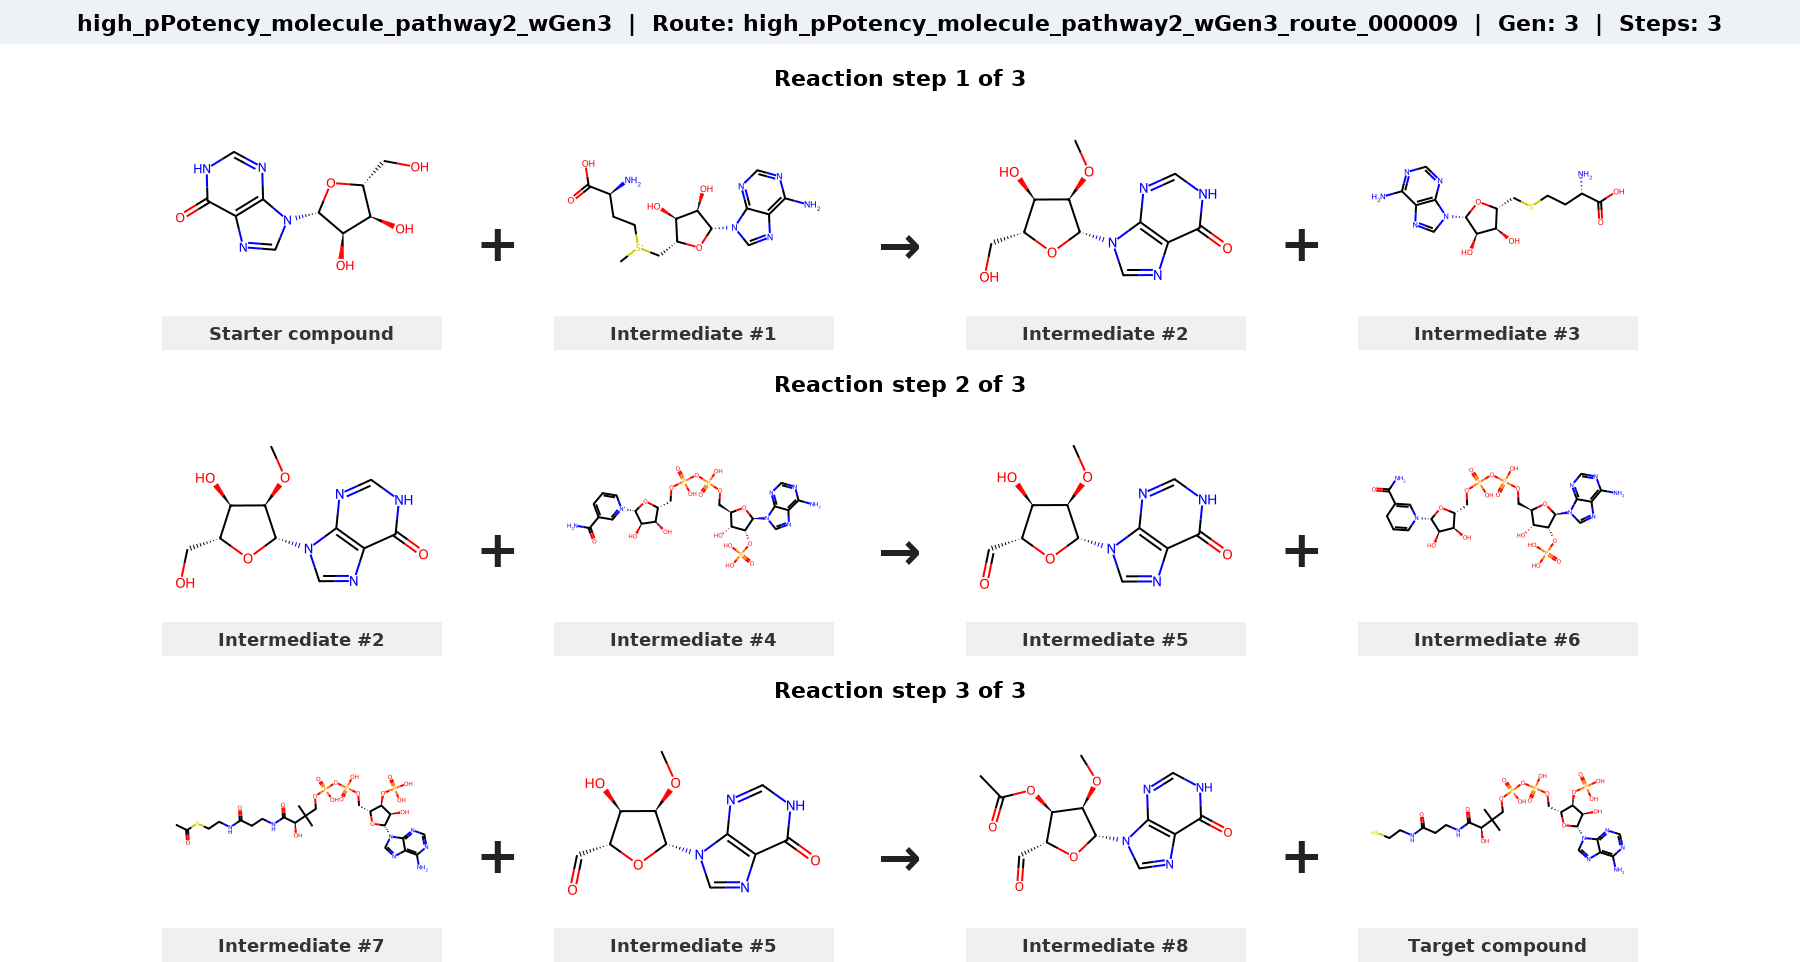

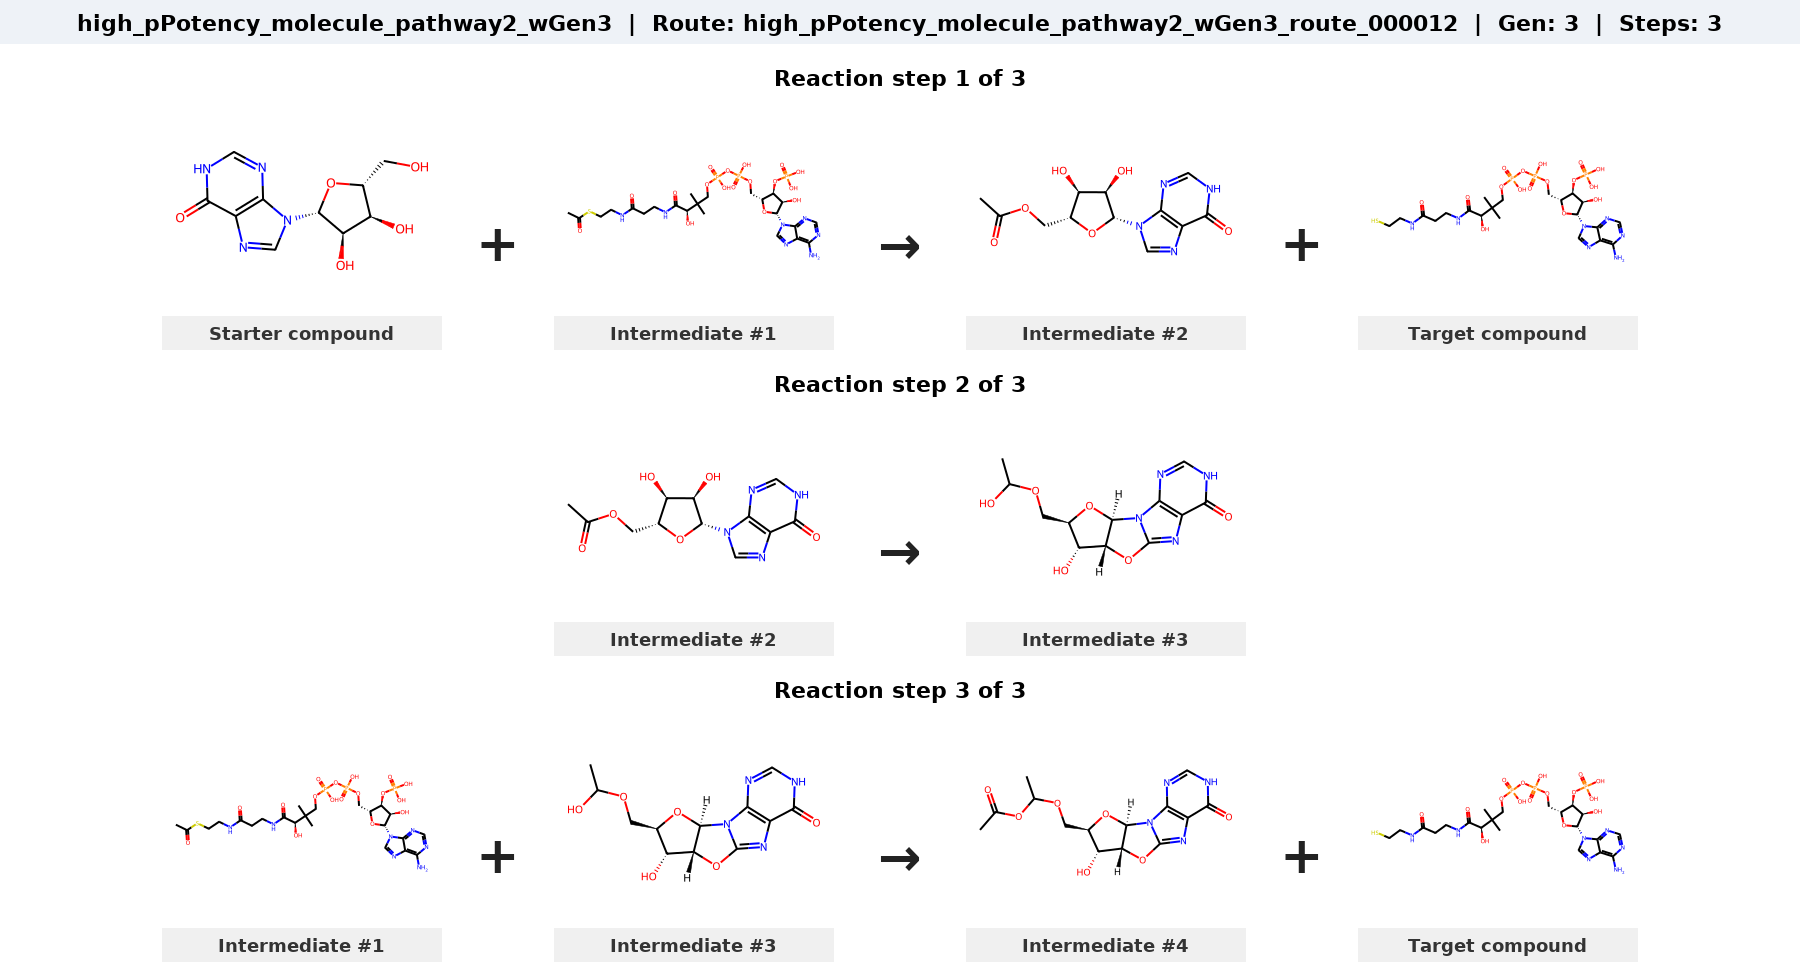

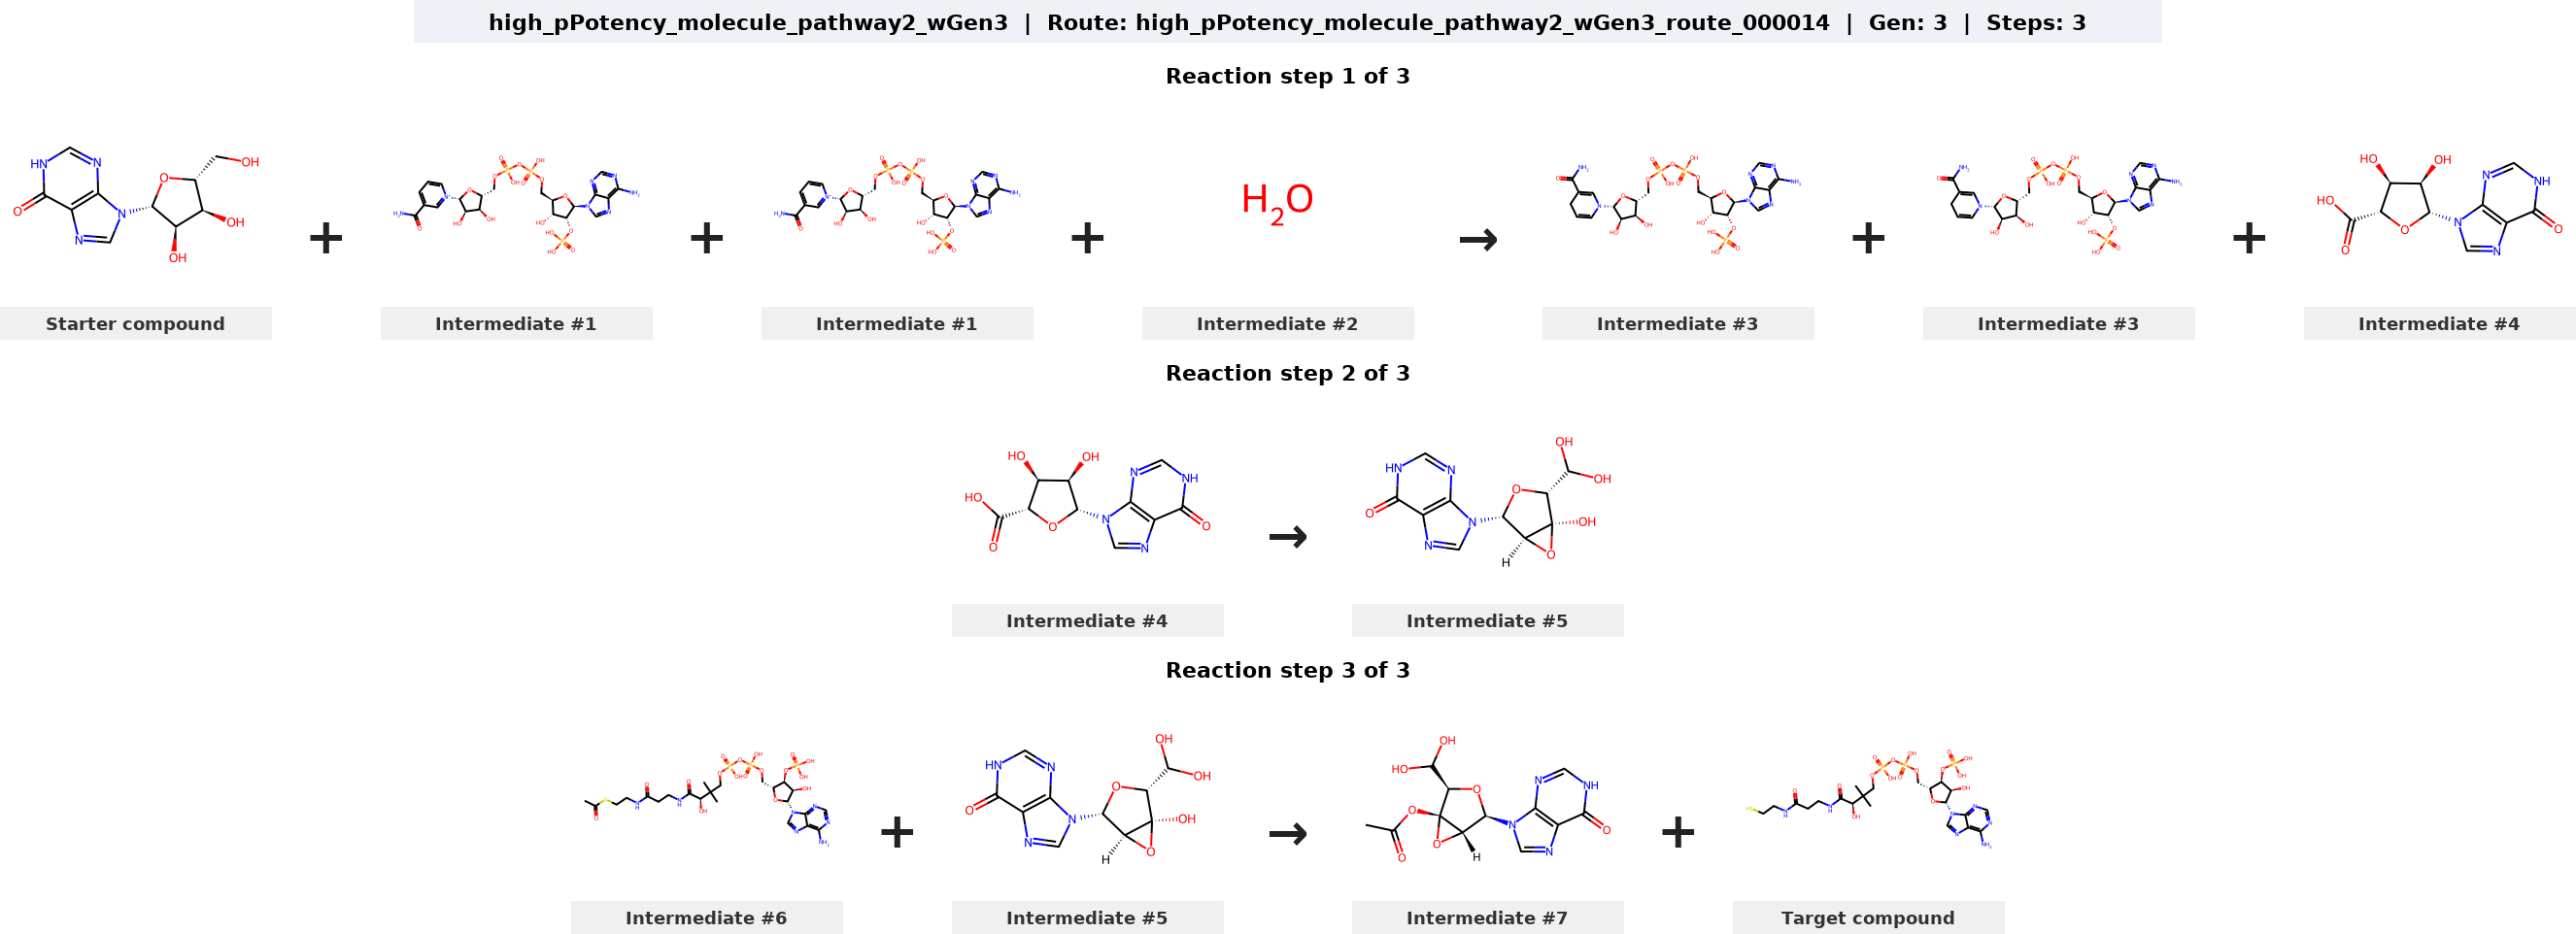

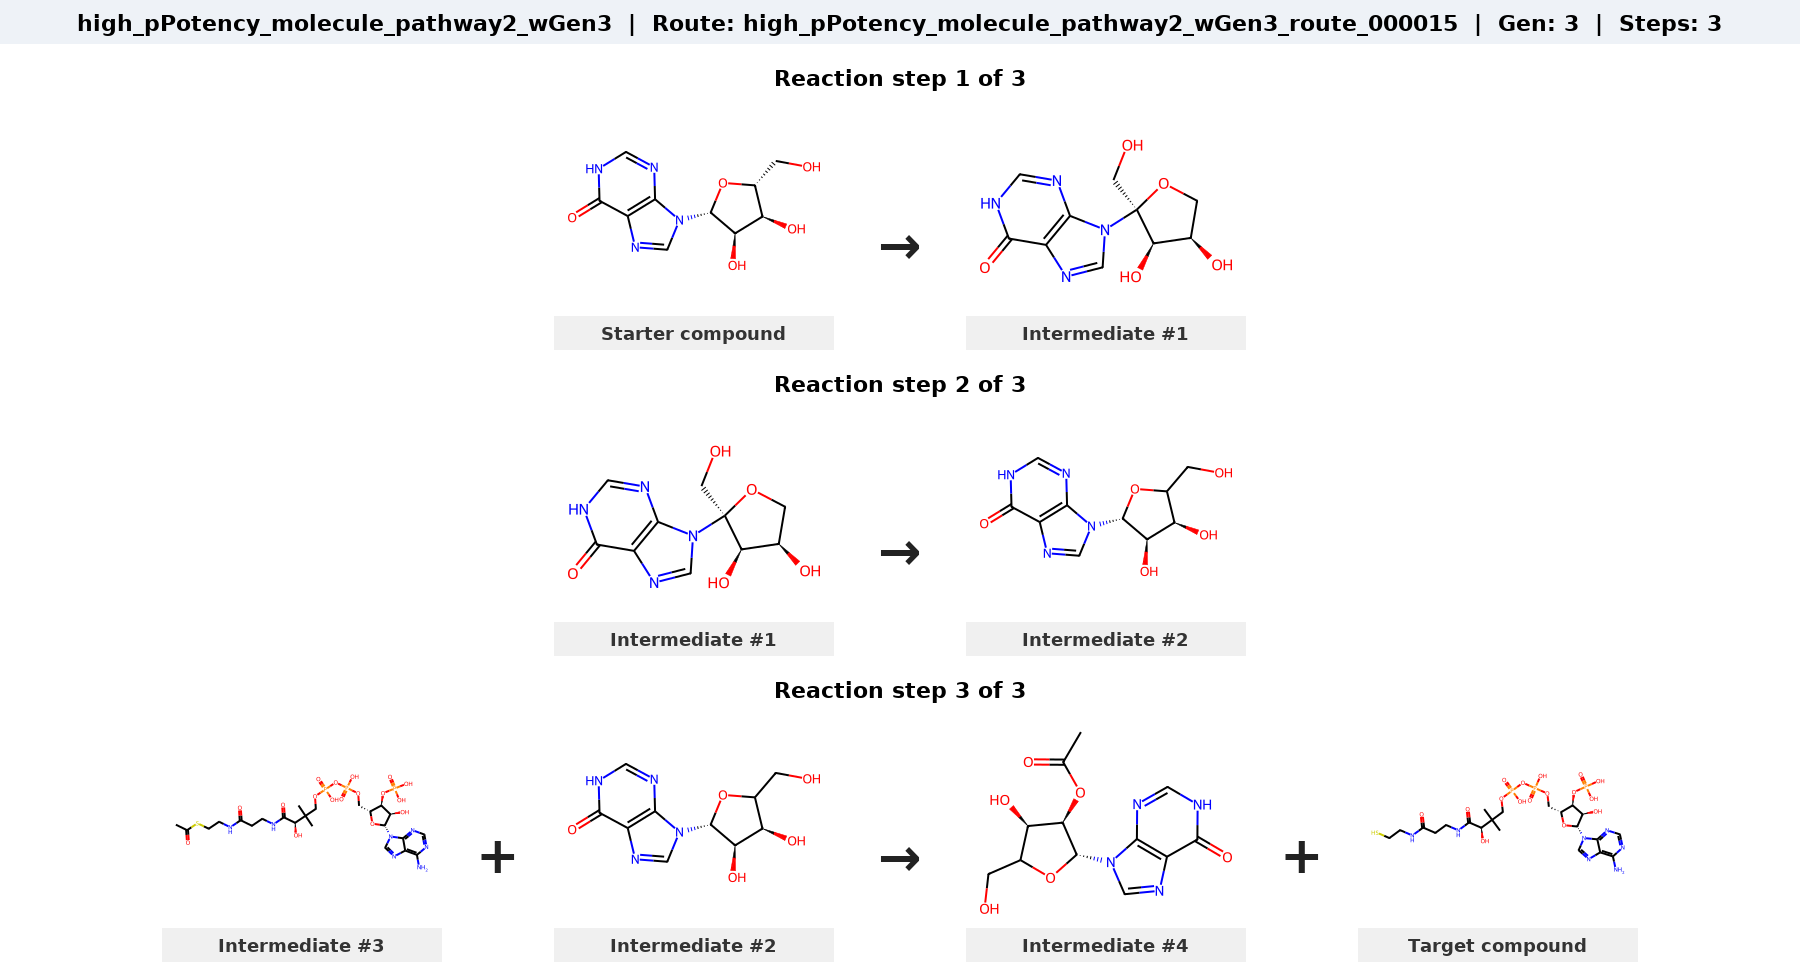

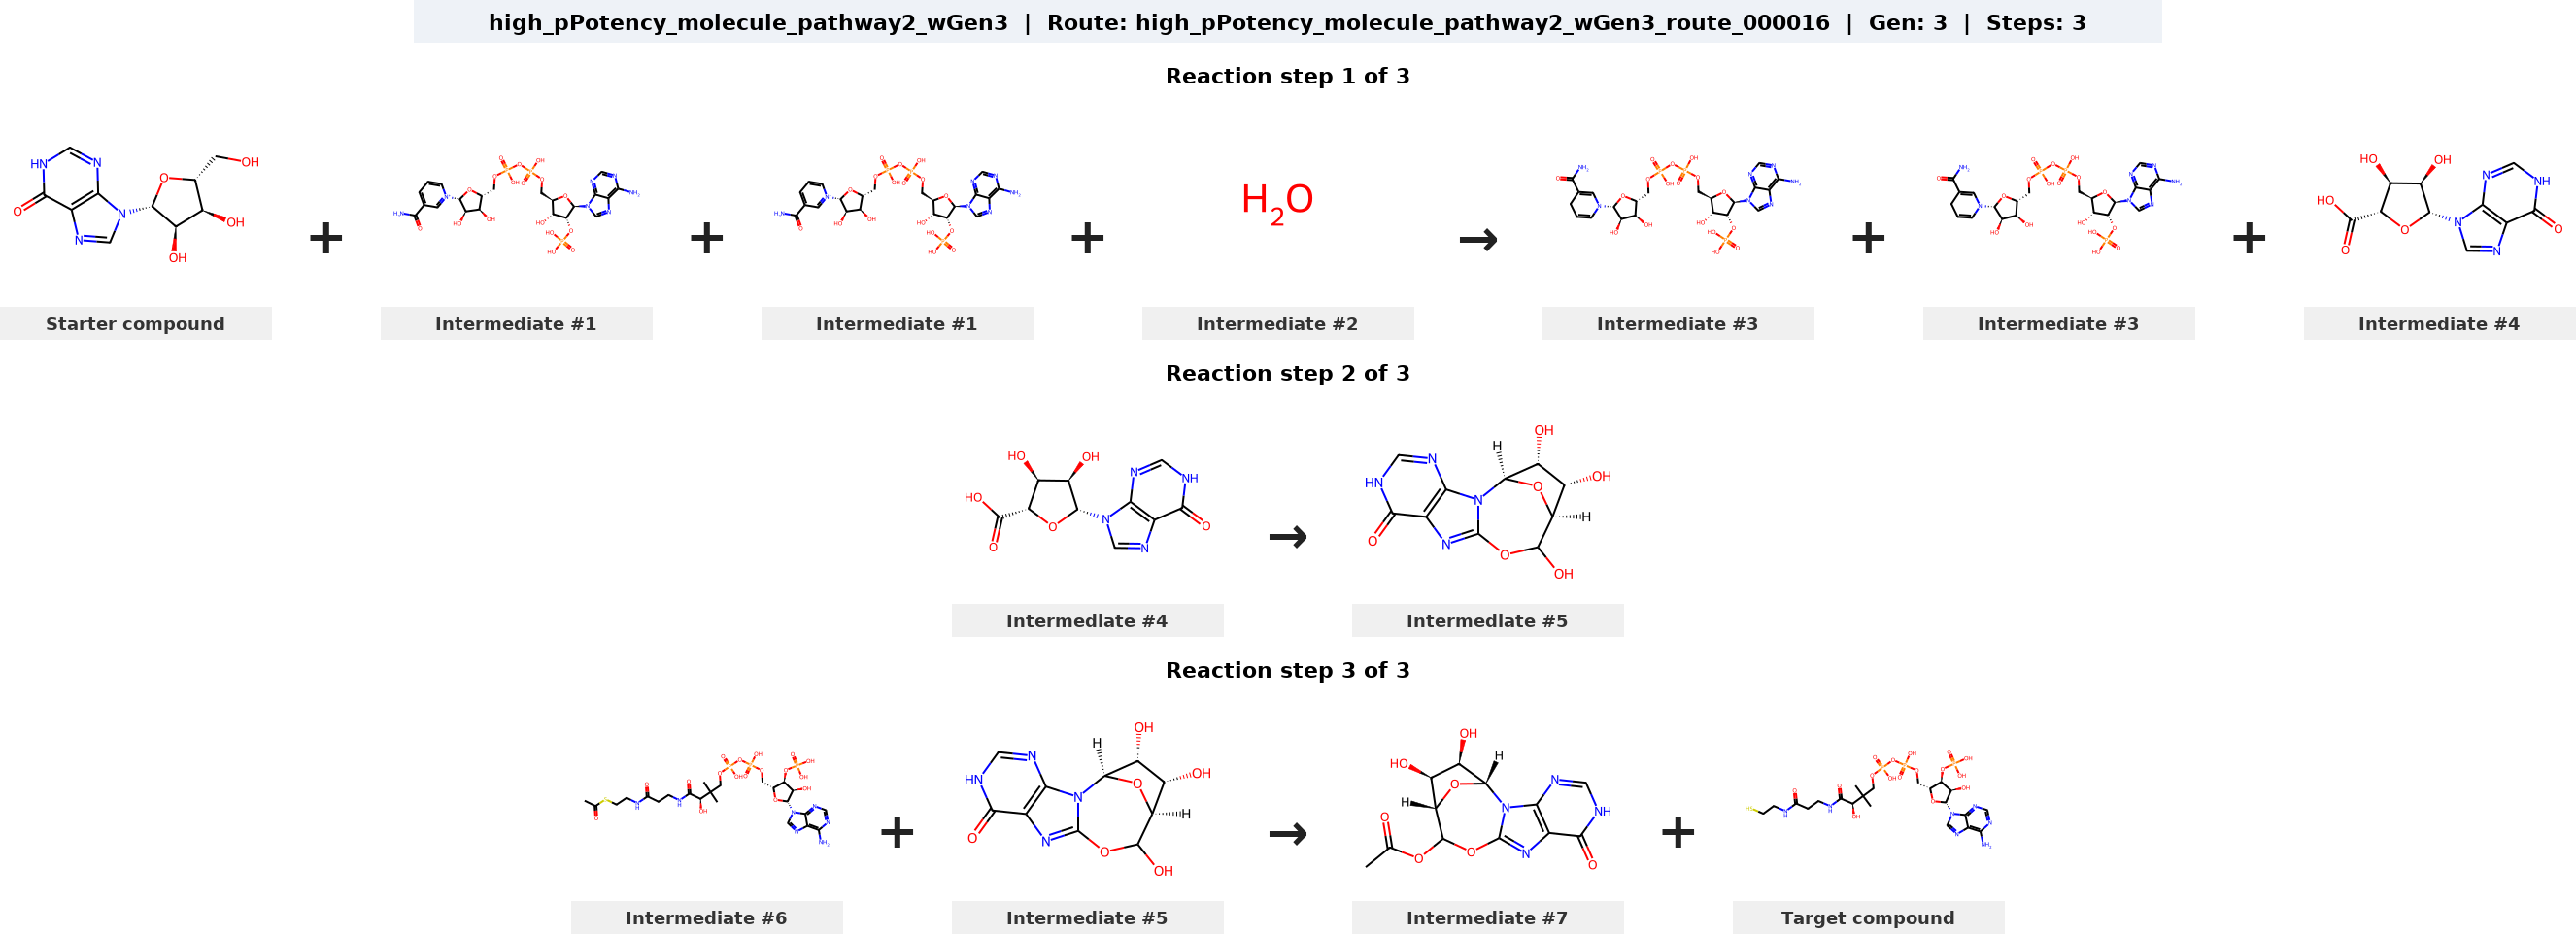

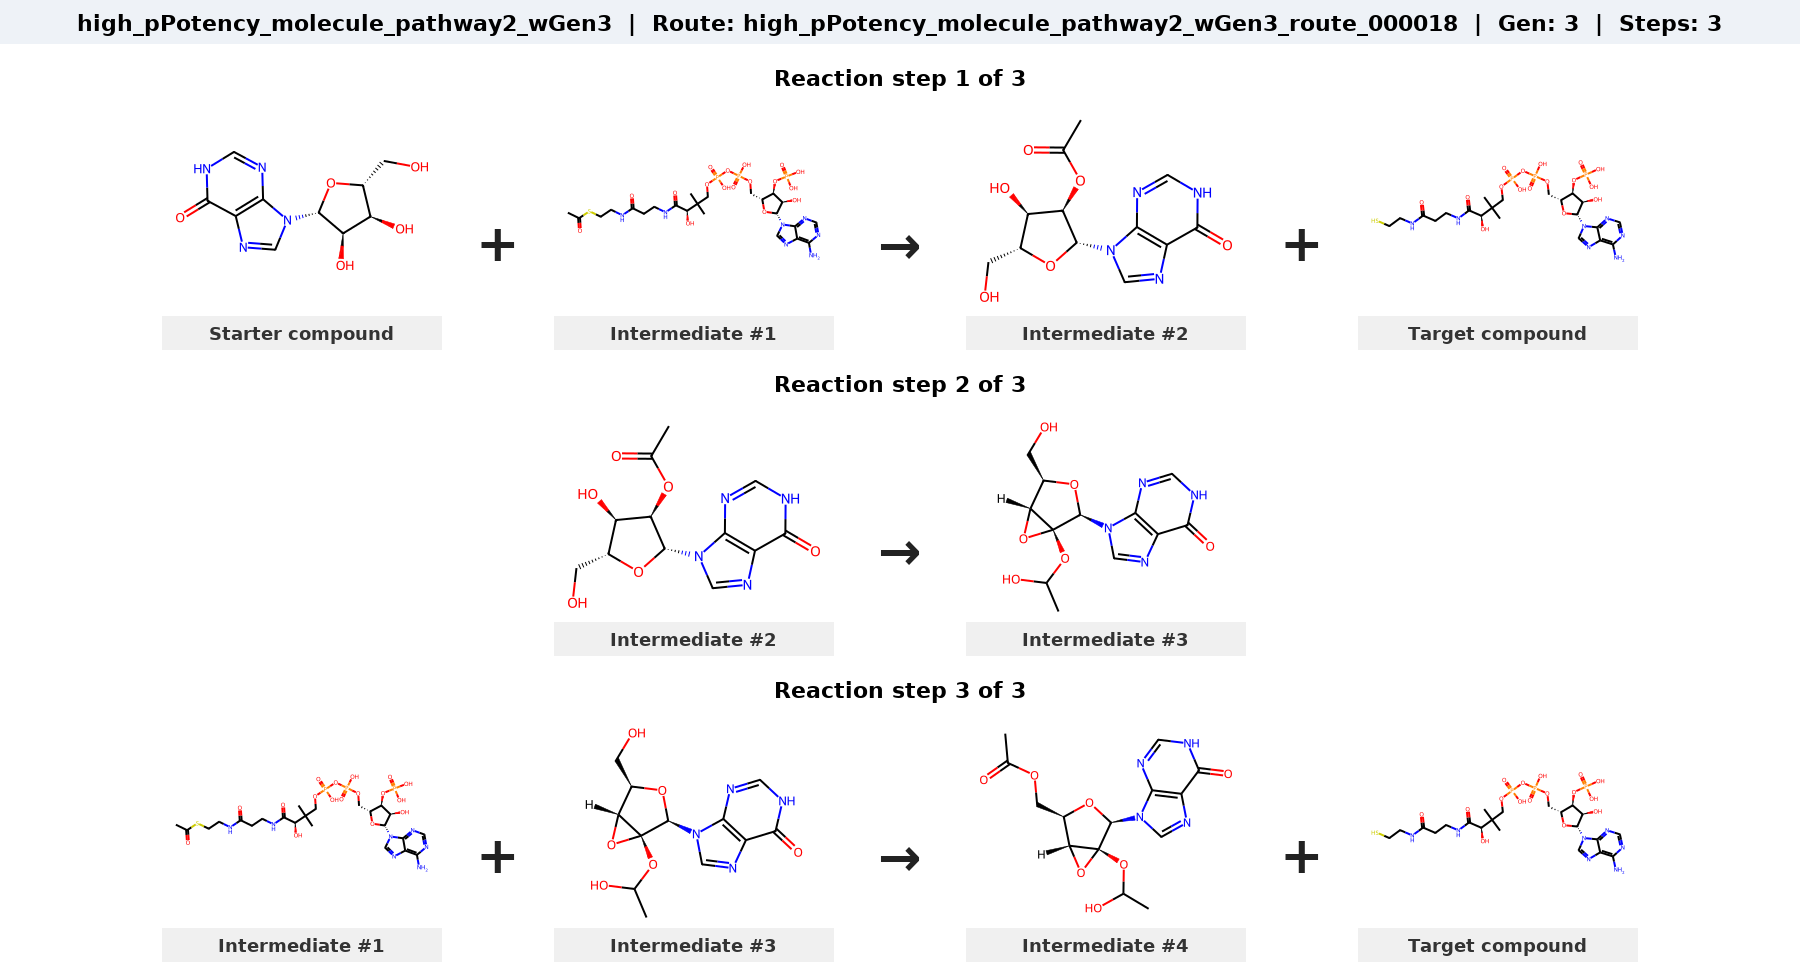

  Saved → /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathways_3step.pdf

Complete.


In [135]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

# CONFIG
maxPerStep    = 10
subImgSize    = (280, 210)
pngSubImgSize = (500, 380)
pngDpi        = (300, 300)

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def splitPathway(pathwayStr):
    return [] if pd.isna(pathwayStr) else [x.strip() for x in str(pathwayStr).split("||") if x.strip()]

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def safeName(rawName):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(rawName))

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")

def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeTextBanner(text, bannerWidth, bannerHeight=40, bgColor="white", font=None):
    img = Image.new("RGB", (bannerWidth, bannerHeight), bgColor)
    centeredText(ImageDraw.Draw(img), text, bannerWidth, (bannerHeight - 24) // 2, font or headerFont)
    return img

def stackPanelsVertically(panelList, gapSize=14, bgColor="white"):
    valid = [p for p in panelList if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid) + gapSize * (len(valid) - 1)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height + gapSize
    return canvas

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def buildIntermediateMap(forwardSteps, canonStarterSet, canonTargetSmi):
    intermediateMap = {}
    counter = 1
    for rxnSmi in forwardSteps:
        if ">>" not in str(rxnSmi):
            continue
        rStr, pStr = str(rxnSmi).split(">>", 1)
        for smi in [s.strip() for s in (rStr + "." + pStr).split(".") if s.strip()]:
            canon = canonSmiles(smi)
            if canon not in canonStarterSet and canon != canonTargetSmi and canon not in intermediateMap:
                intermediateMap[canon] = counter
                counter += 1
    return intermediateMap

def getMolLabel(smi, canonStarterSet, canonTargetSmi, intermediateMap):
    canon = canonSmiles(smi)
    if canon in canonStarterSet:
        return "Starter compound"
    if canon == canonTargetSmi:
        return "Target compound"
    num = intermediateMap.get(canon)
    return f"Intermediate #{num}" if num is not None else "Intermediate"

def makeLabeledMolImage(smi, label, subImageSize=(280, 210)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg      = rdkitImageToPil(Draw.MolToImage(mol, size=subImageSize))
    labelBanner = Image.new("RGB", (molImg.width, 34), "#f0f0f0")
    centeredText(ImageDraw.Draw(labelBanner), label, molImg.width, 7, labelFont, "#333333")
    combined = Image.new("RGB", (molImg.width, molImg.height + labelBanner.height), "white")
    combined.paste(molImg,      (0, 0))
    combined.paste(labelBanner, (0, molImg.height))
    return combined

def makeSeparatorImage(text, height, width=90):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bbox        = draw.textbbox((0, 0), text, font=separatorFont)
        textW, textH = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        textW, textH = 30, 50
    draw.text(((width - textW) // 2, (height - textH) // 2), text, fill="#222222", font=separatorFont)
    return img

def makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                             intermediateMap, panelTitle, subImageSize=(280, 210)):
    if ">>" not in str(rxnSmi):
        return None
    reactantStr, productStr = str(rxnSmi).split(">>", 1)
    reactantSmiles = (
        [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonSmiles(s) in canonStarterSet]
        + [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonSmiles(s) not in canonStarterSet]
    )
    productSmiles = (
        [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonSmiles(s) != canonTargetSmi]
        + [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonSmiles(s) == canonTargetSmi]
    )
    reactantImgs = [img for img in [makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, intermediateMap), subImageSize) for s in reactantSmiles] if img is not None]
    productImgs  = [img for img in [makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, intermediateMap), subImageSize) for s in productSmiles]  if img is not None]
    if not reactantImgs or not productImgs:
        return None
    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 16
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    canvas = Image.new("RGB", (totalW, maxH), "white")
    x = 0
    for part in parts:
        canvas.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap
    titleBanner = makeTextBanner(panelTitle, canvas.width, bannerHeight=38)
    final = Image.new("RGB", (canvas.width, canvas.height + titleBanner.height + 10), "white")
    final.paste(titleBanner, (0, 0))
    final.paste(canvas,      (0, titleBanner.height + 10))
    return final

def buildRouteImage(rowData, numSteps, subImageSize, bannerWidth):
    canonStarterSet = {canonSmiles(s) for s in splitStarters(rowData.get("starterSMILES", ""))}
    canonTargetSmi  = canonSmiles(rowData.get("targetSMILES", ""))
    forwardSteps    = reorderStepsForward(splitPathway(rowData.get("reconstructedPathwayString", np.nan)), canonStarterSet)
    intermediateMap = buildIntermediateMap(forwardSteps, canonStarterSet, canonTargetSmi)
    panelBlocks = [makeTextBanner(
        f"{rowData['dirName']}  |  Route: {rowData['routeId']}  |  Gen: {rowData['generationRun']}  |  Steps: {numSteps}",
        bannerWidth=bannerWidth, bannerHeight=44, bgColor="#eef2f7",
    )]
    for stepIdx, rxnSmi in enumerate(forwardSteps, start=1):
        panel = makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi, intermediateMap,
                                        panelTitle=f"Reaction step {stepIdx} of {numSteps}",
                                        subImageSize=subImageSize)
        if panel:
            panelBlocks.append(panel)
    return stackPanelsVertically(panelBlocks, gapSize=14, bgColor="white")

for numSteps, groupDF in completeRouteLevelDF.groupby("numSteps"):
    subset     = groupDF.head(maxPerStep).reset_index(drop=True)
    stepImages = []
    print(f"\n{numSteps}-step pathways: {len(groupDF):,} available, saving {len(subset):,}")

    for _, rowData in subset.iterrows():
        routeTag   = safeName(str(rowData["routeId"]))
        routeImage = buildRouteImage(rowData, numSteps, subImgSize, bannerWidth=1800)
        if routeImage is None:
            continue
        stepImages.append(routeImage)
        display(routeImage)
        pngImage = buildRouteImage(rowData, numSteps, pngSubImgSize, bannerWidth=3000)
        if pngImage is not None:
            pngImage.save(os.path.join(DNADesignResultsDir, f"pathway_{numSteps}step_{routeTag}.png"), "PNG", dpi=pngDpi)

    if stepImages:
        pdfPath = os.path.join(DNADesignResultsDir, f"pathways_{numSteps}step.pdf")
        stepImages[0].save(pdfPath, "PDF", resolution=150.0, save_all=True, append_images=stepImages[1:])
        print(f"  Saved → {pdfPath}")

print("\nComplete.")